Note: you may need to restart the kernel to use updated packages.

  METRIC                           Baseline      PV only
  PV production (MWh)                    --       1452.2
  Grid import (MWh)                  3282.1       2980.5
  Grid export (MWh)                      --       1150.5
  SC (%)                                 --        20.8%
  SS (%)                                 --         9.2%
----------------------------------------------------------
  Import cost (€)                   506,932      466,620
  Export revenue (€)                     --       40,375
  Net electricity cost (€)          506,932      426,245
  PV savings vs baseline (€)             --       80,687

=== SANITY CHECK ===
  Annual PV yield           : 1452.2 MWh
  Annual load               : 3282.1 MWh
  DA price range            : €-350.0 – 517.6 /MWh
  Import price range        : €-288.4 – 579.1 /MWh  (DA + €39 tax + €26 transport)
  Negative DA steps         : 2268 (6.5%)
  Baseline export revenu

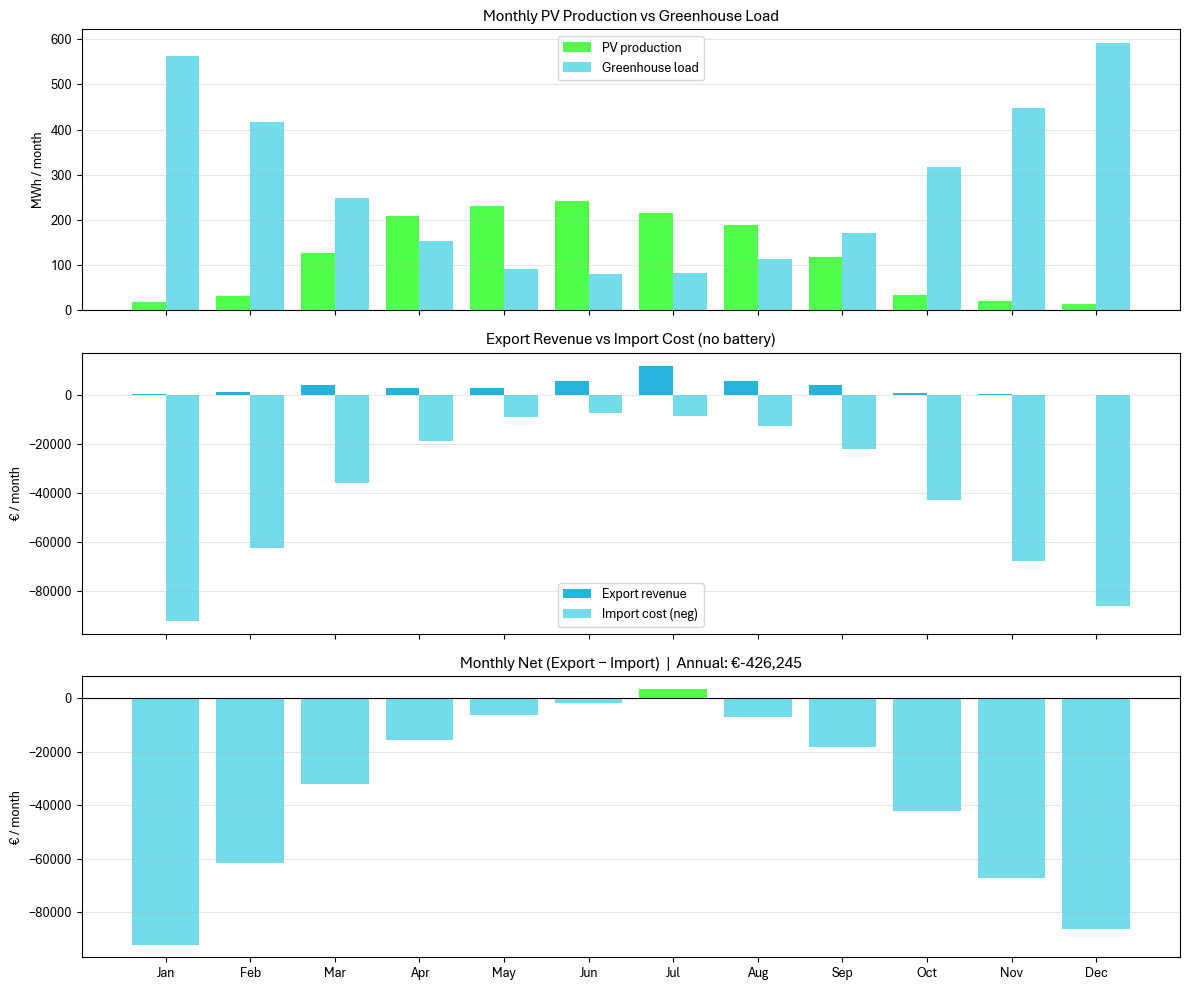

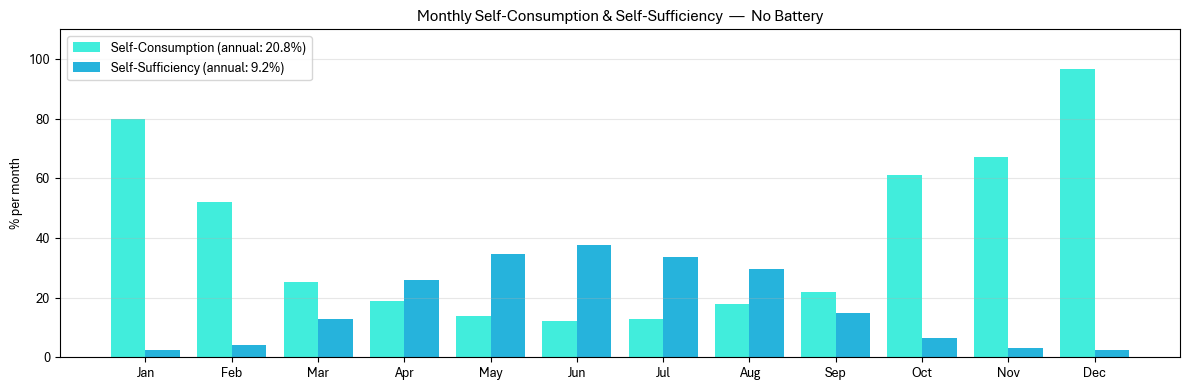

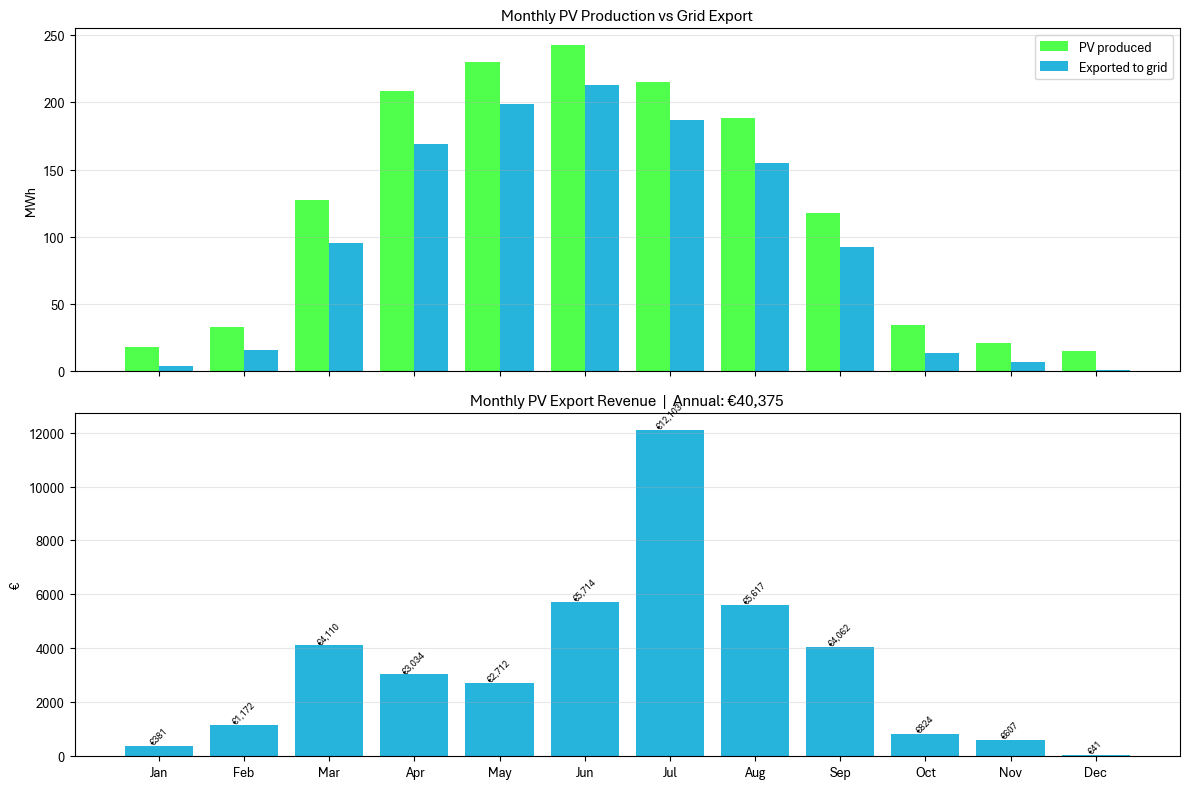

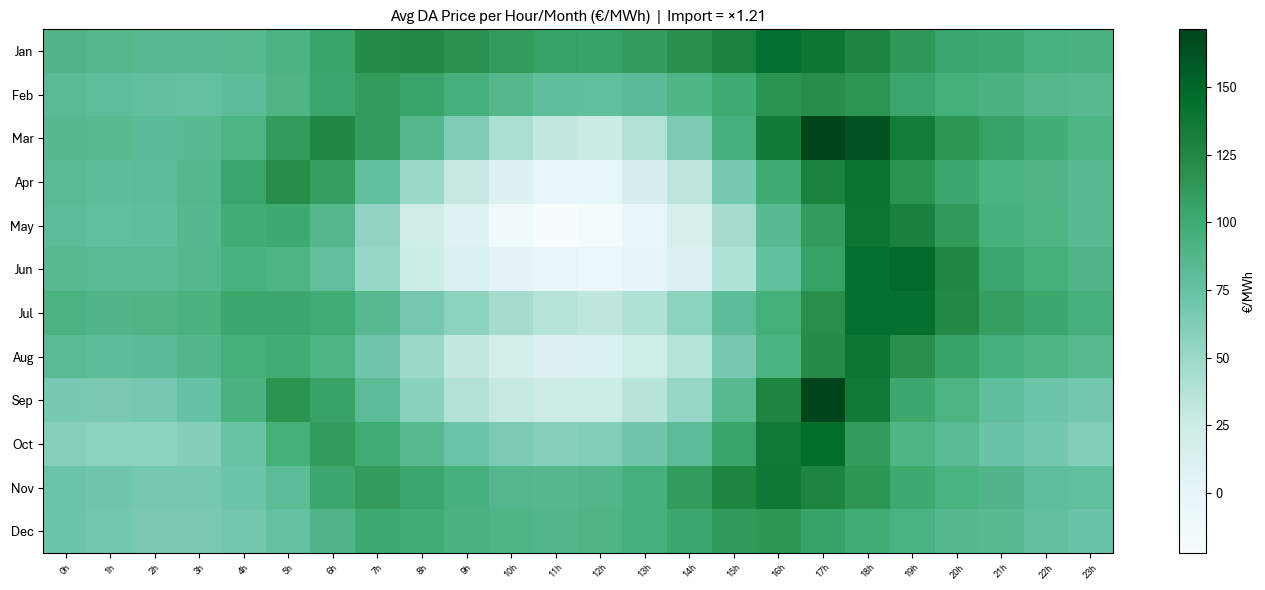

=== INVESTMENT COST BREAKDOWN ===
  Benchmark (3,600 kWh / 3.6 MW):
    Energy component  : €   234,000  (65 €/kWh × 3.6 MWh)
    Power component   : €   302,400  (84 €/kW  × 3600 kW)
    Other costs       : €   468,000  (130 €/kWh × 3.6 MWh)
    Total gross CAPEX : € 1,004,400
    Annual O&M        : €    29,160/yr  (8.1 k€/MW/yr)
  Expansion costs (above benchmark):
    Energy            : 84 €/kWh  (0.08 MEUR/MWh)
    Power             : 108 €/kW   (0.11 MEUR/MW)
  Subsidy: 0%



In [1]:
%pip install -q pandas pypsa numpy matplotlib openpyxl
import pandas as pd
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
plt.rcParams['font.family'] = 'Aptos' if 'Aptos' in _fm.get_font_names() else 'DejaVu Sans'
import warnings
warnings.filterwarnings("ignore")


# ════════════════════════════════════════════════════════════════════
# 1.  INPUTS & CONFIGURATION
#     Adjust all parameters here — nothing below needs to change
# ════════════════════════════════════════════════════════════════════

# =================================================================
#                     C O N F I G U R A T I O N
# =================================================================

# ── SCENARIO SELECTOR ──────────────────────────────────────────────────────
SCENARIO   = "2025_2026"   # "2025_2026"  or  "2023"

_FILES = {
    "2025_2026": "Input_Python-NL-Poel8-Heat-20252026.xlsx",
    "2023":      "Input_Python-NL-Poel8-heat-2023.xlsx",
}
INPUT_FILE   = _FILES[SCENARIO]
OUTPUT_EXCEL = f"nl_elec_only_{{SCENARIO}}.xlsx"
# ───────────────────────────────────────────────────────────────────────────


GREENHOUSE_HA  = 5.2        # ha — modelled greenhouse area (site data)

COL_DA_PRICE        = "Day-ahead price (EUR/kWh)"          # €/kWh
COL_IMBALANCE_VOL   = "Imbalance volume (kWh)"               # kWh per 15-min PTU (TenneT)
COL_PV_PROFILE = "Production voltiron (W)"
COL_LOAD       = "Loadcurve (kW)"          # greenhouse electricity demand
COL_MONTH  = "Month"
COL_DAY    = "Day"
COL_HOUR   = "Hour"
COL_MINUTE = "Minute"

YEAR       = 2025
DT         = 0.25   # 15-min timestep in hours
DT_H       = 1.0    # hourly timestep for investment/heat network
PV_MODULES = int(2500 * GREENHOUSE_HA)   # 2500 modules/ha
MODULE_WP  = 145                          # Wp per module (STC nameplate)
PV_CAPEX_EUR_WP = 1.80                   # €/Wp — installed system cost
PV_LIFETIME_YR  = 25                     # yr   — PV system technical lifetime

# -----------------------------------------------------------------
# Netherlands electricity pricing
#   Export : DA market price (no SDE+/subsidy on export)
#   Import : DA price + €39/MWh energy tax + €26/MWh transport (Westland infra)
# -----------------------------------------------------------------
# -----------------------------------------------------------------
# Import price surcharges (fixed, excl. BTW)
#
#   ENERGY_TAX : Energiebelasting 2026, Staffel 4 (50,001-10,000,000 kWh/yr)
#                = €37.35/MWh = €0.03735/kWh
#                Source: Vattenfall Grootzakelijk 2026
#                https://www.vattenfall.nl/grootzakelijk/energiebelasting/tarieven-2026/
#
#   TRANSPORT  : Westland Infra variable transport tariff 2026
#                Middenspanning (MS) connection, large consumer
#                = €24.20/MWh = €0.02420/kWh
#                Source: Westland Infra Aansluit- en transporttarieven elektriciteit
#                        grootverbruik 2026 (ACM tarievenbesluit)
#                https://westlandinfra.nl/wp-content/uploads/2025/12/westland-infra-aansluit-en-transporttarieven-elektriciteit-grootverbruik-2026.pdf
# -----------------------------------------------------------------
ENERGY_TAX   = 37.35 / 1000   # €/kWh  energiebelasting 2026, staffel 4
TRANSPORT    = 24.20 / 1000   # €/kWh  Westland Infra MS transport 2026


MONTHS = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

# -----------------------------------------------------------------
# BATTERY OPTIMISATION PARAMETERS
# -----------------------------------------------------------------
BATTERY_C_RATE              = 1.0
BATTERY_EFFICIENCY_STORE    = 0.98
BATTERY_EFFICIENCY_DISPATCH = 0.97   # discharge efficiency
BATTERY_LIFE_YR             = 20   # battery lifetime (years)
MAX_CYCLES_PER_YEAR         = 6000 / 20   # 333.33 full cycles/yr over lifetime
# Note: cycle limit IS enforced in the LP via extra_functionality (linear constraint:
#       sum(dis*DT_H) <= MAX_CYCLES_PER_YEAR * e_nom — constant * variable is linear).
BATTERY_SELF_DISCHARGE_HR   = 0.1 / 100 / 24  # 0.1% per day

# -----------------------------------------------------------------
# GRID CONNECTION
# -----------------------------------------------------------------
GRID_IMPORT_MAX_KW = 1372.0    # kW — grid import limit (Transport, Westland Infra 2026)
GRID_EXPORT_MAX_KW = 1940.0    # kW — grid export limit (Teruglever, Westland Infra 2026)
GEO_CONTRACT_KW    = 2800.0    # kW — geothermal electricity contract (Westland Infra 2026)

# -----------------------------------------------------------------
# BATTERY INVESTMENT COSTS  (benchmark: 3,600 kWh / 3.6 MW)
# -----------------------------------------------------------------
BATTERY_BENCHMARK_KWH         = 3_600   # kWh — minimum battery size (benchmark reference)
BATTERY_BENCHMARK_MW          = 3.6     # MW  — benchmark power capacity (C-rate = 1)

BATTERY_CAPEX_ENERGY_MEUR_MWH = 0.065  # MEUR/MWh — energy component (benchmark)
BATTERY_CAPEX_POWER_MEUR_MW   = 0.084  # MEUR/MW  — power component  (benchmark)
BATTERY_CAPEX_OTHER_MEUR_MWH  = 0.13   # MEUR/MWh — other project costs (benchmark)

BATTERY_SUBSIDY_FRAC = 0.0   # subsidy fraction (0 = none; 0.5 = 50% grant)

BATTERY_OM_KEUR_MW_YR  = 8.1  # kEUR/MW/year  — fixed O&M (on total installed power capacity)

# Expansion costs (marginal, for capacity added above benchmark)
EXPANSION_ENERGY_MEUR_MWH = 0.084  # MEUR/MWh — marginal energy storage cost
EXPANSION_POWER_MEUR_MW   = 0.108  # MEUR/MW  — marginal power (charge/discharge) cost

# -----------------------------------------------------------------
# PLANNED OUTAGE
# -----------------------------------------------------------------
OUTAGE_WEEKS = 0.2   # weeks/year of planned maintenance (first weeks of January)


# ════════════════════════════════════════════════════════════════════
# 2.  DATA LOADING & PREPROCESSING
# ════════════════════════════════════════════════════════════════════

df = pd.read_excel(INPUT_FILE)
df["timestamp"] = pd.to_datetime(
    dict(year=YEAR, month=df[COL_MONTH], day=df[COL_DAY],
         hour=df[COL_HOUR], minute=df[COL_MINUTE])
)
df = df.set_index("timestamp")
# Replace index with a clean synthetic 15-min sequence to avoid DST duplicate timestamps
df.index = pd.date_range("2025-01-01 00:00", periods=len(df), freq="15min")

pv_kw        = (df[COL_PV_PROFILE] / 1000) * PV_MODULES   # kW
load_kw      = df[COL_LOAD] / DT                            # kWh per 15-min interval → kW
da_price         = df[COL_DA_PRICE].fillna(0)                    # €/kWh  (NaN → 0 if missing)
import_price     = da_price + ENERGY_TAX + TRANSPORT             # €/kWh  (DA + tax + transport)

pv_kwh   = pv_kw   * DT
load_kwh = load_kw * DT

# Baseline (no battery)
pv_surplus_kw   = (pv_kw   - load_kw).clip(lower=0)
load_deficit_kw = (load_kw - pv_kw  ).clip(lower=0)
export_rev_ts   = pv_surplus_kw   * DT * da_price
import_cost_ts  = load_deficit_kw * DT * import_price
net_revenue_ts  = export_rev_ts - import_cost_ts

# Direct PV consumed on-site (no battery)
direct_pv_kwh = pv_kwh - pv_surplus_kw * DT   # kWh self-consumed directly

eta2 = BATTERY_EFFICIENCY_STORE * BATTERY_EFFICIENCY_DISPATCH

# Baseline SC / SS
sc_base = direct_pv_kwh.sum() / pv_kwh.sum()   * 100   # % of PV used on-site
ss_base = direct_pv_kwh.sum() / load_kwh.sum() * 100   # % of load covered by PV

# Monthly aggregates (reused throughout)
pv_monthly_kwh   = pv_kwh.groupby(pv_kwh.index.month).sum()
load_monthly_kwh = load_kwh.groupby(load_kwh.index.month).sum()


# ════════════════════════════════════════════════════════════════════
# 3.  CAPEX HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════════

def gross_capex(energy_kwh, power_kw):
    """Benchmark floor (3600 kWh / 3600 kW) + expansion CAPEX.
    Floor cost (energy + other + power) is fixed regardless of size.
    Expansion above floor: expansion_energy/kWh + expansion_power/kW.
    Other project costs (130 EUR/kWh) apply to benchmark floor only.
    """
    _bm_e = BATTERY_BENCHMARK_KWH
    _bm_p = BATTERY_BENCHMARK_MW * 1e3
    bm    = ((BATTERY_CAPEX_ENERGY_MEUR_MWH + BATTERY_CAPEX_OTHER_MEUR_MWH) * _bm_e / 1e3
             + BATTERY_CAPEX_POWER_MEUR_MW * _bm_p / 1e3) * 1e6
    exp_e = EXPANSION_ENERGY_MEUR_MWH * max(0.0, energy_kwh - _bm_e) / 1e3 * 1e6
    exp_p = EXPANSION_POWER_MEUR_MW   * max(0.0, power_kw  - _bm_p) / 1e3 * 1e6
    return bm + exp_e + exp_p

def net_capex(energy_kwh, power_kw):
    return gross_capex(energy_kwh, power_kw) * (1 - BATTERY_SUBSIDY_FRAC)

def annual_om(power_kw):
    """Annual fixed O&M cost (€), proportional to total installed power capacity."""
    return BATTERY_OM_KEUR_MW_YR * (power_kw / 1e3) * 1e3   # €/yr

def compute_payback(energy_kwh, power_kw, annual_extra_after_om):
    if annual_extra_after_om <= 0:
        return float("inf")
    return net_capex(energy_kwh, power_kw) / annual_extra_after_om


# ════════════════════════════════════════════════════════════════════
# 4.  BATTERY MODEL FUNCTIONS
# ════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════
baseline_annual_net  = net_revenue_ts.sum()
baseline_monthly_net = net_revenue_ts.groupby(net_revenue_ts.index.month).sum()
baseline_monthly_net.index = MONTHS


# ════════════════════════════════════════════════════════════════════
# 5.  INVESTMENT OPTIMISATION — SOLVE & RESULTS
# ════════════════════════════════════════════════════════════════════


# ════════════════════════════════════════════════════════════════════
# OUTPUT 1:  Baseline diagnostics (sanity check, DA spread, monthly baseline,
#            early charts — plots 1 / 1b / 1c / 2)
# ════════════════════════════════════════════════════════════════════

_no_pv_import_cost = (load_kw * import_price * DT).sum()
_pv_import_cost    = import_cost_ts.sum()
_pv_export_rev     = export_rev_ts.sum()
_pv_net_cost       = _pv_import_cost - _pv_export_rev
_pv_saving         = _no_pv_import_cost - _pv_net_cost
_pv_import_mwh     = (load_deficit_kw * DT).sum() / 1000
_pv_export_mwh     = (pv_surplus_kw   * DT).sum() / 1000

W = 58
print()
print("="*W)
print(f"  {'METRIC':<30} {'Baseline':>10} {'PV only':>12}")
print("="*W)
print(f"  {'PV production (MWh)':<30} {'--':>10} {pv_kwh.sum()/1000:>12.1f}")
print(f"  {'Grid import (MWh)':<30} {load_kwh.sum()/1000:>10.1f} {_pv_import_mwh:>12.1f}")
print(f"  {'Grid export (MWh)':<30} {'--':>10} {_pv_export_mwh:>12.1f}")
print(f"  {'SC (%)':<30} {'--':>10} {sc_base:>11.1f}%")
print(f"  {'SS (%)':<30} {'--':>10} {ss_base:>11.1f}%")
print("-"*W)
print(f"  {'Import cost (€)':<30} {_no_pv_import_cost:>10,.0f} {_pv_import_cost:>12,.0f}")
print(f"  {'Export revenue (€)':<30} {'--':>10} {_pv_export_rev:>12,.0f}")
print(f"  {'Net electricity cost (€)':<30} {_no_pv_import_cost:>10,.0f} {_pv_net_cost:>12,.0f}")
print(f"  {'PV savings vs baseline (€)':<30} {'--':>10} {_pv_saving:>12,.0f}")
print("="*W)
print()

print("=== SANITY CHECK ===")
print(f"  Annual PV yield           : {pv_kwh.sum() / 1000:.1f} MWh")
print(f"  Annual load               : {load_kwh.sum() / 1000:.1f} MWh")
print(f"  DA price range            : €{da_price.min()*1000:.1f} – {da_price.max()*1000:.1f} /MWh")
print(f"  Import price range        : €{import_price.min()*1000:.1f} – {import_price.max()*1000:.1f} /MWh  (DA + €39 tax + €26 transport)")
print(f"  Negative DA steps         : {(da_price < 0).sum()} ({(da_price < 0).mean()*100:.1f}%)")
print(f"  Baseline export revenue   : €{export_rev_ts.sum():,.0f}/yr")
print(f"  Baseline import cost      : €{import_cost_ts.sum():,.0f}/yr")
print(f"  Baseline net              : €{net_revenue_ts.sum():,.0f}/yr")
print()
print(f"  --- No-battery SC / SS ---")
print(f"  Self-Consumption (no bat) : {sc_base:.1f}%  (PV used on-site / total PV)")
print(f"  Self-Sufficiency (no bat) : {ss_base:.1f}%  (load covered by PV / total load)")
print()

print("=== DA SPREAD DIAGNOSTIC ===")

daily_max    = da_price.resample("D").max() * 1000
daily_min    = da_price.resample("D").min() * 1000
daily_spread = daily_max - daily_min

print(f"  Round-trip efficiency (η²)   : {eta2*100:.1f}%")
print(f"  Import surcharge              : €{(ENERGY_TAX+TRANSPORT)*1000:.0f}/MWh fixed  (€39 tax + €26 transport)")
print()
print(f"  Daily DA spread stats (€/MWh):")
print(f"    Mean   : €{daily_spread.mean():.1f}")
print(f"    Median : €{daily_spread.median():.1f}")
print(f"    P75    : €{daily_spread.quantile(0.75):.1f}")
print(f"    P90    : €{daily_spread.quantile(0.90):.1f}")
print(f"    Max    : €{daily_spread.max():.1f}")
print(f"    Days spread > €50/MWh : {(daily_spread > 50).sum()} days")
print(f"    Days spread > €30/MWh : {(daily_spread > 30).sum()} days")
print()

hourly_avg          = (da_price * 1000).groupby(da_price.index.hour).mean()
best_charge_hour    = int(hourly_avg.idxmin())
best_discharge_hour = int(hourly_avg.idxmax())
spread_best_hours   = hourly_avg.max() - hourly_avg.min()
effective_import_spread = hourly_avg.max() * 1.21 - hourly_avg.min()

print(f"  Best avg charge hour     : {best_charge_hour:02d}:00  (avg €{hourly_avg.min():.1f}/MWh)")
print(f"  Best avg discharge hour  : {best_discharge_hour:02d}:00  (avg €{hourly_avg.max():.1f}/MWh)")
print(f"  DA spread (best hours)   : €{spread_best_hours:.1f}/MWh")
print(f"  After η² loss            : €{spread_best_hours * eta2:.1f}/MWh net (export→export)")
print(f"  Import-offset spread     : €{effective_import_spread:.1f}/MWh")
print(f"  After η² (import offset) : €{effective_import_spread * eta2:.1f}/MWh net")
print()

direct_pv_monthly = direct_pv_kwh.groupby(direct_pv_kwh.index.month).sum()
monthly_sc_base   = direct_pv_monthly / pv_monthly_kwh   * 100
monthly_ss_base   = direct_pv_monthly / load_monthly_kwh * 100

export_kwh_base  = pv_surplus_kw * DT
exp_monthly_base = export_kwh_base.groupby(export_kwh_base.index.month).sum() / 1000   # MWh

monthly = pd.DataFrame({
    "PV production (MWh)":   pv_monthly_kwh / 1000,
    "Load (MWh)":            load_monthly_kwh / 1000,
    "Exported (MWh)":        exp_monthly_base,
    "Export revenue (€)":    export_rev_ts.groupby(export_rev_ts.index.month).sum(),
    "Import cost (€)":       import_cost_ts.groupby(import_cost_ts.index.month).sum(),
    "Net (€)":               net_revenue_ts.groupby(net_revenue_ts.index.month).sum(),
    "SC base (%)": monthly_sc_base.values,
    "SS base (%)": monthly_ss_base.values,
    "Avg DA price (€/MWh)": (da_price * 1000).groupby(da_price.index.month).mean(),
})
monthly.index = MONTHS
monthly_sc_base.index = MONTHS
monthly_ss_base.index = MONTHS

print("=== MONTHLY BASELINE (no battery) ===")
print(f"{'Month':<6} {'PV (MWh)':>9} {'Load (MWh)':>10} {'Export €':>10} "
      f"{'Import €':>10} {'Net €':>10} {'SC %':>7} {'SS %':>7}")
print("-" * 73)
for m in MONTHS:
    print(f"{m:<6} {monthly.loc[m,'PV production (MWh)']:>9.1f}"
          f" {monthly.loc[m,'Load (MWh)']:>10.1f}"
          f" {monthly.loc[m,'Export revenue (€)']:>10,.0f}"
          f" {monthly.loc[m,'Import cost (€)']:>10,.0f}"
          f" {monthly.loc[m,'Net (€)']:>10,.0f}"
          f" {monthly.loc[m,'SC base (%)']:>6.1f}%"
          f" {monthly.loc[m,'SS base (%)']:>6.1f}%")
print("-" * 73)
print(f"{'TOTAL':<6} {monthly['PV production (MWh)'].sum():>9.1f}"
      f" {monthly['Load (MWh)'].sum():>10.1f}"
      f" {monthly['Export revenue (€)'].sum():>10,.0f}"
      f" {monthly['Import cost (€)'].sum():>10,.0f}"
      f" {monthly['Net (€)'].sum():>10,.0f}"
      f" {sc_base:>6.1f}%"
      f" {ss_base:>6.1f}%")
print()

print("=== MONTHLY PV REVENUE ANALYSIS (no battery) ===")
print(f"{'Month':<6} {'PV (MWh)':>9} {'Exported (MWh)':>15} {'Avg export €/MWh':>18} "
      f"{'Export rev €':>13} {'€/MWh PV':>10}")
print("-" * 76)
for m in MONTHS:
    pv_mwh   = monthly.loc[m, "PV production (MWh)"]
    exp_mwh  = monthly.loc[m, "Exported (MWh)"]
    exp_rev  = monthly.loc[m, "Export revenue (€)"]
    avg_exp  = exp_rev / exp_mwh if exp_mwh > 0 else 0
    rev_pv   = exp_rev / pv_mwh  if pv_mwh  > 0 else 0
    print(f"{m:<6} {pv_mwh:>9.1f} {exp_mwh:>15.1f} {avg_exp:>18.2f} "
          f"{exp_rev:>13,.0f} {rev_pv:>10.2f}")
print("-" * 76)
tot_pv  = monthly["PV production (MWh)"].sum()
tot_exp = monthly["Exported (MWh)"].sum()
tot_rev = monthly["Export revenue (€)"].sum()
print(f"{'TOTAL':<6} {tot_pv:>9.1f} {tot_exp:>15.1f} "
      f"{tot_rev/tot_exp if tot_exp>0 else 0:>18.2f} "
      f"{tot_rev:>13,.0f} {tot_rev/tot_pv if tot_pv>0 else 0:>10.2f}")
print()


# Plot 1 — Monthly PV, load, and net revenue
fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
x = np.arange(12)

axes1[0].bar(x - 0.2, monthly["PV production (MWh)"].values, 0.4,
             color="#30FF2C", alpha=0.85, label="PV production")
axes1[0].bar(x + 0.2, monthly["Load (MWh)"].values, 0.4,
             color="#5AD6E7", alpha=0.85, label="Greenhouse load")
axes1[0].set_ylabel("MWh / month")
axes1[0].set_title("Monthly PV Production vs Greenhouse Load")
axes1[0].legend()
axes1[0].grid(True, alpha=0.3, axis="y")

axes1[1].bar(x - 0.2, monthly["Export revenue (€)"].values, 0.4,
             color="#00A6D6", alpha=0.85, label="Export revenue")
axes1[1].bar(x + 0.2, -monthly["Import cost (€)"].values, 0.4,
             color="#5AD6E7", alpha=0.85, label="Import cost (neg)")
axes1[1].set_ylabel("€ / month")
axes1[1].set_title("Export Revenue vs Import Cost (no battery)")
axes1[1].legend()
axes1[1].grid(True, alpha=0.3, axis="y")

colors1 = ["#30FF2C" if v >= 0 else "#5AD6E7" for v in monthly["Net (€)"].values]
axes1[2].bar(x, monthly["Net (€)"].values, color=colors1, alpha=0.85)
axes1[2].axhline(0, color="black", lw=0.8)
axes1[2].set_xticks(x); axes1[2].set_xticklabels(MONTHS)
axes1[2].set_ylabel("€ / month")
axes1[2].set_title(f"Monthly Net (Export − Import)  |  Annual: €{monthly['Net (€)'].sum():,.0f}")
axes1[2].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_monthly_baseline.png", dpi=150)
plt.show()

# Plot 1b — Monthly SC and SS (baseline)
fig1b, ax1b = plt.subplots(figsize=(12, 4))
ax1b.bar(x - 0.2, monthly["SC base (%)"].values, 0.4,
         color="#1FEAD6", alpha=0.85, label=f"Self-Consumption (annual: {sc_base:.1f}%)")
ax1b.bar(x + 0.2, monthly["SS base (%)"].values, 0.4,
         color="#00A6D6", alpha=0.85, label=f"Self-Sufficiency (annual: {ss_base:.1f}%)")
ax1b.set_xticks(x); ax1b.set_xticklabels(MONTHS)
ax1b.set_ylabel("% per month")
ax1b.set_title("Monthly Self-Consumption & Self-Sufficiency  —  No Battery")
ax1b.legend()
ax1b.grid(True, alpha=0.3, axis="y")
ax1b.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("nl_sc_ss_baseline.png", dpi=150)
plt.show()

# Plot 1c — Monthly PV revenue breakdown
fig1c, axes1c = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes1c[0].bar(x - 0.2, monthly["PV production (MWh)"].values, 0.4,
              color="#30FF2C", alpha=0.85, label="PV produced")
axes1c[0].bar(x + 0.2, monthly["Exported (MWh)"].values, 0.4,
              color="#00A6D6", alpha=0.85, label="Exported to grid")
axes1c[0].set_ylabel("MWh")
axes1c[0].set_title("Monthly PV Production vs Grid Export")
axes1c[0].legend()
axes1c[0].grid(True, alpha=0.3, axis="y")

axes1c[1].bar(x, monthly["Export revenue (€)"].values, color="#00A6D6", alpha=0.85)
for i, v in enumerate(monthly["Export revenue (€)"].values):
    axes1c[1].text(i, v + 50, f"€{v:,.0f}", ha="center", fontsize=7, rotation=45)
axes1c[1].set_xticks(x); axes1c[1].set_xticklabels(MONTHS)
axes1c[1].set_ylabel("€")
axes1c[1].set_title(f"Monthly PV Export Revenue  |  Annual: €{monthly['Export revenue (€)'].sum():,.0f}")
axes1c[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_pv_revenue_monthly.png", dpi=150)
plt.show()

# Plot 2 — Avg DA price per hour/month heatmap
da_hourly_df = pd.DataFrame({
    "month": da_price.index.month,
    "hour":  da_price.index.hour,
    "price": da_price.values * 1000,
})
pivot_da = da_hourly_df.groupby(["month","hour"])["price"].mean().unstack(level=1)
pivot_da.index = MONTHS

fig2, ax2 = plt.subplots(figsize=(14, 6))
im2 = ax2.imshow(pivot_da.reindex(columns=range(24)).fillna(0).values,
                 aspect="auto", cmap="BuGn")
ax2.set_xticks(range(24))
ax2.set_xticklabels([f"{h}h" for h in range(24)], rotation=45, fontsize=7)
ax2.set_yticks(range(12)); ax2.set_yticklabels(MONTHS)
ax2.set_title("Avg DA Price per Hour/Month (€/MWh)  |  Import = ×1.21")
plt.colorbar(im2, ax=ax2, label="€/MWh")
plt.tight_layout()
plt.savefig("nl_da_price_heatmap.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════════════
# OUTPUT 2:  Capex schedule
# ════════════════════════════════════════════════════════════════════

print("=== INVESTMENT COST BREAKDOWN ===")
bm_e   = BATTERY_CAPEX_ENERGY_MEUR_MWH * (BATTERY_BENCHMARK_KWH/1e3) * 1e6
bm_p   = BATTERY_CAPEX_POWER_MEUR_MW   *  BATTERY_BENCHMARK_MW       * 1e6
bm_o   = BATTERY_CAPEX_OTHER_MEUR_MWH  * (BATTERY_BENCHMARK_KWH/1e3) * 1e6
bm_tot = bm_e + bm_p + bm_o
print(f"  Benchmark ({BATTERY_BENCHMARK_KWH:,.0f} kWh / {BATTERY_BENCHMARK_MW:.1f} MW):")
print(f"    Energy component  : €{bm_e:>10,.0f}  ({BATTERY_CAPEX_ENERGY_MEUR_MWH*1e3:.0f} €/kWh × {BATTERY_BENCHMARK_KWH/1e3:.1f} MWh)")
print(f"    Power component   : €{bm_p:>10,.0f}  ({BATTERY_CAPEX_POWER_MEUR_MW*1e6/1e3:.0f} €/kW  × {BATTERY_BENCHMARK_MW*1e3:.0f} kW)")
print(f"    Other costs       : €{bm_o:>10,.0f}  ({BATTERY_CAPEX_OTHER_MEUR_MWH*1e3:.0f} €/kWh × {BATTERY_BENCHMARK_KWH/1e3:.1f} MWh)")
print(f"    Total gross CAPEX : €{bm_tot:>10,.0f}")
print(f"    Annual O&M        : €{annual_om(BATTERY_BENCHMARK_MW * 1e3):>10,.0f}/yr  ({BATTERY_OM_KEUR_MW_YR:.1f} k€/MW/yr)")
print(f"  Expansion costs (above benchmark):")
print(f"    Energy            : {EXPANSION_ENERGY_MEUR_MWH*1e3:.0f} €/kWh  ({EXPANSION_ENERGY_MEUR_MWH:.2f} MEUR/MWh)")
print(f"    Power             : {EXPANSION_POWER_MEUR_MW*1e3:.0f} €/kW   ({EXPANSION_POWER_MEUR_MW:.2f} MEUR/MW)")
print(f"  Subsidy: {BATTERY_SUBSIDY_FRAC*100:.0f}%")
print()



In [2]:
# ════════════════════════════════════════════════════════════════════════════
# PV curtailment — NO battery
#
# Without a battery, PV surplus can only be exported up to GRID_EXPORT_MAX_KW.
# Anything beyond that export cap is curtailed.
# All variables come from Cell 0 (config + data loading).
# ════════════════════════════════════════════════════════════════════════════

_pv_avail_mwh_no_bat  = float(pv_kwh.sum()) / 1000   # MWh/yr available

# Surplus clipped to export cap — remainder is curtailed
_export_no_bat_kw     = pv_surplus_kw.clip(upper=GRID_EXPORT_MAX_KW)
_curt_no_bat_kw       = pv_surplus_kw - _export_no_bat_kw
_curt_no_bat_mwh      = float((_curt_no_bat_kw * DT).sum()) / 1000   # MWh/yr
_curt_no_bat_pct      = _curt_no_bat_mwh / _pv_avail_mwh_no_bat * 100

print(f"PV curtailment WITHOUT battery")
print(f"  Curtailed energy : {_curt_no_bat_mwh:,.1f} MWh/yr")
print(f"  Curtailment rate : {_curt_no_bat_pct:.1f}%  of total PV available")
print(f"  (Export cap applied: {GRID_EXPORT_MAX_KW:.0f} kW)")


PV curtailment WITHOUT battery
  Curtailed energy : 0.0 MWh/yr
  Curtailment rate : 0.0%  of total PV available
  (Export cap applied: 1940 kW)


Solving electricity-only network (battery + PV + grid) ...


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.


  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 271.88it/s]
INFO:linopy.io: Writing time: 0.33s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61323 primals, 131404 duals
Objective: 2.91e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, max_annual_cycles were not assigned to the network.


  → OK

╔══ OPTIMISED CAPACITIES (hourly investment LP) ═════════════════════╗
║  Battery                                                         ║
║    Energy  :   13,253 kWh                                   ║
║    Power   :    3,600 kW                                    ║
║    C-rate  :    0.272  1/h                              ║
╠═══════════════════════════════════════════════════════════════════╣
║  PV  (fixed capacity)                                            ║
║    Capacity:    1,178 kW_p  (13,000 x 145 Wp)              ║
║    Annual  :    1,450 MWh_e/yr  (sizing run, hourly)       ║
║    Curtailed:     2.3 MWh_e/yr (0.2%)               ║
╠═══════════════════════════════════════════════════════════════════╣
║  ANNUALISED CAPEX  (see Cell 5 for full economics)               ║
║  PV system (25 yr)  : €   135,720/yr  (total €3,393,000)    ║
╚═══════════════════════════════════════════════════════════════════╝

---------------------------------------------------------------------

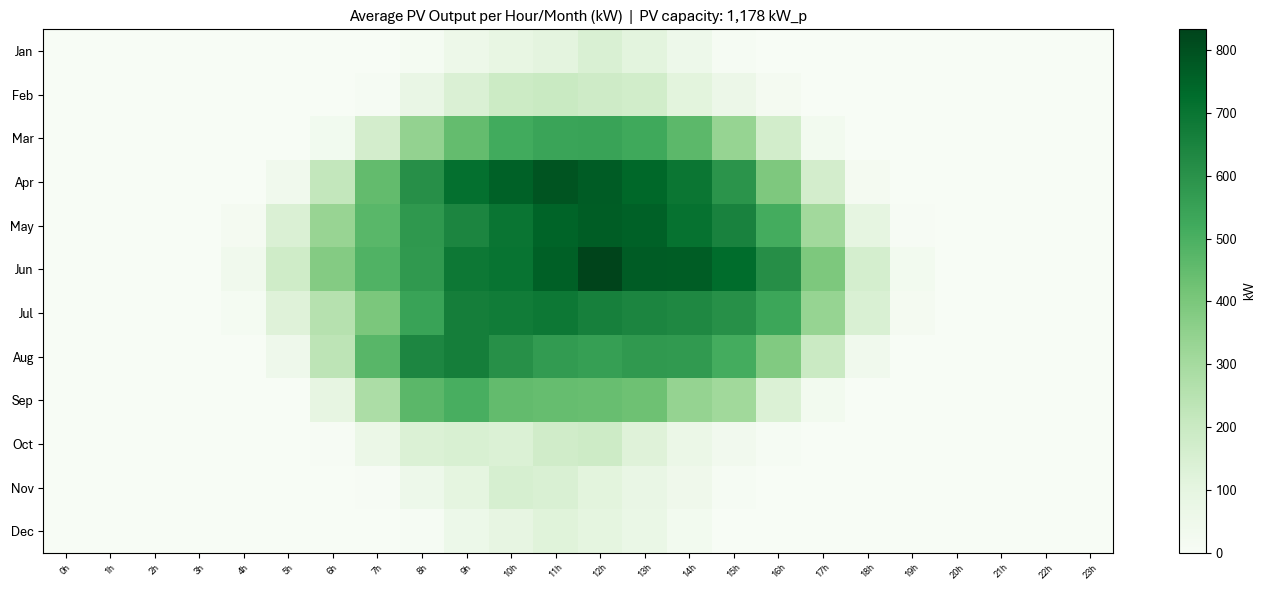

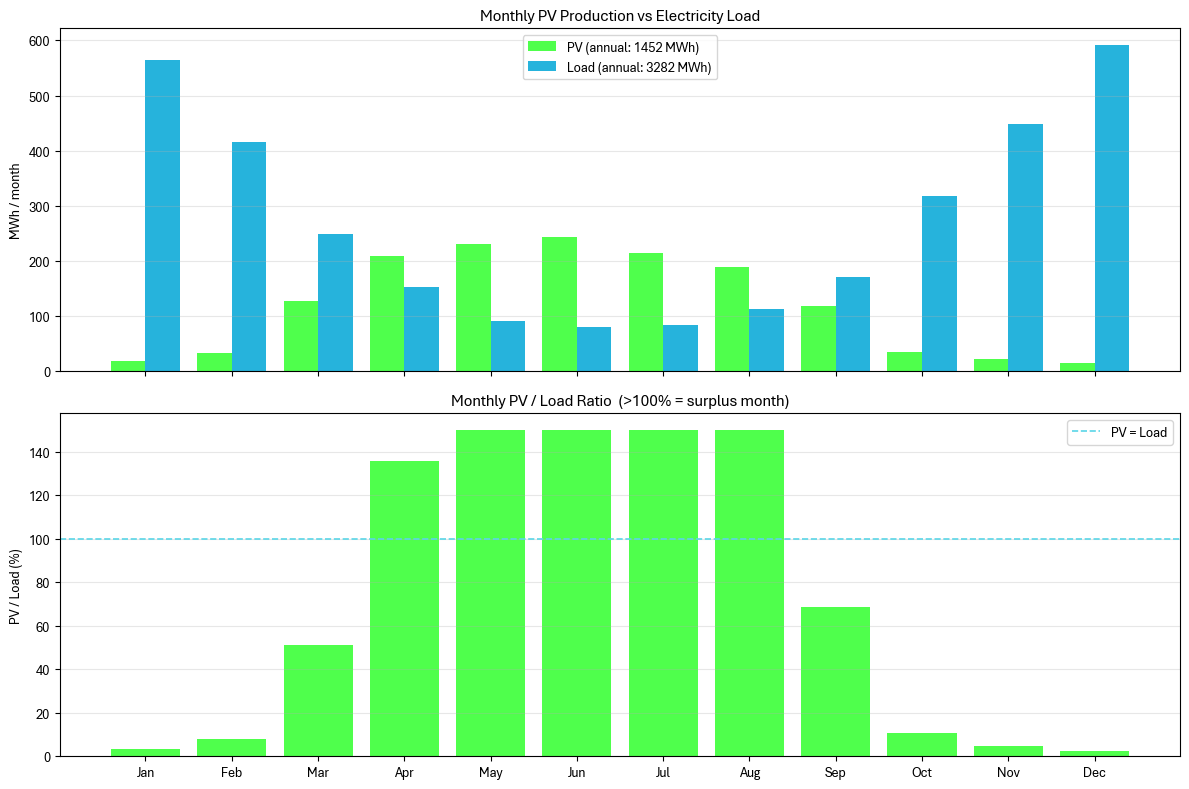

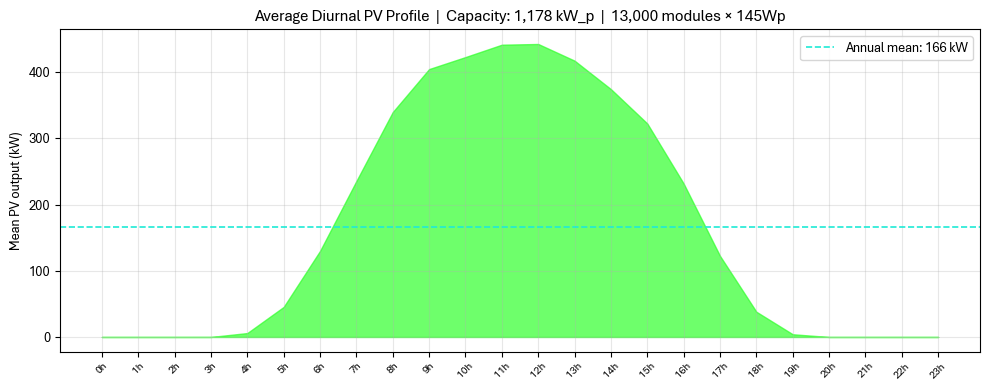

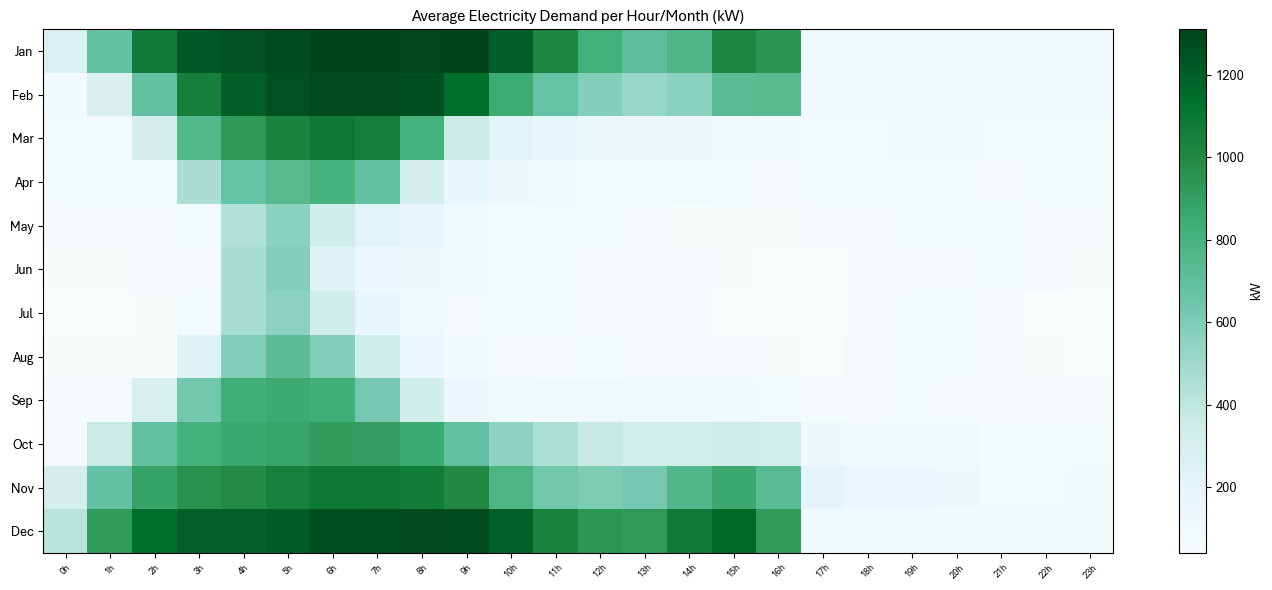

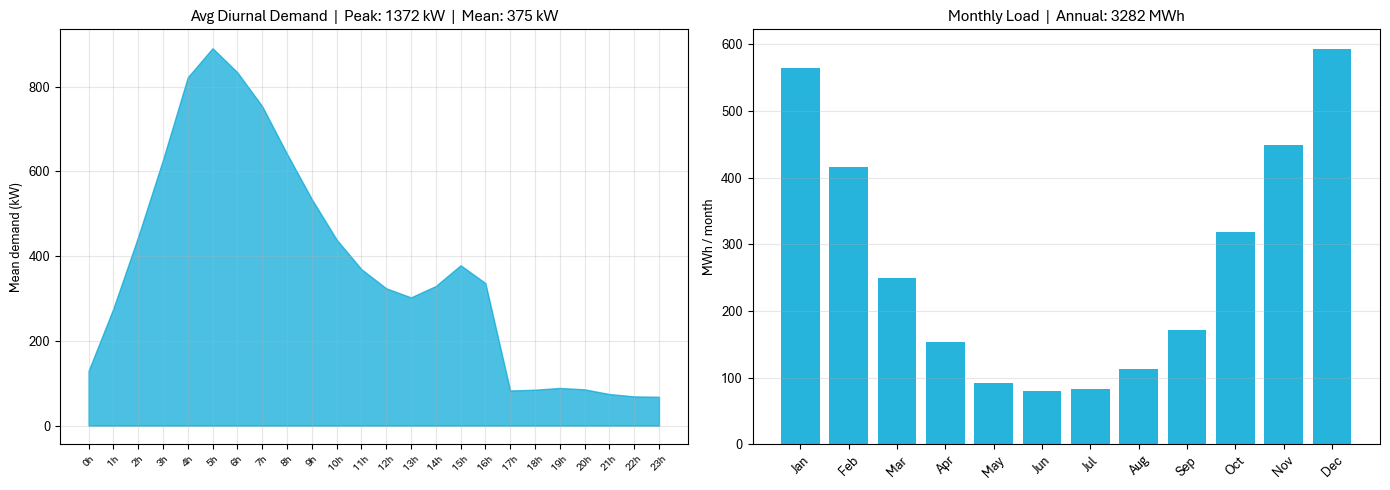

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# ELECTRICITY SYSTEM MODEL  —  NL Greenhouse (PyPSA)
#
# Single network: electricity bus only
# Jointly optimises:
#   Battery : energy + power capacity (extendable)
# Fixed:
#   PV  (capacity from input profile, dispatch via p_max_pu)
#   Grid connection (import/export limits from Cell 0)
# ════════════════════════════════════════════════════════════════════════════

# LP capital costs use expansion costs only — benchmark floor cost is sunk/fixed
# "Other project costs" (130 EUR/kWh) are benchmark-only; do not grow with expansion
_bat_store_cap  = EXPANSION_ENERGY_MEUR_MWH * 1e6 / 1e3 / BATTERY_LIFE_YR                                              # €/kWh/yr — expansion energy only
_bat_link_cap   = (EXPANSION_POWER_MEUR_MW * 1e6 / 1e3 / BATTERY_LIFE_YR) / 2 + BATTERY_OM_KEUR_MW_YR * 1e3 / 1e3 / 2  # €/kW/yr per link — expansion power + O&M on total power



_PV_NOM_KW     = float(pv_kw.max())
_PV_PU         = (pv_kw / _PV_NOM_KW).clip(upper=1.0)
_BAT_OFF       = int(round(OUTAGE_WEEKS * 7 * 24 / DT))   # 15-min intervals
_BAT_MAX_PU    = pd.Series(1.0, index=df.index)
# Place outage at end of August (planned annual maintenance)
_OUTAGE_START  = pd.Timestamp(f"{df.index[0].year}-08-25")
if _OUTAGE_START < df.index[0]:          # data starts after Aug 25 → use next year
    _OUTAGE_START = pd.Timestamp(f"{df.index[0].year + 1}-08-25")
_OUTAGE_IDX    = int(df.index.searchsorted(_OUTAGE_START))
_BAT_MAX_PU.iloc[_OUTAGE_IDX : _OUTAGE_IDX + _BAT_OFF] = 0.0

# Hourly resampled series for investment sizing (4x faster solve)
_H              = pd.date_range(df.index[0], periods=len(df)//4, freq='h')
_PV_PU_H        = _PV_PU.resample('h').mean()
_load_kw_H      = load_kw.resample('h').mean()
_import_price_H = import_price.resample('h').mean()
_da_price_H     = da_price.resample('h').mean()
_BAT_MAX_PU_H   = _BAT_MAX_PU.resample('h').min()
_P_EXPORT_NOM  = GRID_EXPORT_MAX_KW if GRID_EXPORT_MAX_KW else _PV_NOM_KW * 1.1
_P_IMPORT_ELEC = GRID_IMPORT_MAX_KW if GRID_IMPORT_MAX_KW else float(load_kw.max()) * 2



def _make_network(snapshots=None, dt=None):
    n = pypsa.Network()
    n.set_snapshots(snapshots if snapshots is not None else df.index)
    n.snapshot_weightings.loc[:, :] = dt if dt is not None else DT
    return n


def _add_elec_bus(n, p_import, p_export, mc_import, mc_export, pv_pu=None, elec_load=None):
    n.add("Carrier", "electricity")
    n.add("Bus", "elec", carrier="electricity")
    n.add("Generator", "pv", bus="elec", p_nom=_PV_NOM_KW, marginal_cost=0.0)
    n.generators_t.p_max_pu["pv"] = pv_pu if pv_pu is not None else _PV_PU
    n.add("Load", "elec_load", bus="elec")
    n.loads_t.p_set["elec_load"] = elec_load if elec_load is not None else load_kw
    n.add("Generator", "grid_import", bus="elec", p_nom=p_import, marginal_cost=0.0)
    n.generators_t.marginal_cost["grid_import"] = mc_import
    n.add("Generator", "grid_export", bus="elec", p_nom=p_export,
          p_min_pu=-1, p_max_pu=0, marginal_cost=0.0)
    n.generators_t.marginal_cost["grid_export"] = mc_export


def _add_battery(n, extendable=True, bat_e=None, bat_p=None, max_pu=None):
    n.add("Bus", "battery_bus", carrier="electricity")

    pu    = max_pu if max_pu is not None else _BAT_MAX_PU
    if extendable:
        n.add("Store", "battery_store", bus="battery_bus",
              e_nom=0, e_nom_min=BATTERY_BENCHMARK_KWH,
              e_nom_extendable=True, e_cyclic=True,
              standing_loss=BATTERY_SELF_DISCHARGE_HR,
              capital_cost=_bat_store_cap, marginal_cost=0.0)
        n.add("Link", "bat_charge", bus0="elec", bus1="battery_bus",
              p_nom=0, p_nom_min=BATTERY_BENCHMARK_MW * 1e3, p_nom_extendable=True,
              efficiency=BATTERY_EFFICIENCY_STORE,
              capital_cost=_bat_link_cap, marginal_cost=0.0)
        n.add("Link", "bat_discharge", bus0="battery_bus", bus1="elec",
              p_nom=0, p_nom_min=BATTERY_BENCHMARK_MW * 1e3, p_nom_extendable=True,
              efficiency=BATTERY_EFFICIENCY_DISPATCH,
              capital_cost=_bat_link_cap, marginal_cost=0.0)
    else:
        n.add("Store", "battery_store", bus="battery_bus",
              e_nom=bat_e, e_cyclic=True,
              standing_loss=BATTERY_SELF_DISCHARGE_HR, marginal_cost=0.0)
        n.add("Link", "bat_charge", bus0="elec", bus1="battery_bus",
              p_nom=bat_p, efficiency=BATTERY_EFFICIENCY_STORE, marginal_cost=0.0)
        n.add("Link", "bat_discharge", bus0="battery_bus", bus1="elec",
              p_nom=bat_p, efficiency=BATTERY_EFFICIENCY_DISPATCH, marginal_cost=0.0)
    n.links_t.p_max_pu["bat_charge"]    = pu
    n.links_t.p_max_pu["bat_discharge"] = pu


def build_elec_only_network(solve=True, extra_functionality=None):
    """Battery + PV + grid only. Hourly timestep for investment sizing."""
    n = _make_network(snapshots=_H, dt=1.0)
    _add_elec_bus(n, _P_IMPORT_ELEC, _P_EXPORT_NOM, _import_price_H, _da_price_H,
                  pv_pu=_PV_PU_H, elec_load=_load_kw_H)
    _add_battery(n, extendable=True, max_pu=_BAT_MAX_PU_H)             # planned outage at end of August
    n.sanitize()
    if solve:
        kw = {}
        if extra_functionality is not None:
            kw['extra_functionality'] = extra_functionality
        status, cond = n.optimize(solver_name='highs', log_to_console=False, **kw)
        if status not in ('ok', 'warning'):
            raise RuntimeError(f'Elec-only solve failed: {cond}')
    return n


def _add_cycle_constraint(n, snapshots):
    """Hard annual cycle cap: sum(bat_discharge * DT_H) <= MAX_CYCLES_PER_YEAR * e_nom.
    Linear constraint (MAX_CYCLES_PER_YEAR is a constant, e_nom is a variable).
    """
    m = n.model
    if 'Link-p' not in m.variables or 'battery_store' not in n.stores.index:
        return
    p     = m.variables['Link-p']
    p_dim = [d for d in p.dims if d != 'snapshot'][0]
    if 'bat_discharge' not in list(p.coords[p_dim].values):
        return
    dis = p.sel({p_dim: 'bat_discharge'})
    # e_nom is a variable when battery is extendable
    if 'Store-e_nom' in m.variables:
        e_nom_var = m.variables['Store-e_nom']
        e_dim     = [d for d in e_nom_var.dims][0]
        bat_e_nom = e_nom_var.sel({e_dim: 'battery_store'})
    else:
        bat_e_nom = float(n.stores.at['battery_store', 'e_nom'])
    m.add_constraints(
        (dis * DT_H).sum('snapshot') - MAX_CYCLES_PER_YEAR * bat_e_nom <= 0,
        name='max_annual_cycles'
    )
    print(f'  [cycle] Max {MAX_CYCLES_PER_YEAR:.0f} cycles/yr constraint active')


def _add_all_constraints(n, snapshots):
    _add_cycle_constraint(n, snapshots)


def _pv_ss_flows(pv_kw, gi_kw, ge_kw, bc_kw, bd_kw, soc_kwh, load_kw, dt=None):
    """PV self-sufficiency via proportional bus-flow allocation.
    At each PTU all sources (PV, grid_import, bat_discharge) mix at the bus
    and flow to sinks (load, bat_charge, grid_export) in proportion.
    PV-origin fraction of battery SOC is tracked iteratively.
    Credits PV to load whether direct or via battery;
    correctly excludes PV that ultimately goes to export.
    """
    dt = dt if dt is not None else DT_H
    pv_arr  = pv_kw.values;   gi_arr = gi_kw.values;  ge_arr = ge_kw.values
    bc_arr  = bc_kw.values;   bd_arr = bd_kw.values;  soc_arr = soc_kwh.values
    lk_arr  = load_kw.values
    pv_to_load = 0.0   # cumulative PV energy credited to load (kWh)
    pv_in_bat  = 0.0   # PV-origin energy currently in battery (kWh)
    prev_soc   = 0.0
    for t in range(len(pv_arr)):
        pv = pv_arr[t]; gi = gi_arr[t]; ge = ge_arr[t]
        bc = bc_arr[t]; bd = bd_arr[t]; soc_end = soc_arr[t]
        lk = lk_arr[t]
        total_supply = pv + gi + bd
        total_demand = lk + bc + ge
        if total_supply < 1e-9 or total_demand < 1e-9:
            prev_soc = soc_end
            continue
        # PV-origin fraction of battery SOC (tracked from previous step)
        bat_pv_frac = min(pv_in_bat / prev_soc, 1.0) if prev_soc > 0 else 0.0
        # Effective PV-origin power at the bus: direct PV + PV-attributed discharge
        pv_origin = pv + bd * bat_pv_frac
        # PV to load: proportional share of pv_origin flowing to load sink
        pv_to_load += pv_origin * (lk / total_demand) * dt
        # Update battery PV shadow account
        if bc > 0:
            # PV fraction of charging power × charging efficiency
            pv_in_bat += (pv / total_supply) * bc * BATTERY_EFFICIENCY_STORE * dt
        if bd > 0 and prev_soc > 0:
            # Energy leaving battery (battery-side, = elec-side / efficiency)
            pv_in_bat = max(pv_in_bat - bat_pv_frac * (bd / BATTERY_EFFICIENCY_DISPATCH) * dt, 0.0)
        pv_in_bat = min(pv_in_bat, soc_end)   # cap to actual SOC
        prev_soc  = soc_end
    total_load_kwh = float((load_kw * dt).sum())
    total_pv_kwh   = float((pv_kw  * dt).sum())
    ss     = (pv_to_load / total_load_kwh * 100) if total_load_kwh > 0 else 0.0
    sc_load = (pv_to_load / total_pv_kwh  * 100) if total_pv_kwh  > 0 else 0.0
    return ss, sc_load

def _attr_export(pv_kw, gi_kw, ge_kw, bc_kw, bd_kw, soc_kwh, da_price, dt=None):
    """Attribute export revenue to: PV-direct, PV-via-battery, Grid-via-battery."""
    dt = dt if dt is not None else DT_H
    pv_arr  = pv_kw.values;  gi_arr = gi_kw.values;  ge_arr = ge_kw.values
    bc_arr  = bc_kw.values;  bd_arr = bd_kw.values;  soc_arr = soc_kwh.values
    pr_arr  = da_price.values
    pv_in_bat = 0.0;  prev_soc = 0.0
    pv_dir_kwh = 0.0;  pv_bat_kwh = 0.0;  gi_bat_kwh = 0.0
    pv_dir_eur = 0.0;  pv_bat_eur = 0.0;  gi_bat_eur = 0.0
    for t in range(len(pv_arr)):
        pv = pv_arr[t]; gi = gi_arr[t]; ge = ge_arr[t]
        bc = bc_arr[t]; bd = bd_arr[t]; soc_end = soc_arr[t]; pr = pr_arr[t]
        total_supply = pv + gi + bd
        if total_supply < 1e-9:
            prev_soc = soc_end; continue
        bat_pv_frac = min(pv_in_bat / prev_soc, 1.0) if prev_soc > 0 else 0.0
        if ge > 0:
            pv_direct_to_export = pv * (ge / total_supply)
            bat_to_export       = bd * (ge / total_supply)
            pv_via_bat_export   = bat_to_export * bat_pv_frac
            gi_via_bat_export   = bat_to_export * (1.0 - bat_pv_frac)
            pv_dir_kwh += pv_direct_to_export * dt
            pv_bat_kwh += pv_via_bat_export   * dt
            gi_bat_kwh += gi_via_bat_export   * dt
            rev = ge * dt * pr  # EUR (price in EUR/kWh, power in kW, dt in h)
            if ge > 1e-9:
                pv_dir_eur += rev * (pv_direct_to_export / ge)
                pv_bat_eur += rev * (pv_via_bat_export   / ge)
                gi_bat_eur += rev * (gi_via_bat_export   / ge)
        if bc > 0:
            pv_in_bat += (pv / total_supply) * bc * BATTERY_EFFICIENCY_STORE * dt
        if bd > 0 and prev_soc > 0:
            pv_in_bat = max(pv_in_bat - bat_pv_frac * (bd / BATTERY_EFFICIENCY_DISPATCH) * dt, 0.0)
        pv_in_bat = min(pv_in_bat, soc_end);  prev_soc = soc_end
    return (pv_dir_kwh/1000, pv_bat_kwh/1000, gi_bat_kwh/1000,
            pv_dir_eur,      pv_bat_eur,      gi_bat_eur)


# ════════════════════════════════════════════════════════════════════════════
# SOLVE — Electricity-only investment optimisation
# ════════════════════════════════════════════════════════════════════════════

print("Solving electricity-only network (battery + PV + grid) ...")
n_elec = build_elec_only_network(solve=True, extra_functionality=_add_all_constraints)
print("  → OK")

# ── Extract optimised capacities ──────────────────────────────────────────────
bat_e_kwh  = float(n_elec.stores.at['battery_store', 'e_nom_opt'])
bat_p_kw   = float(n_elec.links.at['bat_charge', 'p_nom_opt'])
bat_c_rate = bat_p_kw / bat_e_kwh if bat_e_kwh > 0 else 0.0

pv_kw_opt   = n_elec.generators_t.p['pv']
ei_kw       = n_elec.generators_t.p['grid_import']
ee_kw       = (-n_elec.generators_t.p['grid_export']).clip(lower=0)
bat_chg_kw  = n_elec.links_t.p0['bat_charge']
bat_dis_kw  = (-n_elec.links_t.p1['bat_discharge']).clip(lower=0)
bat_soc_kwh = n_elec.stores_t.e['battery_store']

# PV curtailment: available generation minus what was actually dispatched
pv_avail_kw_H     = (_PV_PU_H * _PV_NOM_KW).reindex(n_elec.snapshots)
pv_curtailed_kw_H = (pv_avail_kw_H - pv_kw_opt).clip(lower=0)

bat_fix_eur   = annual_om(bat_p_kw)
pv_capex_tot  = PV_MODULES * MODULE_WP * PV_CAPEX_EUR_WP
pv_ann_cap    = pv_capex_tot / PV_LIFETIME_YR

bat_dis_kwh_yr = float((bat_dis_kw * DT_H).sum())
bat_cycles     = bat_dis_kwh_yr / bat_e_kwh if bat_e_kwh > 0 else 0.0

pv_kwh_opt_tot    = float((pv_kw_opt * DT_H).sum())
pv_mwh_opt        = pv_kwh_opt_tot / 1000
pv_avail_mwh      = float((pv_avail_kw_H * DT_H).sum()) / 1000
pv_curtailed_mwh  = float((pv_curtailed_kw_H * DT_H).sum()) / 1000
pv_curtail_pct    = pv_curtailed_mwh / pv_avail_mwh * 100 if pv_avail_mwh > 0 else 0.0

print(f"\n╔══ OPTIMISED CAPACITIES (hourly investment LP) ═════════════════════╗")
print(f"║  Battery                                                         ║")
print(f"║    Energy  : {bat_e_kwh:>8,.0f} kWh                                   ║")
print(f"║    Power   : {bat_p_kw:>8,.0f} kW                                    ║")
print(f"║    C-rate  : {bat_c_rate:>8.3f}  1/h                              ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  PV  (fixed capacity)                                            ║")
print(f"║    Capacity: {_PV_NOM_KW:>8,.0f} kW_p  ({PV_MODULES:,} x {MODULE_WP} Wp)              ║")
print(f"║    Annual  : {pv_mwh_opt:>8,.0f} MWh_e/yr  (sizing run, hourly)       ║")
print(f"║    Curtailed: {pv_curtailed_mwh:>7,.1f} MWh_e/yr ({pv_curtail_pct:.1f}%)               ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  ANNUALISED CAPEX  (see Cell 5 for full economics)               ║")
print(f"║  PV system ({PV_LIFETIME_YR} yr)  : €{pv_ann_cap:>10,.0f}/yr  (total €{pv_capex_tot:,.0f})    ║")
print(f"╚═══════════════════════════════════════════════════════════════════╝")
print()


# ============================================================================
# SIZING SANITY CHECK  (hourly network -- preliminary only)
# Physical metrics and economics: run Cell 3 / Cell 5 for 15-min results.
# ============================================================================
_ss_h, _sc_h = _pv_ss_flows(pv_kw_opt, ei_kw, ee_kw, bat_chg_kw, bat_dis_kw, bat_soc_kwh, _load_kw_H)
_net_cost_h  = float((ei_kw * _import_price_H * DT_H).sum()) - float((ee_kw * _da_price_H * DT_H).sum())

print("-" * 70)
print("  SIZING SANITY CHECK  (hourly, preliminary -- see Cell 3 for 15-min)")
print("-" * 70)
print(f"  SS approx          : {_ss_h:.1f}%  (hourly; Cell 3 gives 15-min SS)")
print(f"  SC load-only approx: {_sc_h:.1f}%")
print(f"  Battery cycles/yr  : {bat_cycles:.0f}  (constraint limit: {MAX_CYCLES_PER_YEAR:.0f})")
print(f"  Battery C-rate     : {bat_c_rate:.3f}  1/h")
print(f"  PV curtailment     : {pv_curtail_pct:.1f}%")
print(f"  Net elec cost (h)  : €{_net_cost_h:,.0f}/yr  [Cell 5 for 15-min economics]")
if bat_c_rate > 1.5:
    print(f"  WARNING: high C-rate {bat_c_rate:.2f}")
if bat_cycles > MAX_CYCLES_PER_YEAR * 1.02:
    print(f"  WARNING: cycles {bat_cycles:.0f} near/above limit {MAX_CYCLES_PER_YEAR:.0f}")
print("-" * 70)
print()

# PV PRODUCTION PATTERNS
# ════════════════════════════════════════════════════════════════════════════

# Hourly average PV output by month (using full 15-min data)
_pv_df = pd.DataFrame({
    "month": pv_kw.index.month,
    "hour":  pv_kw.index.hour,
    "pv_kw": pv_kw.values,
})
pivot_pv = _pv_df.groupby(["month","hour"])["pv_kw"].mean().unstack(level=1)
pivot_pv.index = MONTHS

fig_pv1, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot_pv.reindex(columns=range(24)).fillna(0).values,
               aspect="auto", cmap="Greens")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h}h" for h in range(24)], rotation=45, fontsize=7)
ax.set_yticks(range(12)); ax.set_yticklabels(MONTHS)
ax.set_title(f"Average PV Output per Hour/Month (kW)  |  PV capacity: {_PV_NOM_KW:,.0f} kW_p")
plt.colorbar(im, ax=ax, label="kW")
plt.tight_layout()
plt.savefig("nl_pv_heatmap.png", dpi=150)
plt.show()

# Monthly PV production histogram
pv_monthly = (pv_kw * DT).groupby(pv_kw.index.month).sum() / 1000  # MWh
load_monthly_h = (_load_kw_H * DT_H).groupby(_load_kw_H.index.month).sum() / 1000  # MWh
x12 = np.arange(12)

fig_pv2, axes_pv = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes_pv[0].bar(x12 - 0.2, pv_monthly.values, 0.4,
               color="#30FF2C", alpha=0.85, label=f"PV (annual: {pv_monthly.sum():.0f} MWh)")
axes_pv[0].bar(x12 + 0.2, load_monthly_h.values, 0.4,
               color="#00A6D6", alpha=0.85, label=f"Load (annual: {load_monthly_h.sum():.0f} MWh)")
axes_pv[0].set_ylabel("MWh / month")
axes_pv[0].set_title("Monthly PV Production vs Electricity Load")
axes_pv[0].legend(); axes_pv[0].grid(True, alpha=0.3, axis="y")

# PV vs load ratio (monthly self-sufficiency potential)
_ratio = (pv_monthly / load_monthly_h * 100).clip(upper=150)
axes_pv[1].bar(x12, _ratio.values, color="#30FF2C", alpha=0.85)
axes_pv[1].axhline(100, color="#5AD6E7", lw=1.2, ls="--", label="PV = Load")
axes_pv[1].set_xticks(x12); axes_pv[1].set_xticklabels(MONTHS)
axes_pv[1].set_ylabel("PV / Load (%)")
axes_pv[1].set_title("Monthly PV / Load Ratio  (>100% = surplus month)")
axes_pv[1].legend(); axes_pv[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_pv_vs_load_monthly.png", dpi=150)
plt.show()

# Average diurnal PV profile (all months)
pv_hourly_avg = _pv_df.groupby("hour")["pv_kw"].mean()
fig_pv3, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(pv_hourly_avg.index, pv_hourly_avg.values, alpha=0.7, color="#30FF2C")
ax.axhline(pv_hourly_avg.mean(), color="#1FEAD6", lw=1.2, ls="--",
           label=f"Annual mean: {pv_hourly_avg.mean():.0f} kW")
ax.set_xticks(range(24)); ax.set_xticklabels([f"{h}h" for h in range(24)], rotation=45, fontsize=8)
ax.set_ylabel("Mean PV output (kW)")
ax.set_title(f"Average Diurnal PV Profile  |  Capacity: {_PV_NOM_KW:,.0f} kW_p  |  {PV_MODULES:,} modules × {MODULE_WP}Wp")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nl_pv_diurnal.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# ELECTRICITY DEMAND PATTERNS
# ════════════════════════════════════════════════════════════════════════════

_load_df = pd.DataFrame({
    "month": load_kw.index.month,
    "hour":  load_kw.index.hour,
    "load_kw": load_kw.values,
})
pivot_load = _load_df.groupby(["month","hour"])["load_kw"].mean().unstack(level=1)
pivot_load.index = MONTHS

fig_ld1, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot_load.reindex(columns=range(24)).fillna(0).values,
               aspect="auto", cmap="BuGn")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h}h" for h in range(24)], rotation=45, fontsize=7)
ax.set_yticks(range(12)); ax.set_yticklabels(MONTHS)
ax.set_title("Average Electricity Demand per Hour/Month (kW)")
plt.colorbar(im, ax=ax, label="kW")
plt.tight_layout()
plt.savefig("nl_load_heatmap.png", dpi=150)
plt.show()

load_hourly_avg = _load_df.groupby("hour")["load_kw"].mean()
fig_ld2, axes_ld = plt.subplots(1, 2, figsize=(14, 5))

ax = axes_ld[0]
ax.fill_between(load_hourly_avg.index, load_hourly_avg.values, alpha=0.7, color="#00A6D6")
ax.set_xticks(range(24)); ax.set_xticklabels([f"{h}h" for h in range(24)], rotation=45, fontsize=8)
ax.set_ylabel("Mean demand (kW)")
ax.set_title(f"Avg Diurnal Demand  |  Peak: {load_kw.max():.0f} kW  |  Mean: {load_kw.mean():.0f} kW")
ax.grid(True, alpha=0.3)

ax = axes_ld[1]
load_monthly_kwh_full = (load_kw * DT).groupby(load_kw.index.month).sum() / 1000
ax.bar(range(12), load_monthly_kwh_full.values, color="#00A6D6", alpha=0.85)
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_ylabel("MWh / month")
ax.set_title(f"Monthly Load  |  Annual: {load_monthly_kwh_full.sum():.0f} MWh")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("nl_load_patterns.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════════════════════

=== IMBALANCE DATA STATUS ===
  Settlement prices : loaded
  Imbalance volume  : loaded
  Regulation states : {-1: np.int64(11716), 0: np.int64(479), 1: np.int64(12185), 2: np.int64(10660)}
  State 2 (zeroed)  : 30.4% of PTUs
  Grid stress range : -451483.7583 – 1860578.8903
  Scarcity thr (75th pct of +ve): 11159.4257
  Surplus  thr (25th pct of -ve): -3938.8981
  Flagged PTUs : 5944 / 35040 = 17.0%

Fixed capacities for dispatch scenarios:
  Battery : 13,253 kWh / 3,600 kW  (Cell 2 optimum)
  PV      : 1,178 kW_p  (fixed)

Running S1 — no-PV, no-battery (declared program) ...


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 53.25it/s]
INFO:linopy.io: Writing time: 0.21s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70080 primals, 175200 duals
Objective: 5.07e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Running S2 — PV-only, no battery ...


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 40.50it/s]
INFO:linopy.io: Writing time: 0.24s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105120 primals, 245280 duals
Objective: 4.20e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Running S3 — DA-only (PV + battery) ...


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 51.44it/s]
INFO:linopy.io: Writing time: 0.62s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245280 primals, 525600 duals
Objective: 1.87e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


All dispatch scenarios complete.

  KPI                                    S1 declared  S2 PV-only   S3 DA+bat
  Net electricity cost (€/yr)                506,932     420,083     186,792
------------------------------------------------------------------------------
  Self-sufficiency simple (%)                   0.0%        9.2%        9.2%
  Self-sufficiency load-only (%)                0.0%        9.2%       15.6%
------------------------------------------------------------------------------
  Self-consumption simple (%)                   0.0%       27.8%       90.2%
  Self-consumption load-only (%)                0.0%       27.8%       35.4%
------------------------------------------------------------------------------
  Imbalance P&L vs S1 declared (€/yr)              —      18,002      23,204
  Passive align — binary top25% (%)                —       24.5%       55.3%
  Passive align — weighted all (%)                 —       38.9%       67.6%
  Deviation from S1 (MWh/yr)        

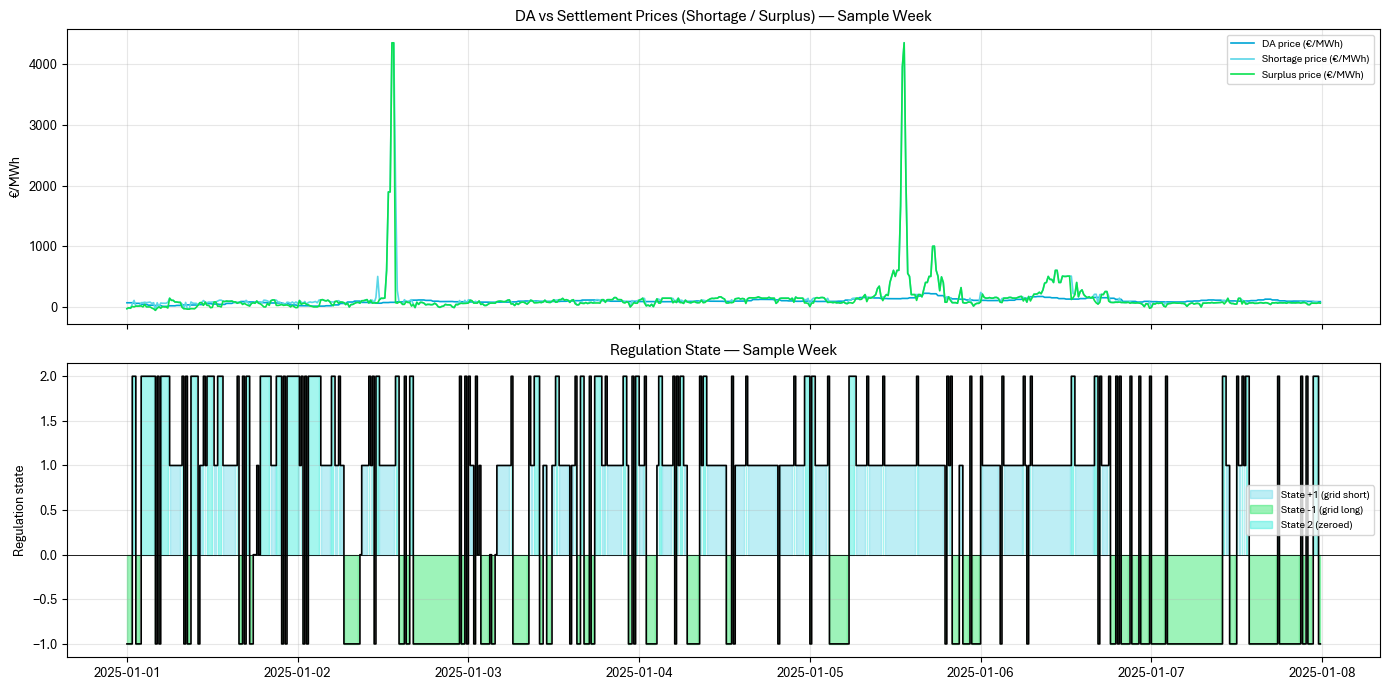

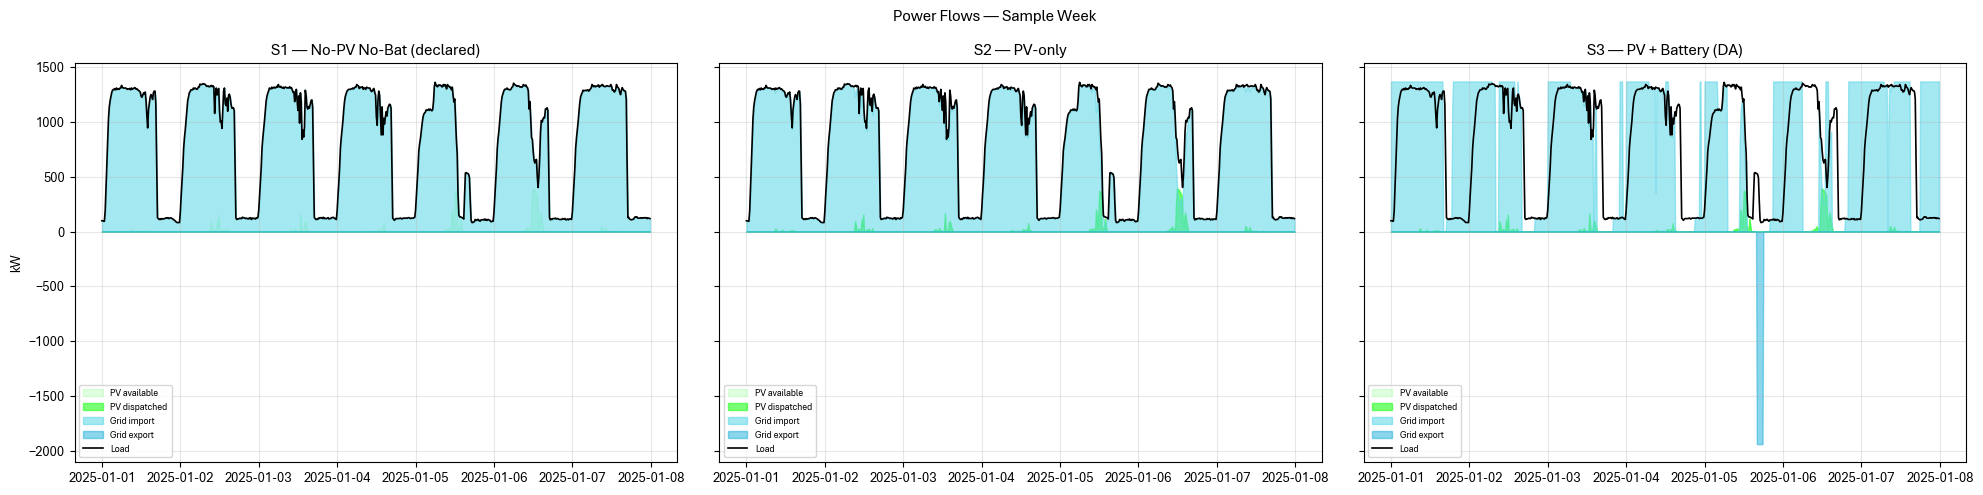

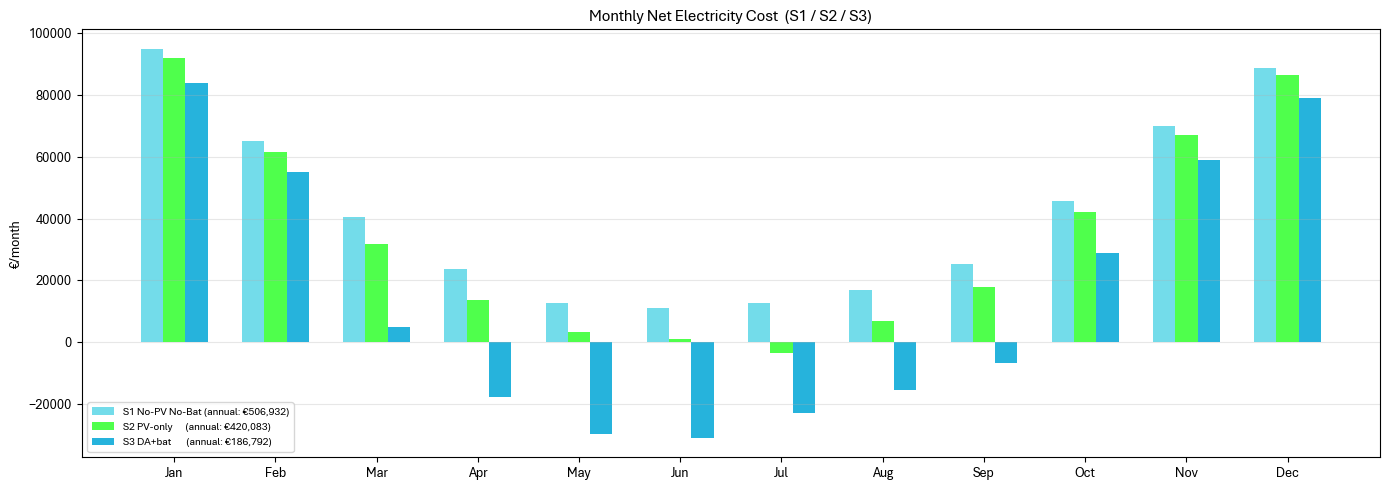

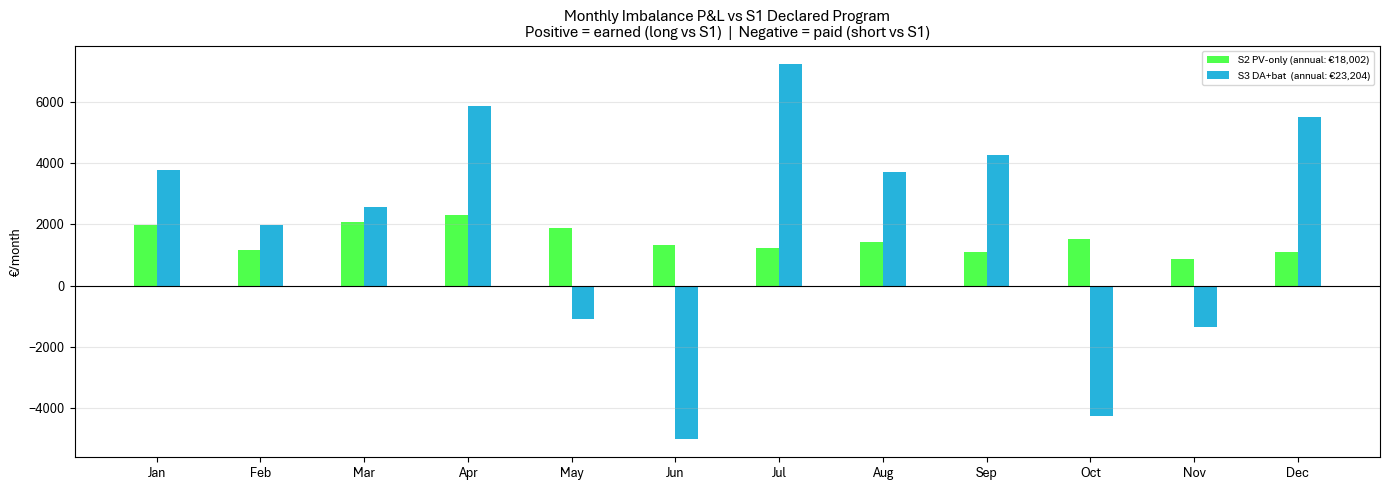

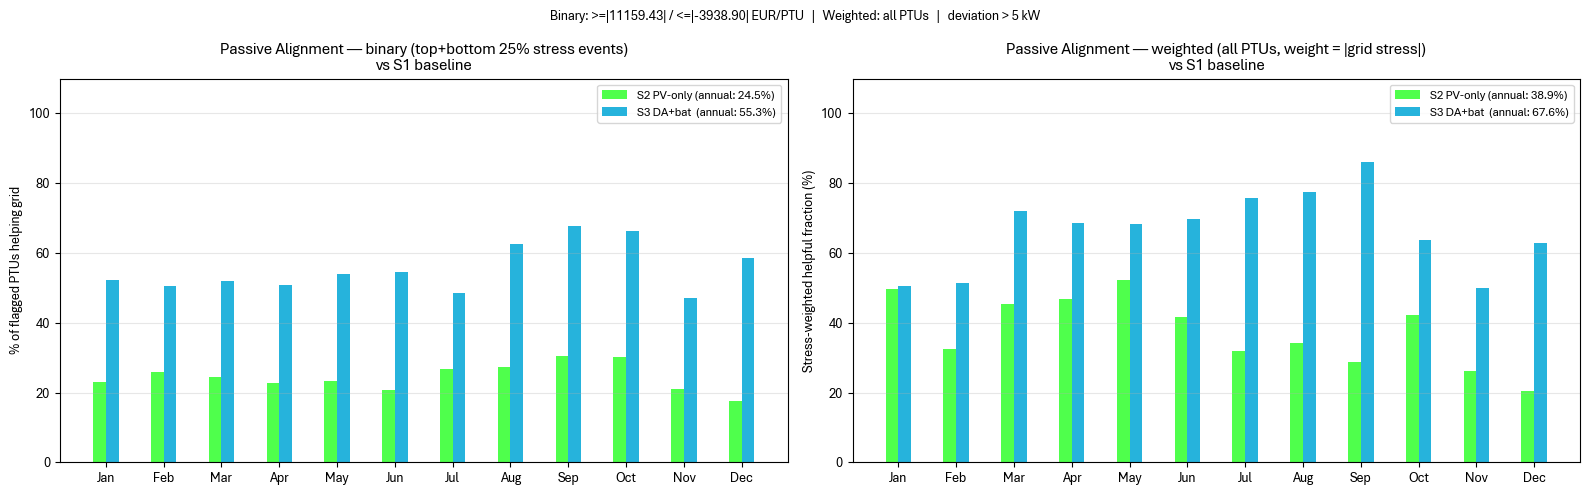

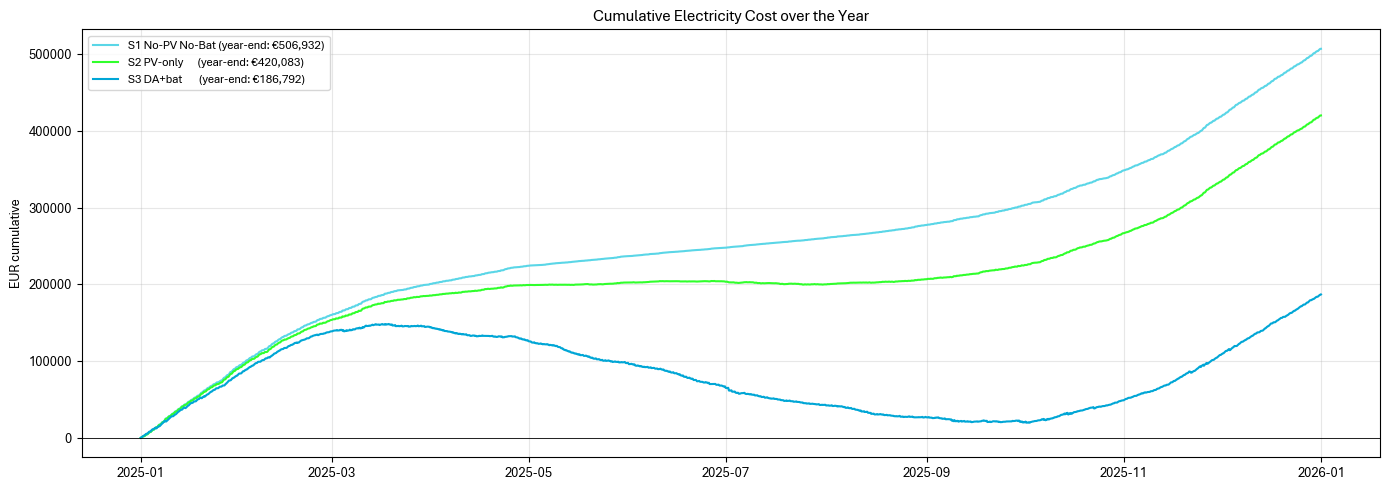

Part II (Grid Alignment Analysis) complete.

╔══ ELECTRICITY (S3, 15-min dispatch) ══════════════════════════════╗
║  PV production    :     1,450 MWh_e                         ║
║  PV curtailment   :       2.3 MWh_e  (0.2%)                  ║
║  Grid import      :     3,817 MWh_e                         ║
║  Grid export      :     1,820 MWh_e                         ║
║    PV direct→grid :       165 MWh_e  €  17,008/yr        ║
║    PV via battery :       720 MWh_e  €  97,835/yr        ║
║    Grid via batt. :       936 MWh_e  € 133,734/yr        ║
║  Battery charged  :     3,284 MWh_e                         ║
║  Battery dischgd  :     3,120 MWh_e                         ║
║  Battery cycles/yr:       235                                ║
║  SC simple (PV absorbed locally) :    90.2%                       ║
║  SC load-only (PV to load)       :    35.4%                       ║
║  SS simple (direct PV to load)   :     9.2%                       ║
║  SS load-only (PV self-suff.)    :    15

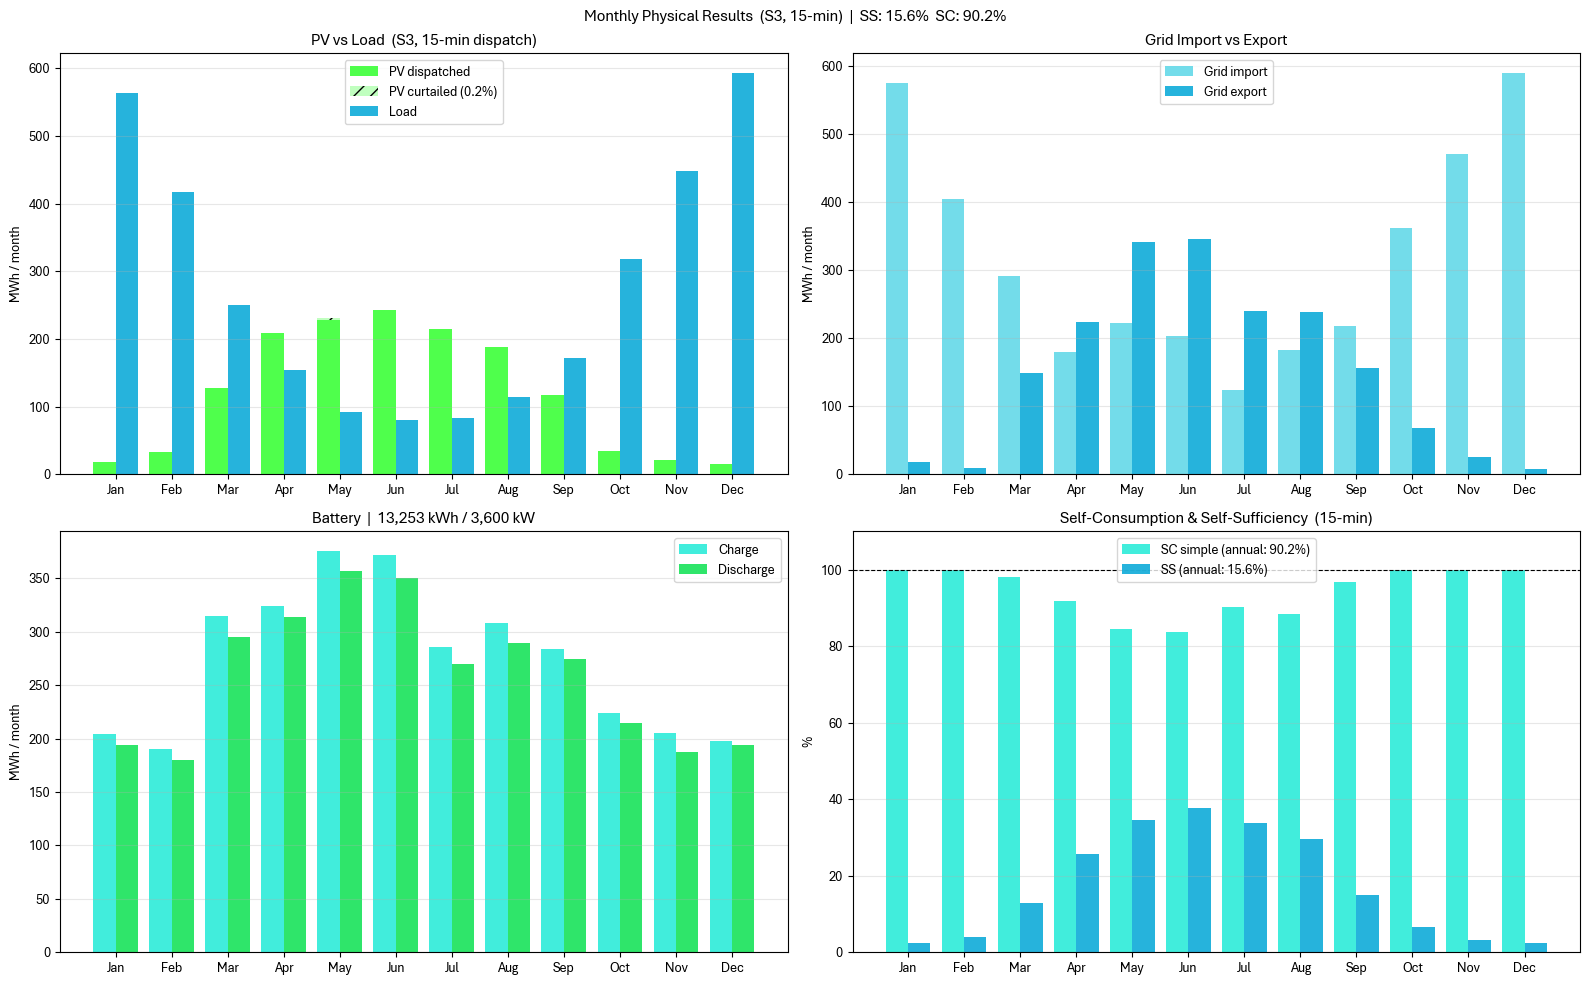

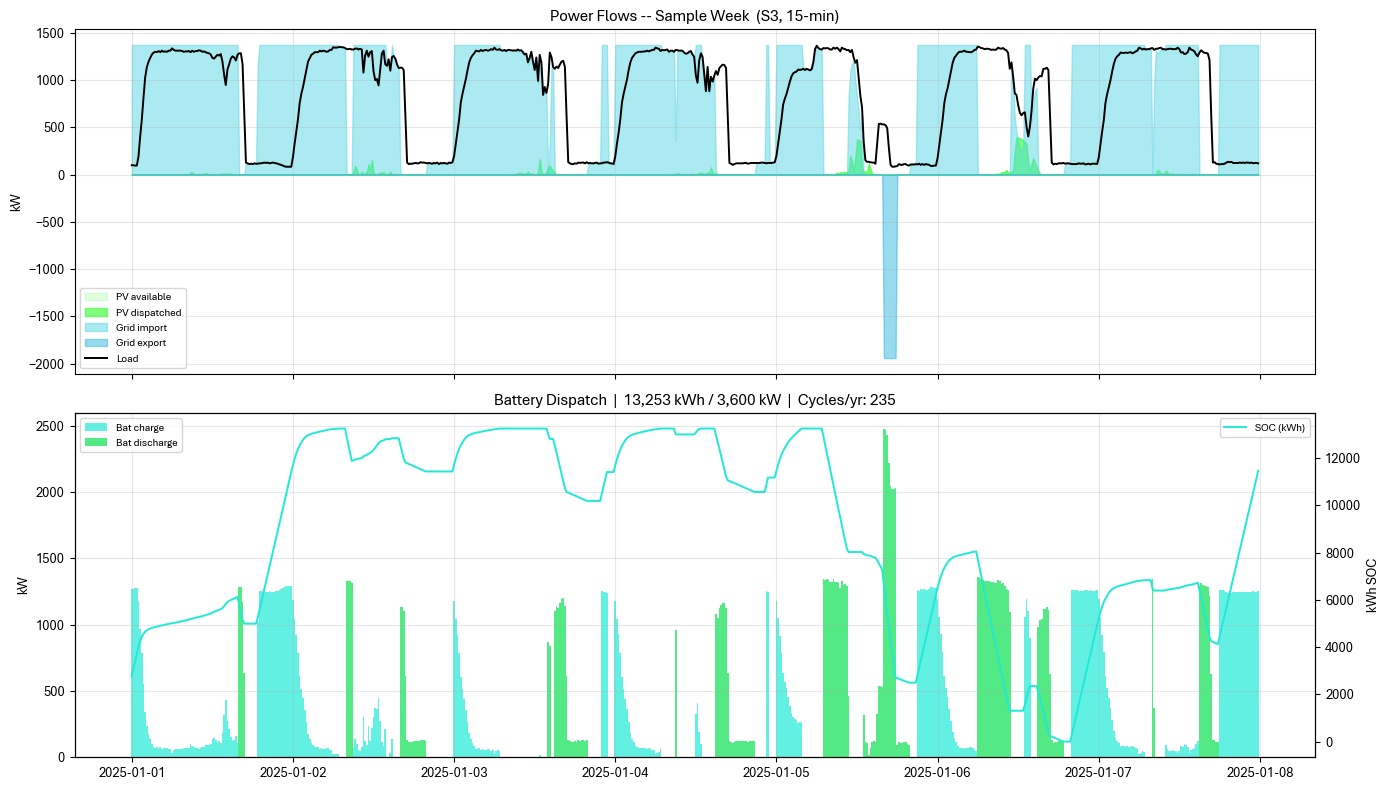

Physical dispatch analysis complete (S3, 15-min).


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# PART II  —  GRID ALIGNMENT ANALYSIS  (Imbalance Market, Electricity-Only)
# ════════════════════════════════════════════════════════════════════════════
# Requires Part I (cell above) to have run first.
# Uses optimised battery capacities from Cell 2: bat_e_kwh / bat_p_kw
#
# Three scenarios:
#   S1  No-PV, no-battery  — declared program (pure grid, no flexibility)
#   S2  PV-only            — PV without battery
#   S3  DA-only            — PV + battery, driven by day-ahead prices (= res2)
#
# Grid stress:  regulation_state × price_severity × settled_volume
#   direction from regulation state: +1=grid short, -1=grid long, 0=no action, 2=zeroed
#   price severity: Shortage price when state=+1, |Surplus price| when state=-1
#
# Imbalance P&L:  S1 is the declared program.
#   S2 and S3 deviate from S1 → earn/pay based on TenneT settlement prices.
# ════════════════════════════════════════════════════════════════════════════

# ─── IMBALANCE CONFIGURATION ─────────────────────────────────────────────────

COL_SHORTAGE_PRICE   = "Price Shortage  (EUR/MWh)"
COL_SURPLUS_PRICE    = "Price Surplus  (EUR/MWh)"
COL_REGULATION_STATE = "Regulation State"

STRESS_ALIGN_QUANTILE  = 0.75    # top/bottom fraction of stress events: 0.75 = top+bottom 25%
RESPONSE_THRESHOLD_KW  = 5.0     # kW  — min deviation to count as "responding"
STRESS_THRESHOLD_KWH   = 0.0     # |grid_stress| floor; 0.0 = all nonzero PTUs

# ─── LOAD IMBALANCE DATA & DERIVE GRID STRESS ────────────────────────────────

shortage_price   = df[COL_SHORTAGE_PRICE].fillna(0)  / 1000 if COL_SHORTAGE_PRICE   in df.columns else pd.Series(0.0, index=df.index)
surplus_price    = df[COL_SURPLUS_PRICE].fillna(0)   / 1000 if COL_SURPLUS_PRICE    in df.columns else pd.Series(0.0, index=df.index)
regulation_state = df[COL_REGULATION_STATE].fillna(0).astype(int) if COL_REGULATION_STATE in df.columns else pd.Series(0, index=df.index)

imb_volume_kwh = df[COL_IMBALANCE_VOL].fillna(0)

direction = regulation_state.map({1: 1, -1: -1, 0: 0, 2: 0}).astype(float)

price_severity = pd.Series(0.0, index=df.index)
price_severity[regulation_state == 1]  = shortage_price[regulation_state == 1]
price_severity[regulation_state == -1] = surplus_price[regulation_state == -1].abs()

grid_stress = direction * price_severity * imb_volume_kwh.abs()

_pos_gs   = grid_stress[grid_stress > 0]
_neg_gs   = grid_stress[grid_stress < 0]
_scar_thr = float(_pos_gs.quantile(STRESS_ALIGN_QUANTILE)) if len(_pos_gs) >= 4 else  np.inf
_surp_thr = float(_neg_gs.quantile(1 - STRESS_ALIGN_QUANTILE)) if len(_neg_gs) >= 4 else -np.inf

_has_imb = bool((shortage_price != 0).any() or (surplus_price != 0).any())
_has_vol = bool((imb_volume_kwh  >  0).any())

print("=== IMBALANCE DATA STATUS ===")
print(f"  Settlement prices : {'loaded' if _has_imb else 'EMPTY — fill Excel columns before running Part II'}")
print(f"  Imbalance volume  : {'loaded' if _has_vol else 'EMPTY — fill Excel column'}")
if _has_imb:
    state_counts = regulation_state.value_counts().sort_index()
    print(f"  Regulation states : {dict(state_counts)}")
    state2_pct = (regulation_state == 2).mean() * 100
    print(f"  State 2 (zeroed)  : {state2_pct:.1f}% of PTUs")
if _has_vol:
    print(f"  Grid stress range : {grid_stress.min():.4f} – {grid_stress.max():.4f}")
    _sig_all = (grid_stress >= _scar_thr) | (grid_stress <= _surp_thr)
    print(f"  Scarcity thr (75th pct of +ve): {_scar_thr:.4f}")
    print(f"  Surplus  thr (25th pct of -ve): {_surp_thr:.4f}")
    print(f"  Flagged PTUs : {_sig_all.sum()} / {len(grid_stress)} = {_sig_all.mean()*100:.1f}%")
print()

# ─── FIXED CAPACITIES ────────────────────────────────────────────────────────
print("Fixed capacities for dispatch scenarios:")
print(f"  Battery : {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW  (Cell 2 optimum)")
print(f"  PV      : {_PV_NOM_KW:,.0f} kW_p  (fixed)")
print()


# ════════════════════════════════════════════════════════════════════════════
# DISPATCH SCENARIO FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════

def _build_elec_dispatch_network(include_battery=True, include_pv=True):
    """Electricity-only dispatch network with fixed capacities from Cell 2."""
    n = pypsa.Network()
    n.set_snapshots(df.index)
    n.snapshot_weightings.loc[:, :] = DT

    n.add("Carrier", "electricity")
    n.add("Bus", "elec", carrier="electricity")
    if include_pv:
        n.add("Generator", "pv", bus="elec", p_nom=_PV_NOM_KW, marginal_cost=0)
        n.generators_t.p_max_pu["pv"] = _PV_PU
    n.add("Load", "elec_load", bus="elec")
    n.loads_t.p_set["elec_load"] = load_kw
    n.add("Generator", "grid_import", bus="elec", p_nom=_P_IMPORT_ELEC, marginal_cost=0)
    n.generators_t.marginal_cost["grid_import"] = import_price
    n.add("Generator", "grid_export", bus="elec", p_nom=_P_EXPORT_NOM,
          p_min_pu=-1, p_max_pu=0, marginal_cost=0)
    n.generators_t.marginal_cost["grid_export"] = da_price
    if include_battery:
        _add_battery(n, extendable=False, bat_e=bat_e_kwh, bat_p=bat_p_kw, max_pu=_BAT_MAX_PU)
    n.sanitize()
    return n


def _extract_dispatch(n):
    _zeros = pd.Series(0.0, index=n.snapshots)
    _has_pv  = "pv"            in n.generators_t.p.columns
    _has_bat = "battery_store" in n.stores_t.e.columns
    _pv_p    = n.generators_t.p["pv"]          if _has_pv  else _zeros
    _gi_p    = n.generators_t.p["grid_import"]  if "grid_import" in n.generators_t.p.columns else _zeros
    _ge_p    = n.generators_t.p["grid_export"]  if "grid_export" in n.generators_t.p.columns else _zeros
    return pd.DataFrame({
        "pv":            _pv_p,
        "pv_curtailed":  ((_PV_PU.reindex(n.snapshots) * _PV_NOM_KW) - _pv_p).clip(lower=0),
        "load":          n.loads_t.p_set["elec_load"],
        "grid_import":   _gi_p,
        "grid_export":   -_ge_p,
        "bat_charge":    n.links_t.p0["bat_charge"]       if _has_bat and "bat_charge"    in n.links_t.p0.columns else _zeros,
        "bat_discharge": -n.links_t.p1["bat_discharge"]   if _has_bat and "bat_discharge" in n.links_t.p1.columns else _zeros,
        "bat_soc":       n.stores_t.e["battery_store"]    if _has_bat else _zeros,
    }, index=n.snapshots)


def _compute_ss(res_df):
    ss, _ = _pv_ss_flows(
        res_df["pv"], res_df["grid_import"], res_df["grid_export"],
        res_df["bat_charge"], res_df["bat_discharge"], res_df["bat_soc"],
        res_df["load"], dt=DT)
    return ss


def _compute_sc_load(res_df):
    """SC load-only: PV energy serving load / total PV (proportional flow)."""
    _, sc = _pv_ss_flows(
        res_df["pv"], res_df["grid_import"], res_df["grid_export"],
        res_df["bat_charge"], res_df["bat_discharge"], res_df["bat_soc"],
        res_df["load"], dt=DT)
    return sc


def _compute_sc_simple(res_df):
    """SC simple: fraction of PV absorbed locally (load+battery) at each PTU.
    Includes PV→battery regardless of where battery later discharges.
    """
    total_pv = float((res_df["pv"] * DT).sum())
    if total_pv < 1e-9:
        return 0.0
    local = (res_df["pv"].clip(upper=(res_df["load"] + res_df["bat_charge"])) * DT).sum()
    return float(local) / total_pv * 100


def _compute_ss_simple(res_df):
    """SS simple: PV directly covering load / total load (no battery credit).
    Gap vs SS load-only shows battery contribution to load.
    """
    total_load = float((res_df["load"] * DT).sum())
    if total_load < 1e-9:
        return 0.0
    direct = (res_df["pv"].clip(upper=res_df["load"]) * DT).sum()
    return float(direct) / total_load * 100


def _bat_monthly_flows(res_df):
    """Monthly battery flow breakdown (MWh) using proportional bus allocation.
    PV→bat, Grid→bat : proportional share of charging power from each source
    Bat→load, Bat→export : proportional share of discharge to each sink
    """
    pv = res_df["pv"];  gi = res_df["grid_import"];  ge = res_df["grid_export"]
    bc = res_df["bat_charge"];  bd = res_df["bat_discharge"]
    lk = res_df["load"]
    total_supply = (pv + gi + bd).clip(lower=1e-9)
    total_demand = (lk + bc + ge).clip(lower=1e-9)
    months = pv.index.month
    def _mg_sum(s): return s.groupby(months).sum() * DT / 1e3   # → MWh
    return {
        "PV→bat":     _mg_sum(pv / total_supply * bc),
        "Grid→bat":   _mg_sum(gi / total_supply * bc),
        "Bat→load":   _mg_sum(bd * lk / total_demand),
        "Bat→export": _mg_sum(bd * ge / total_demand),
    }


def _calc_imb_pnl(scenario_import_kw, declared_import_kw):
    """Imbalance P&L vs declared program.
    Long (scenario imports less than declared): earn surplus price.
    Short (scenario imports more than declared): pay shortage price.
    Returns €/PTU time series (positive = revenue, negative = cost).
    """
    dev_kw = declared_import_kw - scenario_import_kw  # positive = long
    return dev_kw.clip(lower=0) * surplus_price * DT + dev_kw.clip(upper=0) * shortage_price * DT


def _calc_alignment(scenario_import_kw, baseline_import_kw):
    """Passive binary alignment: fraction of top-stress PTUs where scenario is grid-helpful vs baseline."""
    dev  = scenario_import_kw - baseline_import_kw
    sig  = (grid_stress >= _scar_thr) | (grid_stress <= _surp_thr)
    helping = (
        ((grid_stress >= _scar_thr) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress <= _surp_thr) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    n_sig   = sig.sum()
    n_help  = (helping & sig).sum()
    annual  = (n_help / n_sig * 100) if n_sig > 0 else 0.0
    vol_mwh = (dev.abs() * DT / 1000).sum()
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = sig.index.month == _m
        _n_s  = sig[_mask].sum()
        _n_h  = (helping & sig)[_mask].sum()
        monthly[_m] = (_n_h / _n_s * 100) if _n_s > 0 else 0.0
    return annual, monthly, vol_mwh


def _calc_active_alignment(scenario_import_kw, reference_import_kw):
    """Active binary alignment: fraction of stressed PTUs where scenario is MORE grid-helpful than reference."""
    dev  = scenario_import_kw - reference_import_kw
    sig  = (grid_stress >= _scar_thr) | (grid_stress <= _surp_thr)
    helping = (
        ((grid_stress >= _scar_thr) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress <= _surp_thr) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    n_sig  = sig.sum()
    n_help = (helping & sig).sum()
    annual  = (n_help / n_sig * 100) if n_sig > 0 else 0.0
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = sig.index.month == _m
        _n_s  = sig[_mask].sum()
        _n_h  = (helping & sig)[_mask].sum()
        monthly[_m] = (_n_h / _n_s * 100) if _n_s > 0 else 0.0
    return annual, monthly


def _calc_alignment_weighted(scenario_import_kw, baseline_import_kw):
    """Stress-weighted passive alignment: all nonzero-stress PTUs, weight = |grid_stress|."""
    dev        = scenario_import_kw - baseline_import_kw
    stress_abs = grid_stress.abs()
    nonzero    = stress_abs > 0
    helping    = (
        ((grid_stress > 0) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress < 0) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    w_total = stress_abs[nonzero].sum()
    w_help  = stress_abs[nonzero & helping].sum()
    annual  = (w_help / w_total * 100) if w_total > 0 else 0.0
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = nonzero.index.month == _m
        _wt   = stress_abs[nonzero & _mask].sum()
        _wh   = stress_abs[nonzero & helping & _mask].sum()
        monthly[_m] = (_wh / _wt * 100) if _wt > 0 else 0.0
    return annual, monthly


def _calc_active_alignment_weighted(scenario_import_kw, reference_import_kw):
    """Stress-weighted active alignment: scenario vs reference, weight = |grid_stress|."""
    dev        = scenario_import_kw - reference_import_kw
    stress_abs = grid_stress.abs()
    nonzero    = stress_abs > 0
    helping    = (
        ((grid_stress > 0) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress < 0) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    w_total = stress_abs[nonzero].sum()
    w_help  = stress_abs[nonzero & helping].sum()
    annual  = (w_help / w_total * 100) if w_total > 0 else 0.0
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = nonzero.index.month == _m
        _wt   = stress_abs[nonzero & _mask].sum()
        _wh   = stress_abs[nonzero & helping & _mask].sum()
        monthly[_m] = (_wh / _wt * 100) if _wt > 0 else 0.0
    return annual, monthly


# ════════════════════════════════════════════════════════════════════════════
# RUN SCENARIOS
# ════════════════════════════════════════════════════════════════════════════

print("Running S1 — no-PV, no-battery (declared program) ...")
_n_s1 = _build_elec_dispatch_network(include_battery=False, include_pv=False)
_st_s1, _ = _n_s1.optimize(solver_name="highs", log_to_console=False)
if _st_s1 not in ("ok", "warning"):
    raise RuntimeError(f"S1 optimisation failed: {_st_s1}")
res_s1 = _extract_dispatch(_n_s1)

print("Running S2 — PV-only, no battery ...")
_n_s2 = _build_elec_dispatch_network(include_battery=False, include_pv=True)
_st_s2, _ = _n_s2.optimize(solver_name="highs", log_to_console=False)
if _st_s2 not in ("ok", "warning"):
    raise RuntimeError(f"S2 optimisation failed: {_st_s2}")
res_s2 = _extract_dispatch(_n_s2)

print("Running S3 — DA-only (PV + battery) ...")
_n_da = _build_elec_dispatch_network(include_battery=True, include_pv=True)
_st_da, _ = _n_da.optimize(solver_name="highs", log_to_console=False)
if _st_da not in ("ok", "warning"):
    raise RuntimeError(f"S3 optimisation failed: {_st_da}")
res2 = _extract_dispatch(_n_da)   # named res2 for Cell 3 compatibility

print("All dispatch scenarios complete.\n")


# ════════════════════════════════════════════════════════════════════════════
# POST-PROCESSING: COSTS, P&L, ALIGNMENT
# ════════════════════════════════════════════════════════════════════════════

def _scenario_net_cost(res_df):
    return ((res_df["grid_import"] * import_price - res_df["grid_export"] * da_price) * DT).sum()

s1_net_cost = _scenario_net_cost(res_s1)
s2_net_cost = _scenario_net_cost(res_s2)
s3_net_cost = _scenario_net_cost(res2)

ss1 = _compute_ss(res_s1)
ss2 = _compute_ss(res_s2)
ss3 = _compute_ss(res2)
ss_sim1 = _compute_ss_simple(res_s1)
ss_sim2 = _compute_ss_simple(res_s2)
ss_sim3 = _compute_ss_simple(res2)
sc_sim1 = _compute_sc_simple(res_s1)
sc_sim2 = _compute_sc_simple(res_s2)
sc_sim3 = _compute_sc_simple(res2)
sc_lod1 = _compute_sc_load(res_s1)
sc_lod2 = _compute_sc_load(res_s2)
sc_lod3 = _compute_sc_load(res2)

# Imbalance P&L with S1 as declared program
if _has_vol:
    imb_pnl_s2 = _calc_imb_pnl(res_s2["grid_import"], res_s1["grid_import"])
    imb_pnl_s3 = _calc_imb_pnl(res2["grid_import"],   res_s1["grid_import"])
    imb_s2_eur = float(imb_pnl_s2.sum())
    imb_s3_eur = float(imb_pnl_s3.sum())
else:
    imb_pnl_s2 = imb_pnl_s3 = pd.Series(0.0, index=df.index)
    imb_s2_eur = imb_s3_eur = 0.0

# Passive alignment vs S1
if _has_vol:
    al2,  al2_m,  vol2 = _calc_alignment(res_s2["grid_import"], res_s1["grid_import"])
    al3,  al3_m,  vol3 = _calc_alignment(res2["grid_import"],   res_s1["grid_import"])
    wal2, wal2_m        = _calc_alignment_weighted(res_s2["grid_import"], res_s1["grid_import"])
    wal3, wal3_m        = _calc_alignment_weighted(res2["grid_import"],   res_s1["grid_import"])
else:
    al2 = al3 = vol2 = vol3 = wal2 = wal3 = 0.0
    al2_m = al3_m = wal2_m = wal3_m = pd.Series(0.0, index=range(1, 13))


# ════════════════════════════════════════════════════════════════════════════
# MONTHLY BREAKDOWN
# ════════════════════════════════════════════════════════════════════════════

def _mg(ts):
    return ts.groupby(ts.index.month).sum()

def _ss_monthly(res_df):
    pv_gen   = res_df["pv"]
    bat_dis  = res_df["bat_discharge"].clip(lower=0)
    imp      = res_df["grid_import"]
    total    = (pv_gen + bat_dis + imp).where(lambda x: x > 0, np.nan)
    own_frac = ((pv_gen + bat_dis) / total).fillna(1).clip(0, 1)
    lfo      = load_kw * own_frac * DT
    lmk      = (load_kw * DT).groupby(load_kw.index.month).sum()
    return lfo.groupby(lfo.index.month).sum() / lmk * 100

s1_cost_m = _mg(res_s1["grid_import"] * import_price * DT) - _mg(res_s1["grid_export"] * da_price * DT)
s2_cost_m = _mg(res_s2["grid_import"] * import_price * DT) - _mg(res_s2["grid_export"] * da_price * DT)
s3_cost_m = _mg(res2["grid_import"]   * import_price * DT) - _mg(res2["grid_export"]   * da_price * DT)

imb_s2_m = _mg(imb_pnl_s2)
imb_s3_m = _mg(imb_pnl_s3)

ss2_m = _ss_monthly(res_s2)
ss3_m = _ss_monthly(res2)


# ════════════════════════════════════════════════════════════════════════════
# KPI SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════

W = 78
print("=" * W)
print(f"  {'KPI':<38} {'S1 declared':>11} {'S2 PV-only':>11} {'S3 DA+bat':>11}")
print("=" * W)
print(f"  {'Net electricity cost (€/yr)':<38} {s1_net_cost:>11,.0f} {s2_net_cost:>11,.0f} {s3_net_cost:>11,.0f}")
print("-" * W)
print(f"  {'Self-sufficiency simple (%)':<38} {ss_sim1:>10.1f}% {ss_sim2:>10.1f}% {ss_sim3:>10.1f}%")
print(f"  {'Self-sufficiency load-only (%)':<38} {ss1:>10.1f}% {ss2:>10.1f}% {ss3:>10.1f}%")
print("-" * W)
print(f"  {'Self-consumption simple (%)':<38} {sc_sim1:>10.1f}% {sc_sim2:>10.1f}% {sc_sim3:>10.1f}%")
print(f"  {'Self-consumption load-only (%)':<38} {sc_lod1:>10.1f}% {sc_lod2:>10.1f}% {sc_lod3:>10.1f}%")
if _has_vol:
    print("-" * W)
    print(f"  {'Imbalance P&L vs S1 declared (€/yr)':<38} {'—':>11} {imb_s2_eur:>11,.0f} {imb_s3_eur:>11,.0f}")
    print(f"  {'Passive align — binary top25% (%)':<38} {'—':>11} {al2:>10.1f}% {al3:>10.1f}%")
    print(f"  {'Passive align — weighted all (%)':<38} {'—':>11} {wal2:>10.1f}% {wal3:>10.1f}%")
    print(f"  {'Deviation from S1 (MWh/yr)':<38} {'—':>11} {vol2:>11.1f} {vol3:>11.1f}")
print("=" * W)
print()

print("=== MONTHLY BREAKDOWN ===")
print(f"{'Month':<6} {'S1 cost €':>10} {'S2 cost €':>10} {'S3 cost €':>10} {'S2 SS%':>7} {'S3 SS%':>7}")
print("-" * 56)
for i, m in enumerate(MONTHS, 1):
    print(f"{m:<6} {s1_cost_m[i]:>10,.0f} {s2_cost_m[i]:>10,.0f} {s3_cost_m[i]:>10,.0f} "
          f"{ss2_m[i]:>6.1f}% {ss3_m[i]:>6.1f}%")
print("-" * 56)
print(f"{'TOTAL':<6} {s1_net_cost:>10,.0f} {s2_net_cost:>10,.0f} {s3_net_cost:>10,.0f} "
      f"{ss2:>6.1f}% {ss3:>6.1f}%")
print()


# ════════════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════════════

_SAMPLE = slice(0, 7 * 24 * 4)
_x_wk   = res_s1.index[_SAMPLE]
_x12    = np.arange(12)
_w      = 0.22

# ── Plot IMB-1: Price signals — sample week ─────────────────────────────────
if _has_imb:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(_x_wk, da_price[_SAMPLE]       * 1000, color="#00A6D6", lw=1.2, label="DA price (€/MWh)")
    axes[0].plot(_x_wk, shortage_price[_SAMPLE] * 1000, color="#5AD6E7", lw=1.2, label="Shortage price (€/MWh)")
    axes[0].plot(_x_wk, surplus_price[_SAMPLE]  * 1000, color="#0AE150", lw=1.2, label="Surplus price (€/MWh)")
    axes[0].set_ylabel("€/MWh")
    axes[0].set_title("DA vs Settlement Prices (Shortage / Surplus) — Sample Week")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
    _reg_w = regulation_state[_SAMPLE]
    axes[1].step(_x_wk, _reg_w, color="black", lw=1.2, where="post")
    axes[1].fill_between(_x_wk, _reg_w, 0, where=(_reg_w == 1),  alpha=0.4, color="#5AD6E7",    label="State +1 (grid short)", step="post")
    axes[1].fill_between(_x_wk, _reg_w, 0, where=(_reg_w == -1), alpha=0.4, color="#0AE150",  label="State -1 (grid long)",  step="post")
    axes[1].fill_between(_x_wk, _reg_w, 0, where=(_reg_w == 2),  alpha=0.4, color="#1FEAD6", label="State 2 (zeroed)",      step="post")
    axes[1].axhline(0, color="black", lw=0.6)
    axes[1].set_ylabel("Regulation state")
    axes[1].set_title("Regulation State — Sample Week")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("nl_imb_price_signals.png", dpi=150)
    plt.show()

# ── Plot IMB-2: Power flows — S1 / S2 / S3 sample week ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
for col, (res_df, title) in enumerate([
    (res_s1, "S1 — No-PV No-Bat (declared)"),
    (res_s2, "S2 — PV-only"),
    (res2,   "S3 — PV + Battery (DA)"),
]):
    ax = axes[col]
    ax.fill_between(_x_wk, (res_df["pv"] + res_df["pv_curtailed"])[_SAMPLE],
                    alpha=0.15, color="#30FF2C", label="PV available")
    ax.fill_between(_x_wk, res_df["pv"][_SAMPLE],           alpha=0.65, color="#30FF2C",      label="PV dispatched")
    ax.fill_between(_x_wk, res_df["grid_import"][_SAMPLE],  alpha=0.55, color="#5AD6E7",    label="Grid import")
    ax.fill_between(_x_wk, -res_df["grid_export"][_SAMPLE], alpha=0.45, color="#00A6D6", label="Grid export")
    ax.plot(_x_wk, res_df["load"][_SAMPLE], color="black", lw=1.2, label="Load")
    ax.set_ylabel("kW" if col == 0 else "")
    ax.set_title(title)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle("Power Flows — Sample Week", fontsize=12)
plt.tight_layout()
plt.savefig("nl_imb_dispatch_comparison.png", dpi=150)
plt.show()

# ── Plot IMB-3: Monthly electricity cost — S1 / S2 / S3 ─────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(_x12 - _w, s1_cost_m.values, _w,
       label=f"S1 No-PV No-Bat (annual: €{s1_net_cost:,.0f})", color="#5AD6E7",    alpha=0.85)
ax.bar(_x12,      s2_cost_m.values, _w,
       label=f"S2 PV-only      (annual: €{s2_net_cost:,.0f})", color="#30FF2C",      alpha=0.85)
ax.bar(_x12 + _w, s3_cost_m.values, _w,
       label=f"S3 DA+bat       (annual: €{s3_net_cost:,.0f})", color="#00A6D6", alpha=0.85)
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("€/month")
ax.set_title("Monthly Net Electricity Cost  (S1 / S2 / S3)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_imb_monthly_cost.png", dpi=150)
plt.show()

# ── Plot IMB-4: Monthly imbalance P&L vs S1 declared ────────────────────────
if _has_vol:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(_x12 - _w/2, imb_s2_m.values, _w,
           label=f"S2 PV-only (annual: €{imb_s2_eur:,.0f})", color="#30FF2C",      alpha=0.85)
    ax.bar(_x12 + _w/2, imb_s3_m.values, _w,
           label=f"S3 DA+bat  (annual: €{imb_s3_eur:,.0f})", color="#00A6D6", alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("€/month")
    ax.set_title("Monthly Imbalance P&L vs S1 Declared Program\n"
                 "Positive = earned (long vs S1)  |  Negative = paid (short vs S1)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("nl_imb_monthly_pnl.png", dpi=150)
    plt.show()

# ── Plot IMB-5: Passive alignment vs S1 — binary and weighted ────────────────
if _has_vol:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.bar(_x12 - _w/2, al2_m.values, _w, color="#30FF2C",      alpha=0.85,
           label=f"S2 PV-only (annual: {al2:.1f}%)")
    ax.bar(_x12 + _w/2, al3_m.values, _w, color="#00A6D6", alpha=0.85,
           label=f"S3 DA+bat  (annual: {al3:.1f}%)")
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("% of flagged PTUs helping grid")
    ax.set_title(f"Passive Alignment — binary (top+bottom {100*(1-STRESS_ALIGN_QUANTILE):.0f}% stress events)\nvs S1 baseline")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, 110)

    ax = axes[1]
    ax.bar(_x12 - _w/2, wal2_m.values, _w, color="#30FF2C",      alpha=0.85,
           label=f"S2 PV-only (annual: {wal2:.1f}%)")
    ax.bar(_x12 + _w/2, wal3_m.values, _w, color="#00A6D6", alpha=0.85,
           label=f"S3 DA+bat  (annual: {wal3:.1f}%)")
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("Stress-weighted helpful fraction (%)")
    ax.set_title("Passive Alignment — weighted (all PTUs, weight = |grid stress|)\nvs S1 baseline")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, 110)

    fig.suptitle(
        f"Binary: >=|{_scar_thr:.2f}| / <=|{_surp_thr:.2f}| EUR/PTU   |   "
        f"Weighted: all PTUs   |   deviation > {RESPONSE_THRESHOLD_KW:.0f} kW",
        fontsize=10)
    plt.tight_layout()
    plt.savefig("nl_imb_alignment_monthly.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Plot IMB-6: Cumulative electricity cost ──────────────────────────────────
s1_cost_ts = res_s1["grid_import"] * import_price * DT - res_s1["grid_export"] * da_price * DT
s2_cost_ts = res_s2["grid_import"] * import_price * DT - res_s2["grid_export"] * da_price * DT
s3_cost_ts = res2["grid_import"]   * import_price * DT - res2["grid_export"]   * da_price * DT
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(res_s1.index, s1_cost_ts.cumsum(), color="#5AD6E7",    lw=1.5,
        label=f"S1 No-PV No-Bat (year-end: €{s1_cost_ts.sum():,.0f})")
ax.plot(res_s2.index, s2_cost_ts.cumsum(), color="#30FF2C",      lw=1.5,
        label=f"S2 PV-only      (year-end: €{s2_cost_ts.sum():,.0f})")
ax.plot(res2.index,   s3_cost_ts.cumsum(), color="#00A6D6", lw=1.5,
        label=f"S3 DA+bat       (year-end: €{s3_cost_ts.sum():,.0f})")
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("EUR cumulative")
ax.set_title("Cumulative Electricity Cost over the Year")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nl_imb_cumulative_cost.png", dpi=150)
plt.show()


print("Part II (Grid Alignment Analysis) complete.")

# ============================================================================
# PART II.B  --  15-MIN PHYSICAL DISPATCH ANALYSIS  (S3 = DA-optimal)
# ============================================================================
# Uses res2 (S3, PV + battery DA-optimal) from the scenario runs above.
# This is the primary physical output -- 15-min resolution, fixed capacities.

# ── Extract dispatch series ──────────────────────────────────────────────────
pv_kw_15   = res2["pv"]
ei_kw_15   = res2["grid_import"]
ee_kw_15   = res2["grid_export"]
bc_kw_15   = res2["bat_charge"]
bd_kw_15   = res2["bat_discharge"]
soc_kwh_15 = res2["bat_soc"]
load_kw_15 = res2["load"]

pv_avail_kw_15     = (_PV_PU * _PV_NOM_KW).reindex(res2.index)
pv_curtailed_kw_15 = (pv_avail_kw_15 - pv_kw_15).clip(lower=0)

# ── Physical energy totals ────────────────────────────────────────────────────
pv_mwh_15         = float((pv_kw_15 * DT).sum()) / 1000
pv_avail_mwh_15   = float((pv_avail_kw_15 * DT).sum()) / 1000
pv_curt_mwh_15    = float((pv_curtailed_kw_15 * DT).sum()) / 1000
pv_curtail_pct_15 = pv_curt_mwh_15 / pv_avail_mwh_15 * 100 if pv_avail_mwh_15 > 0 else 0.0
ei_mwh_15  = float((ei_kw_15 * DT).sum()) / 1000
ee_mwh_15  = float((ee_kw_15 * DT).sum()) / 1000
bc_mwh_15  = float((bc_kw_15 * DT).sum()) / 1000
bd_mwh_15  = float((bd_kw_15 * DT).sum()) / 1000
bd_cycles_15 = (bd_mwh_15 * 1000) / bat_e_kwh if bat_e_kwh > 0 else 0.0

# ── SS / SC (15-min) ─────────────────────────────────────────────────────────
ss_15, sc_load_15 = _pv_ss_flows(pv_kw_15, ei_kw_15, ee_kw_15,
                                  bc_kw_15, bd_kw_15, soc_kwh_15, load_kw_15, dt=DT)
sc_simple_15      = _compute_sc_simple(res2)
ss_simple_15      = _compute_ss_simple(res2)

# ── Export attribution (15-min, dt=DT) ───────────────────────────────────────
_exp15 = _attr_export(pv_kw_15, ei_kw_15, ee_kw_15, bc_kw_15, bd_kw_15,
                      soc_kwh_15, da_price, dt=DT)
_epd_mwh, _epb_mwh, _egb_mwh = _exp15[0], _exp15[1], _exp15[2]
_epd_eur, _epb_eur, _egb_eur  = _exp15[3], _exp15[4], _exp15[5]

# ── ELECTRICITY print box ─────────────────────────────────────────────────────
print(f"\n╔══ ELECTRICITY (S3, 15-min dispatch) ══════════════════════════════╗")
print(f"║  PV production    : {pv_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  PV curtailment   : {pv_curt_mwh_15:>9,.1f} MWh_e  ({pv_curtail_pct_15:.1f}%)                  ║")
print(f"║  Grid import      : {ei_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  Grid export      : {ee_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║    PV direct→grid : {_epd_mwh:>9,.0f} MWh_e  €{_epd_eur:>8,.0f}/yr        ║")
print(f"║    PV via battery : {_epb_mwh:>9,.0f} MWh_e  €{_epb_eur:>8,.0f}/yr        ║")
print(f"║    Grid via batt. : {_egb_mwh:>9,.0f} MWh_e  €{_egb_eur:>8,.0f}/yr        ║")
print(f"║  Battery charged  : {bc_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  Battery dischgd  : {bd_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  Battery cycles/yr: {bd_cycles_15:>9,.0f}                                ║")
print(f"║  SC simple (PV absorbed locally) : {sc_simple_15:>7.1f}%                       ║")
print(f"║  SC load-only (PV to load)       : {sc_load_15:>7.1f}%                       ║")
print(f"║  SS simple (direct PV to load)   : {ss_simple_15:>7.1f}%                       ║")
print(f"║  SS load-only (PV self-suff.)    : {ss_15:>7.1f}%                       ║")
print(f"╚═══════════════════════════════════════════════════════════════════╝")
print()

# ── Monthly aggregates ────────────────────────────────────────────────────────
def _m15(ts):
    return ts.groupby(ts.index.month).sum() * DT / 1000  # kW * h -> MWh

pv_m15      = _m15(pv_kw_15)
pv_avail_m15 = _m15(pv_avail_kw_15)
pv_curt_m15 = _m15(pv_curtailed_kw_15)
ei_m15      = _m15(ei_kw_15)
ee_m15      = _m15(ee_kw_15)
bc_m15      = _m15(bc_kw_15)
bd_m15      = _m15(bd_kw_15)
load_m15    = _m15(load_kw_15)
# PTU-level clip before monthly aggregation (correct under grid arbitrage)
_pv_local_m15   = _m15(pv_kw_15.clip(upper=(load_kw_15 + bc_kw_15)))
_pv_to_load_m15 = _m15(pv_kw_15.clip(upper=load_kw_15))
sc_m15 = _pv_local_m15   / pv_m15.clip(lower=1e-9)   * 100
ss_m15 = _pv_to_load_m15 / load_m15.clip(lower=1e-6) * 100

print("=== MONTHLY RESULTS (15-min dispatch, S3) ===")
print(f"{'Month':<6} {'PV MWh':>8} {'Load MWh':>9} {'Import MWh':>11} {'Export MWh':>11} {'SC%':>6} {'SS%':>6}")
print("-" * 65)
for i, m in enumerate(MONTHS, 1):
    print(f"{m:<6} {pv_m15[i]:>8.1f} {load_m15[i]:>9.1f}"
          f" {ei_m15[i]:>11.1f} {ee_m15[i]:>11.1f}"
          f" {sc_m15[i]:>5.1f}% {ss_m15[i]:>5.1f}%")
print("-" * 65)
print(f"{'TOTAL':<6} {pv_m15.sum():>8.1f} {load_m15.sum():>9.1f}"
      f" {ei_m15.sum():>11.1f} {ee_m15.sum():>11.1f}"
      f" {sc_simple_15:>5.1f}% {ss_15:>5.1f}%")
print()

# ── 4-panel monthly chart ─────────────────────────────────────────────────────
_x12 = np.arange(12)
fig_d1, axes_d = plt.subplots(2, 2, figsize=(16, 10))

ax = axes_d[0, 0]
ax.bar(_x12 - 0.2, pv_m15.values, 0.4, color="#30FF2C", alpha=0.85, label="PV dispatched")
ax.bar(_x12 - 0.2, pv_curt_m15.values, 0.4, bottom=pv_m15.values,
       color="#30FF2C", alpha=0.3, hatch="//", label=f"PV curtailed ({pv_curtail_pct_15:.1f}%)")
ax.bar(_x12 + 0.2, load_m15.values, 0.4, color="#00A6D6", alpha=0.85, label="Load")
ax.set_ylabel("MWh / month"); ax.set_title("PV vs Load  (S3, 15-min dispatch)")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes_d[0, 1]
ax.bar(_x12 - 0.2, ei_m15.values, 0.4, color="#5AD6E7", alpha=0.85, label="Grid import")
ax.bar(_x12 + 0.2, ee_m15.values, 0.4, color="#00A6D6", alpha=0.85, label="Grid export")
ax.set_ylabel("MWh / month"); ax.set_title("Grid Import vs Export")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes_d[1, 0]
ax.bar(_x12 - 0.2, bc_m15.values, 0.4, color="#1FEAD6", alpha=0.85, label="Charge")
ax.bar(_x12 + 0.2, bd_m15.values, 0.4, color="#0AE150", alpha=0.85, label="Discharge")
ax.set_ylabel("MWh / month"); ax.set_title(f"Battery  |  {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes_d[1, 1]
ax.bar(_x12 - 0.2, sc_m15.values, 0.4, color="#1FEAD6", alpha=0.85,
       label=f"SC simple (annual: {sc_simple_15:.1f}%)")
ax.bar(_x12 + 0.2, ss_m15.values, 0.4, color="#00A6D6", alpha=0.85,
       label=f"SS (annual: {ss_15:.1f}%)")
ax.set_ylabel("%"); ax.set_title("Self-Consumption & Self-Sufficiency  (15-min)")
ax.set_ylim(0, 110); ax.axhline(100, color="black", lw=0.8, ls="--")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Monthly Physical Results  (S3, 15-min)  |  SS: {ss_15:.1f}%  SC: {sc_simple_15:.1f}%",
             fontsize=12)
plt.tight_layout()
plt.savefig("nl_elec_monthly_15min.png", dpi=150)
plt.show()

# ── Sample week dispatch (15-min, 1 week = 7*24*4 PTUs) ─────────────────────
_S15 = slice(0, 7 * 24 * 4)
_xw  = res2.index[_S15]

fig_d2, axes_d2 = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes_d2[0]
ax.fill_between(_xw, pv_avail_kw_15[_S15], alpha=0.15, color="#30FF2C", label="PV available")
ax.fill_between(_xw, pv_kw_15[_S15],       alpha=0.60, color="#30FF2C", label="PV dispatched")
ax.fill_between(_xw, ei_kw_15[_S15],       alpha=0.50, color="#5AD6E7", label="Grid import")
ax.fill_between(_xw, -ee_kw_15[_S15],      alpha=0.40, color="#00A6D6", label="Grid export")
ax.plot(_xw, load_kw_15[_S15], color="black", lw=1.4, label="Load")
ax.set_ylabel("kW"); ax.set_title("Power Flows -- Sample Week  (S3, 15-min)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes_d2[1]
ax.bar(_xw, bc_kw_15[_S15], color="#1FEAD6", alpha=0.7, label="Bat charge", width=pd.Timedelta("15min"))
ax.bar(_xw, bd_kw_15[_S15], color="#0AE150", alpha=0.7, label="Bat discharge", width=pd.Timedelta("15min"))
ax2 = ax.twinx()
ax2.plot(_xw, soc_kwh_15[_S15], color="#1FEAD6", lw=1.4, label="SOC (kWh)")
ax.set_ylabel("kW"); ax2.set_ylabel("kWh SOC")
ax.set_title(f"Battery Dispatch  |  {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW  |  Cycles/yr: {bd_cycles_15:.0f}")
ax.legend(fontsize=8, loc="upper left"); ax2.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nl_elec_week_dispatch_15min.png", dpi=150)
plt.show()

print("Physical dispatch analysis complete (S3, 15-min).")

MGA reference: S3 DA+bat cost  = €186,792/yr
Battery: 13,253 kWh / 3,600 kW

Running MGA-SS  5%  (max self-sufficiency, 5% budget)  ...


Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 61.99it/s]


  → OK
Running MGA-SS 10%  (max self-sufficiency, 10% budget) ...


Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 117.02it/s]


  → OK
Running MGA-GS  5%  (max grid support, 5% budget)  ...


Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 35.72it/s]


  → OK
Running MGA-GS 10%  (max grid support, 10% budget) ...


Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 44.33it/s]


  → OK

  MGA RESULTS  (all metrics vs S3 DA+bat reference)
  KPI                                       S3 DA+bat MGA-SS  5% MGA-SS 10% MGA-GS  5% MGA-GS 10%
  Net elec. cost (€/yr)                       186,792    196,131    205,471    196,131    205,471
  Cost vs S3 DA+bat (%)                         +0.0%      +5.0%     +10.0%      +5.0%     +10.0%
-----------------------------------------------------------------------------------------------
  Self-sufficiency simple (%)                    9.2%       9.2%       9.2%       9.2%       9.2%
  Self-sufficiency load-only (%)                15.6%      18.6%      20.0%      15.4%      14.8%
-----------------------------------------------------------------------------------------------
  Self-consumption simple (%)                   90.2%      94.6%      95.9%      90.3%      90.2%
  Self-consumption load-only (%)                35.4%      42.0%      45.2%      34.8%      33.6%
--------------------------------------------------------------

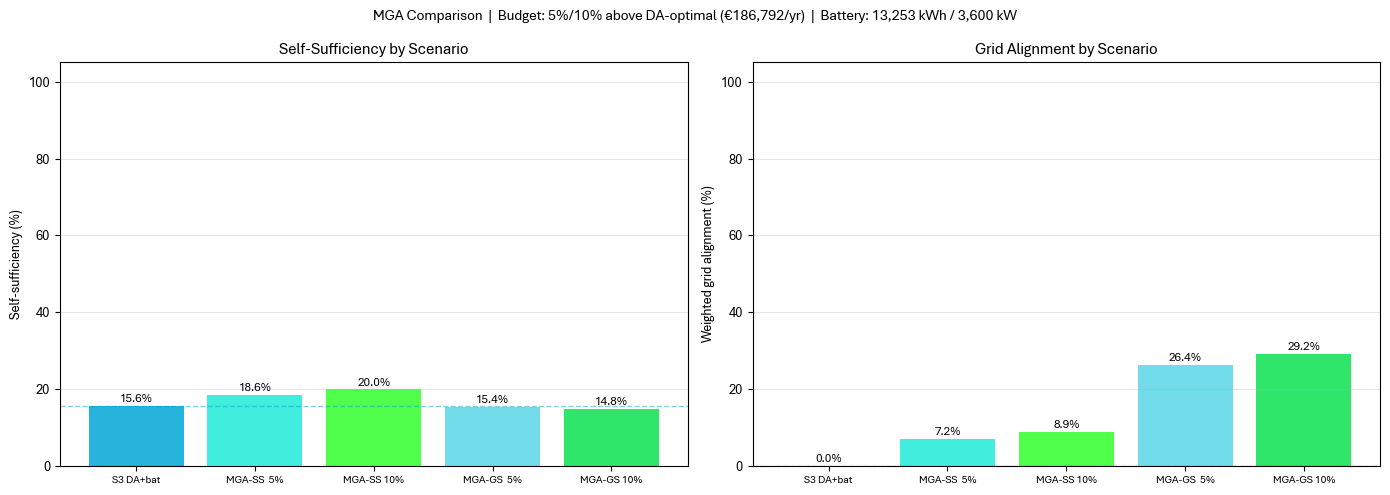

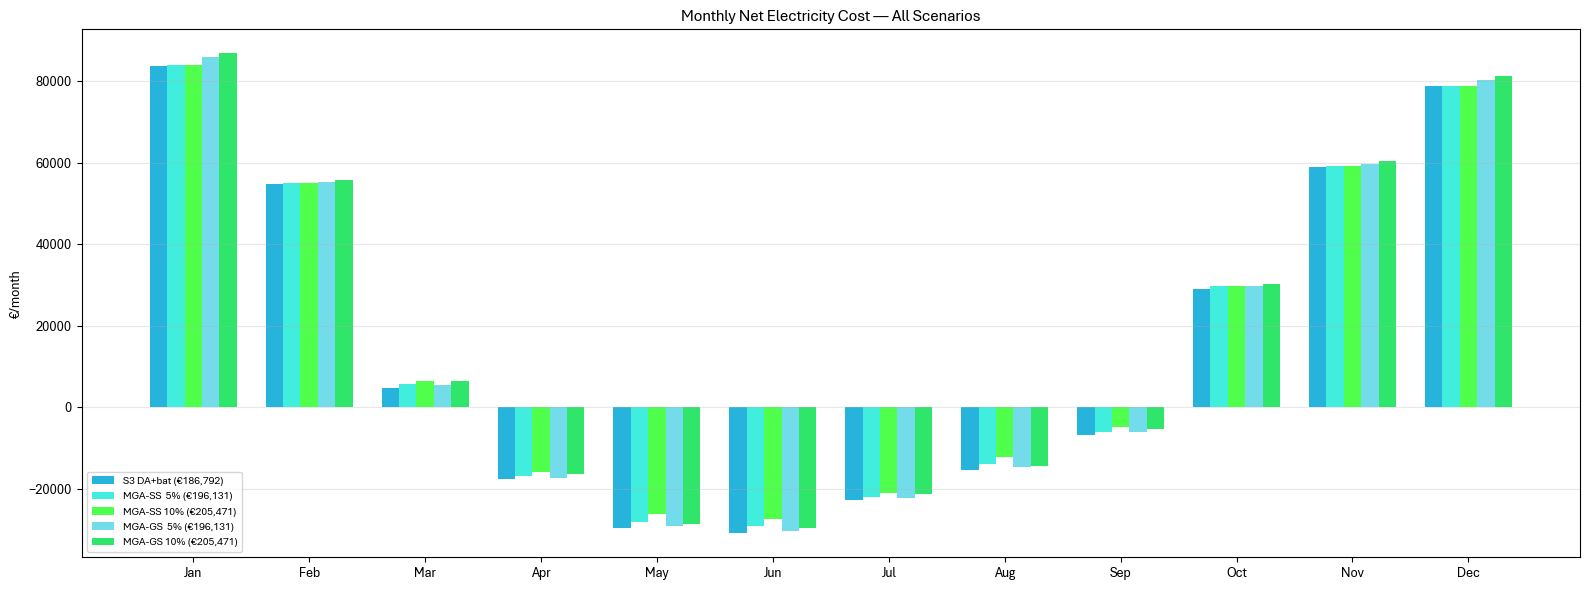

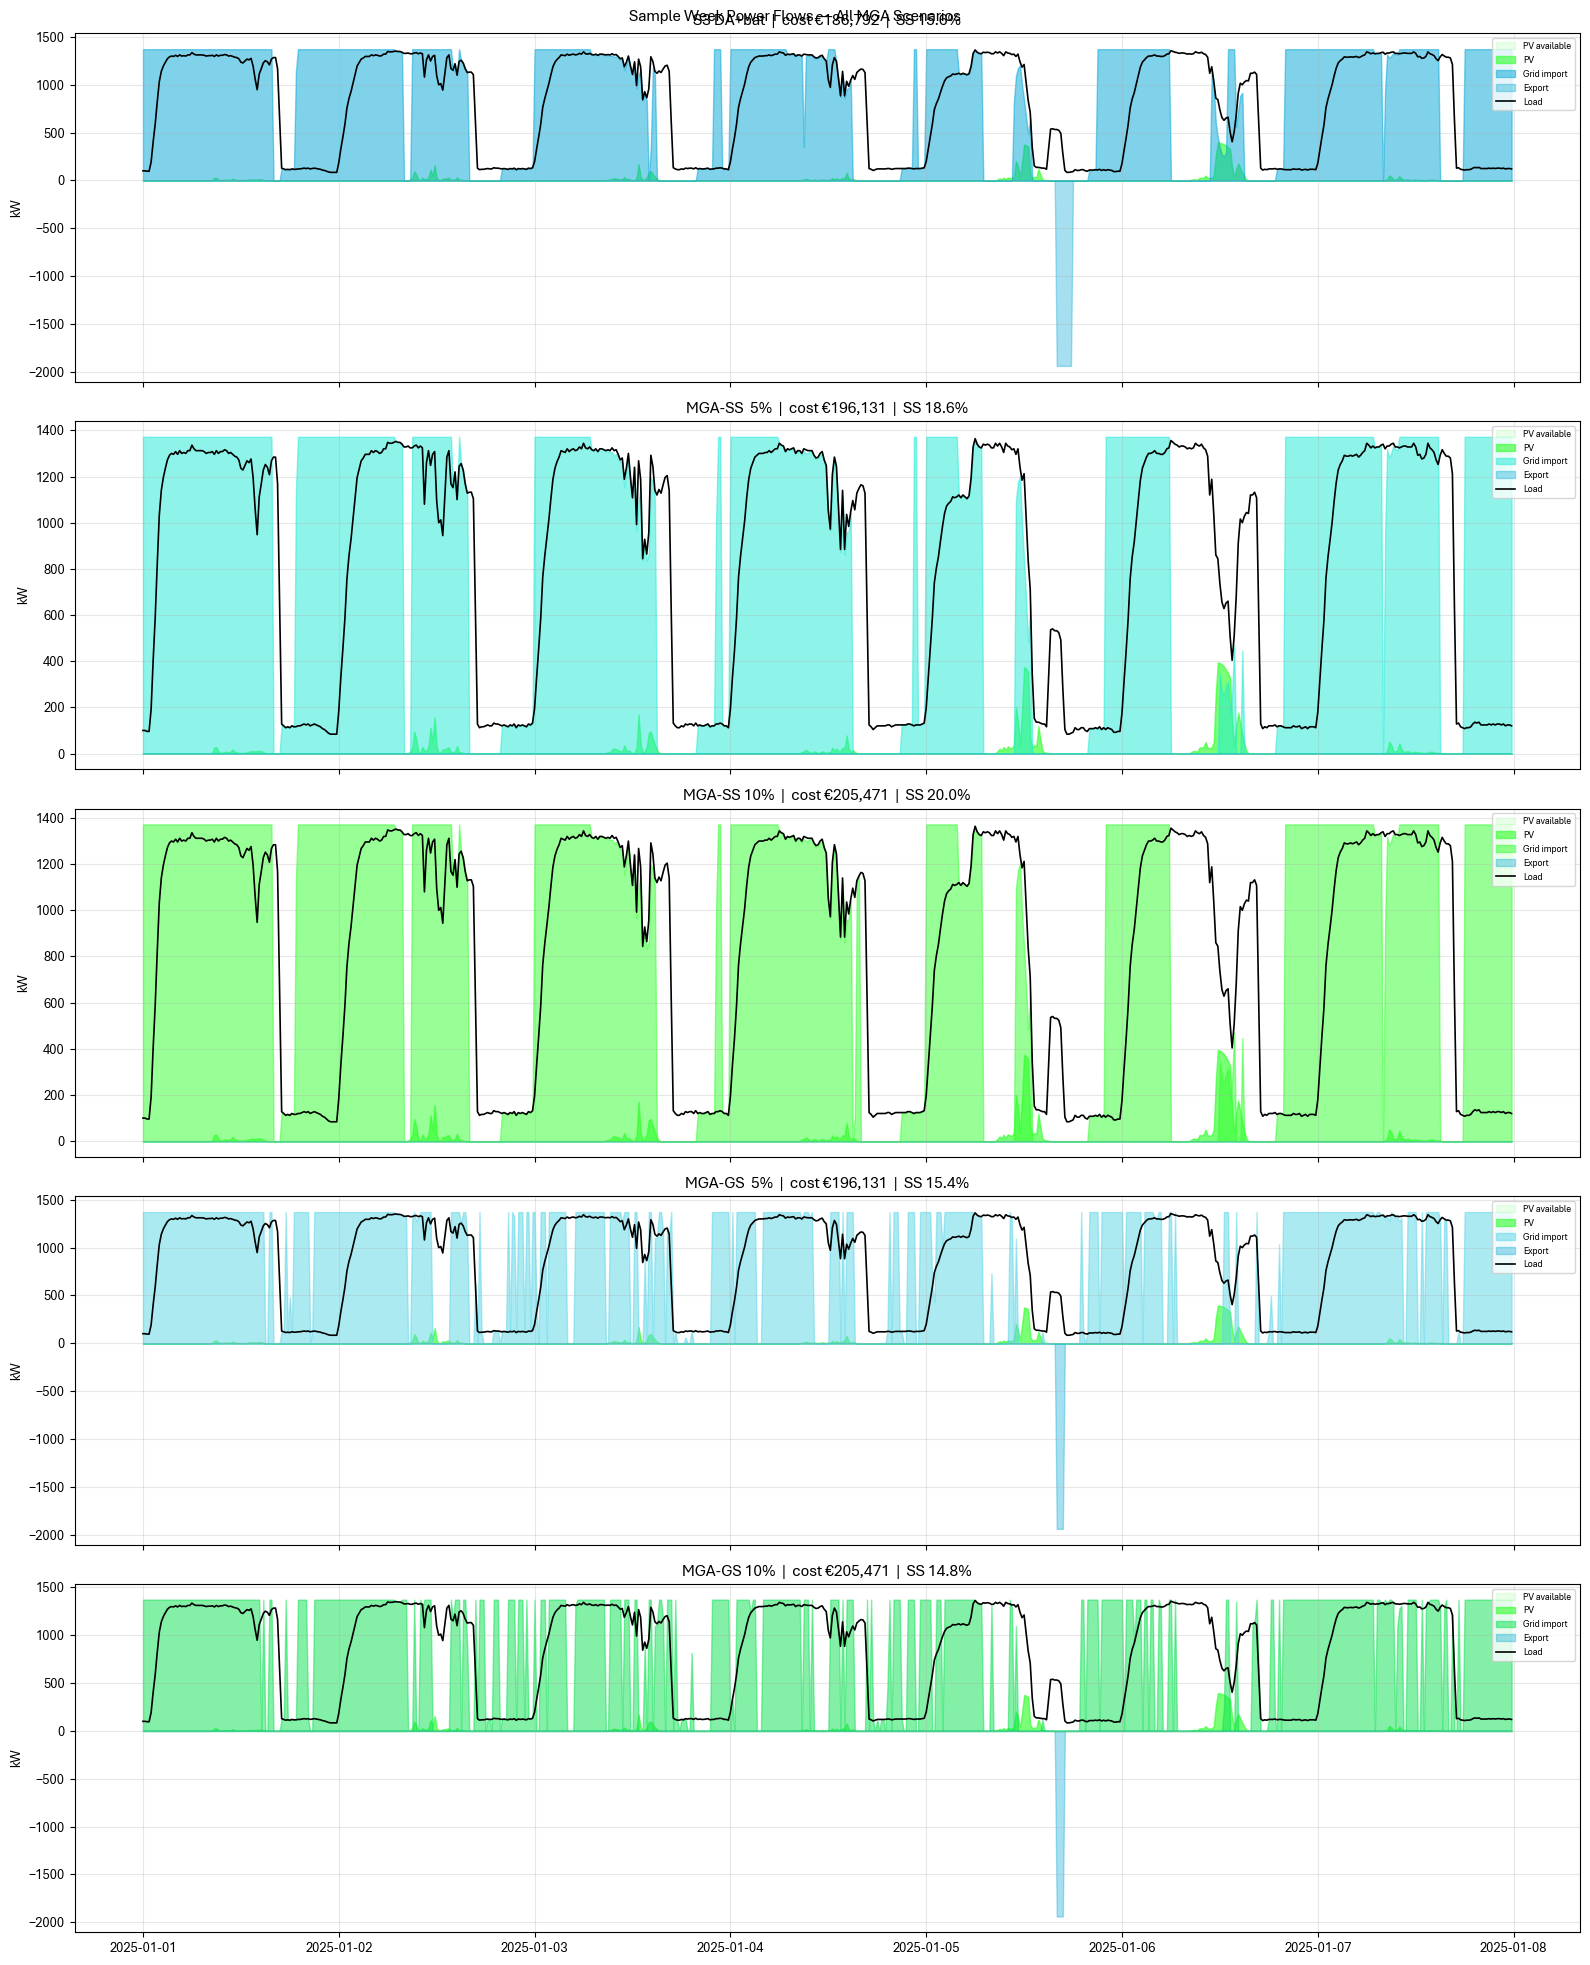

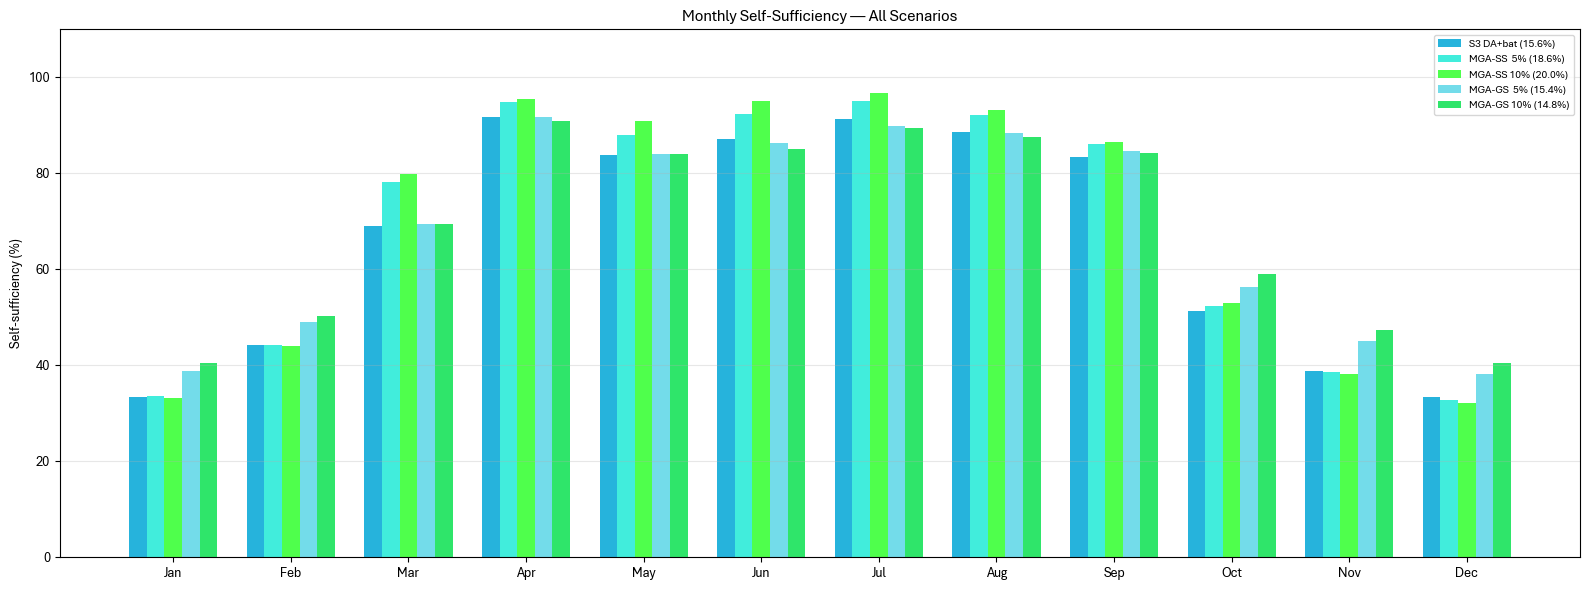

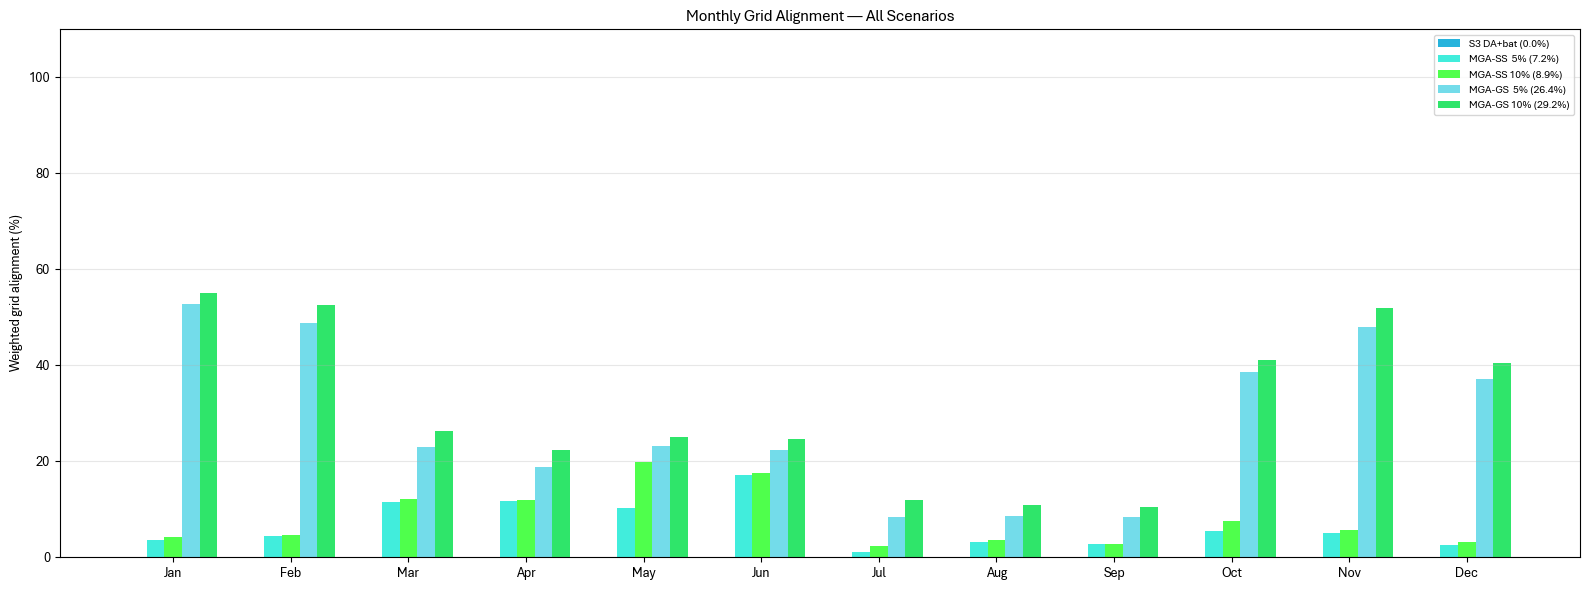

Part III (MGA) complete.
  Scenario          Cost €/yr   vs DA    SS%  Grid align%
  --------------------------------------------------------
  S3 DA+bat           186,792    0.0%  15.6%    0.0%
  MGA-SS  5%          196,131    5.0%  18.6%    7.2%
  MGA-SS 10%          205,471   10.0%  20.0%    8.9%
  MGA-GS  5%          196,131    5.0%  15.4%   26.4%
  MGA-GS 10%          205,471   10.0%  14.8%   29.2%

Battery flows — S3 DA+bat  (MWh)
------------------------------------------------------------
  Month        PV→bat     Grid→bat     Bat→load   Bat→export
------------------------------------------------------------
  Jan             5.9        198.5        176.0         17.6
  Feb            18.8        171.6        170.5          9.6
  Mar           100.8        213.6        149.7        145.4
  Apr           157.5        166.4        110.3        203.2
  May           168.0        207.2         57.5        299.7
  Jun           178.9        192.9         50.5        299.8
  Jul     

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# PART III  —  MODELLING TO GENERATE ALTERNATIVES  (MGA, Electricity-Only)
# ════════════════════════════════════════════════════════════════════════════
# Requires Part I (Cell 1) + Part II (Cell 2) to have run first.
#
# Finds the best achievable Self-Sufficiency (SS) and Grid Support (GS)
# within 5% and 10% cost budget above the DA-optimal baseline.
# Each objective × each budget = 4 MGA runs, all compared against S3 (DA+bat).
#
# Objectives:
#   SS  — maximise self-sufficiency: shift import to PV-peak hours
#   GS  — maximise grid support: align import with grid stress signal
#
# Cost budget = S3 DA+bat cost × (1 + slack)
# ════════════════════════════════════════════════════════════════════════════

import xarray as xr
import logging
logging.getLogger('pypsa').setLevel(logging.WARNING)
logging.getLogger('linopy').setLevel(logging.WARNING)

MGA_SLACK_5  = 0.05   # 5%  cost tolerance above DA-optimal
MGA_SLACK_10 = 0.10   # 10% cost tolerance above DA-optimal

# ── Grid-alignment proxy weight vector (stress-proportional) ────────────────
_gs_max  = grid_stress.abs().max()
_align_w = (grid_stress / _gs_max) if _gs_max > 0 else pd.Series(0.0, index=df.index)


def _scenario_full_cost(res_df):
    """Electricity net cost — MGA budget reference."""
    return _scenario_net_cost(res_df)


def run_mga(objective_name, slack):
    """
    Run one MGA solve.
    objective_name : 'SS' | 'GS'
    slack          : 0.05 or 0.10
    Returns extracted dispatch DataFrame.
    """
    ref_cost = _scenario_full_cost(res2)
    budget   = ref_cost + abs(ref_cost) * slack

    n = _build_elec_dispatch_network(include_battery=True)
    n.optimize.create_model()
    m  = n.model
    sn = n.snapshots

    gen_var  = m.variables["Generator-p"]
    snap_dim = [d for d in gen_var.dims if d.lower() == "snapshot"][0]

    wts   = xr.DataArray(n.snapshot_weightings["generators"].values,
                         dims=[snap_dim], coords={snap_dim: sn})
    imp_p = xr.DataArray(import_price.values, dims=[snap_dim], coords={snap_dim: sn})
    da_p  = xr.DataArray(da_price.values,     dims=[snap_dim], coords={snap_dim: sn})

    try:
        p_imp = gen_var.sel(Generator="grid_import")
        p_exp = gen_var.sel(Generator="grid_export")
    except (KeyError, ValueError):
        _gen_dim = [d for d in gen_var.dims if d.lower() != "snapshot"][0]
        p_imp = gen_var.sel({_gen_dim: "grid_import"})
        p_exp = gen_var.sel({_gen_dim: "grid_export"})

    cost_lhs = (p_imp * imp_p * wts + p_exp * da_p * wts).sum()
    m.add_constraints(cost_lhs <= budget, name="mga_cost_budget")

    if objective_name == "SS":
        m.objective = (p_imp * wts).sum()
    elif objective_name == "GS":
        al_w = xr.DataArray(_align_w.values, dims=[snap_dim], coords={snap_dim: sn})
        m.objective = (p_imp * al_w * wts).sum()

    status, cond = n.optimize.solve_model(solver_name="highs", log_to_console=False)
    if status not in ("ok", "warning"):
        raise RuntimeError(f"MGA-{objective_name}@{slack*100:.0f}% failed: {status} / {cond}")
    return _extract_dispatch(n)


# ── Run all 4 MGA scenarios ──────────────────────────────────────────────────
_s2_ref_cost = _scenario_full_cost(res2)
print(f"MGA reference: S3 DA+bat cost  = €{_s2_ref_cost:,.0f}/yr")
print(f"Battery: {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW")
print()

print("Running MGA-SS  5%  (max self-sufficiency, 5% budget)  ...")
res_mga_ss_5  = run_mga("SS", MGA_SLACK_5);  print("  → OK")

print("Running MGA-SS 10%  (max self-sufficiency, 10% budget) ...")
res_mga_ss_10 = run_mga("SS", MGA_SLACK_10); print("  → OK")

print("Running MGA-GS  5%  (max grid support, 5% budget)  ...")
res_mga_gs_5  = run_mga("GS", MGA_SLACK_5);  print("  → OK")

print("Running MGA-GS 10%  (max grid support, 10% budget) ...")
res_mga_gs_10 = run_mga("GS", MGA_SLACK_10); print("  → OK")
print()


# ════════════════════════════════════════════════════════════════════════════
# POST-PROCESSING
# ════════════════════════════════════════════════════════════════════════════

_mga_results = {
    "S3 DA+bat":   res2,
    "MGA-SS  5%":  res_mga_ss_5,
    "MGA-SS 10%":  res_mga_ss_10,
    "MGA-GS  5%":  res_mga_gs_5,
    "MGA-GS 10%":  res_mga_gs_10,
}

def _mga_stats(res_df, ref_cost):
    cost    = _scenario_net_cost(res_df)
    ss         = _compute_ss(res_df)
    ss_sim     = _compute_ss_simple(res_df)
    sc_sim     = _compute_sc_simple(res_df)
    sc_load    = _compute_sc_load(res_df)
    import_mwh = float((res_df["grid_import"] * DT).sum()) / 1e3
    pnl  = _calc_imb_pnl(res_df["grid_import"], res2["grid_import"]).sum()
    over = (cost - ref_cost) / abs(ref_cost) * 100 if ref_cost != 0 else 0.0
    dev_mwh = float((res_df["grid_import"] - res2["grid_import"]).abs().sum() * DT / 1e3)
    if _has_vol:
        al_w, _ = _calc_alignment_weighted(res_df["grid_import"], res2["grid_import"])
        al_b, _, _ = _calc_alignment(res_df["grid_import"], res2["grid_import"])
    else:
        al_w = al_b = 0.0
    return {"cost": cost, "ss": ss, "ss_sim": ss_sim,
            "sc_sim": sc_sim, "sc_load": sc_load,
            "import_mwh": import_mwh,
            "imb_pnl": pnl, "cost_over_pct": over,
            "al_w": al_w, "al_b": al_b, "dev_mwh": dev_mwh}

_stats = {k: _mga_stats(v, _s2_ref_cost) for k, v in _mga_results.items()}


# ── KPI Summary Table ────────────────────────────────────────────────────────
W = 95
print("=" * W)
print(f"  MGA RESULTS  (all metrics vs S3 DA+bat reference)")
hdr = f"  {'KPI':<40}"
for k in _mga_results: hdr += f" {k:>10}"
print(hdr)
print("=" * W)

def _row(label, key, fmt):
    r = f"  {label:<40}"
    for k in _mga_results:
        r += f" {fmt.format(_stats[k][key]):>10}"
    return r

print(_row("Net elec. cost (€/yr)",          "cost",          "{:,.0f}"))
print(_row("Cost vs S3 DA+bat (%)",           "cost_over_pct", "{:+.1f}%"))
print("-" * W)
print(_row("Self-sufficiency simple (%)",     "ss_sim",        "{:.1f}%"))
print(_row("Self-sufficiency load-only (%)",  "ss",            "{:.1f}%"))
print("-" * W)
print(_row("Self-consumption simple (%)",     "sc_sim",        "{:.1f}%"))
print(_row("Self-consumption load-only (%)",  "sc_load",       "{:.1f}%"))
print("-" * W)
print(_row("Total grid import (MWh/yr)",      "import_mwh",    "{:,.1f}"))
print(_row("Imb. P&L vs S3 DA+bat (€/yr)",   "imb_pnl",       "{:+,.0f}"))
if _has_vol:
    print(_row("Passive align binary top25% (%)","al_b",       "{:.1f}%"))
    print(_row("Passive align weighted (%)",    "al_w",         "{:.1f}%"))
print(_row("Deviation from S3 (MWh/yr)",      "dev_mwh",       "{:.1f}"))
print("=" * W)
print()


# ════════════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════════════

_labels  = list(_mga_results.keys())
_colors  = ["#00A6D6", "#1FEAD6", "#30FF2C", "#5AD6E7", "#0AE150"]
_x_bars  = np.arange(len(_labels))
_x12     = np.arange(12)
_w3      = 0.15

# ── Plot MGA-1: SS and grid alignment bar comparison ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ss_vals = [_stats[k]["ss"] for k in _labels]
bars = ax.bar(_x_bars, ss_vals, color=_colors, alpha=0.85)
ax.axhline(_stats["S3 DA+bat"]["ss"], color="#00A6D6", lw=1, ls="--", alpha=0.5)
for bar, v in zip(bars, ss_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(_x_bars); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("Self-sufficiency (%)"); ax.set_title("Self-Sufficiency by Scenario")
ax.set_ylim(0, 105); ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
if _has_vol:
    al_vals = [_stats[k]["al_w"] for k in _labels]
    bars = ax.bar(_x_bars, al_vals, color=_colors, alpha=0.85)
    ax.axhline(_stats["S3 DA+bat"]["al_w"], color="#00A6D6", lw=1, ls="--", alpha=0.5)
    for bar, v in zip(bars, al_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Weighted grid alignment (%)"); ax.set_title("Grid Alignment by Scenario")
    ax.set_ylim(0, 105)
else:
    cost_vals = [_stats[k]["cost"] for k in _labels]
    bars = ax.bar(_x_bars, cost_vals, color=_colors, alpha=0.85)
    for bar, v in zip(bars, cost_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v*1.01, f"€{v:,.0f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Net electricity cost (€/yr)"); ax.set_title("Net Cost by Scenario")
ax.set_xticks(_x_bars); ax.set_xticklabels(_labels, fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle(
    f"MGA Comparison  |  Budget: 5%/10% above DA-optimal (€{_s2_ref_cost:,.0f}/yr)  |  "
    f"Battery: {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW", fontsize=11)
plt.tight_layout()
plt.savefig("nl_mga_comparison.png", dpi=150)
plt.show()


# ── Plot MGA-2: Monthly cost comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
_offsets = np.linspace(-2*_w3, 2*_w3, len(_labels))
for (label, res_df), offset, color in zip(_mga_results.items(), _offsets, _colors):
    cost_m = (_scenario_net_cost(res_df) and
              _mg(res_df["grid_import"] * import_price * DT) -
              _mg(res_df["grid_export"] * da_price * DT))
    # recalculate properly
    cost_m = (_mg(res_df["grid_import"] * import_price * DT) -
              _mg(res_df["grid_export"] * da_price * DT))
    ax.bar(_x12 + offset, cost_m.values, _w3, label=f"{label} (€{cost_m.sum():,.0f})",
           color=color, alpha=0.85)
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("€/month"); ax.set_title("Monthly Net Electricity Cost — All Scenarios")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_mga_monthly_cost.png", dpi=150)
plt.show()


# ── Plot MGA-3: Sample week dispatch (all 5 scenarios) ────────────────────────
_SAMPLE = slice(0, 7 * 24 * 4)
_x_wk   = res2.index[_SAMPLE]

fig, axes = plt.subplots(len(_mga_results), 1, figsize=(16, 4*len(_mga_results)), sharex=True)
for ax, (label, res_df), color in zip(axes, _mga_results.items(), _colors):
    ax.fill_between(_x_wk, (res_df["pv"]+res_df["pv_curtailed"])[_SAMPLE],
                    alpha=0.1, color="#30FF2C", label="PV available")
    ax.fill_between(_x_wk, res_df["pv"][_SAMPLE],           alpha=0.6, color="#30FF2C",    label="PV")
    ax.fill_between(_x_wk, res_df["grid_import"][_SAMPLE],  alpha=0.5, color=color,     label="Grid import")
    ax.fill_between(_x_wk, -res_df["grid_export"][_SAMPLE], alpha=0.35, color="#00A6D6", label="Export")
    ax.plot(_x_wk, res_df["load"][_SAMPLE], color="black", lw=1.2, label="Load")
    ax.set_ylabel("kW")
    ax.set_title(f"{label}  |  cost €{_stats[label]['cost']:,.0f}  |  SS {_stats[label]['ss']:.1f}%")
    ax.legend(fontsize=7, loc="upper right"); ax.grid(True, alpha=0.3)

plt.suptitle("Sample Week Power Flows — All MGA Scenarios", fontsize=12)
plt.tight_layout()
plt.savefig("nl_mga_week_dispatch.png", dpi=150)
plt.show()


# ── Plot MGA-4: Monthly self-sufficiency ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
_offsets = np.linspace(-2*_w3, 2*_w3, len(_labels))
for (label, res_df), offset, color in zip(_mga_results.items(), _offsets, _colors):
    ss_m = _ss_monthly(res_df)
    ax.bar(_x12 + offset, ss_m.values, _w3, label=f"{label} ({_stats[label]['ss']:.1f}%)",
           color=color, alpha=0.85)
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("Self-sufficiency (%)"); ax.set_title("Monthly Self-Sufficiency — All Scenarios")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("nl_mga_monthly_ss.png", dpi=150)
plt.show()


# ── Plot MGA-5: Grid alignment monthly (if data available) ───────────────────
if _has_vol:
    fig, ax = plt.subplots(figsize=(16, 6))
    _offsets = np.linspace(-2*_w3, 2*_w3, len(_labels))
    for (label, res_df), offset, color in zip(_mga_results.items(), _offsets, _colors):
        _, al_m = _calc_alignment_weighted(res_df["grid_import"], res2["grid_import"])
        ax.bar(_x12 + offset, al_m.values, _w3, label=f"{label} ({_stats[label]['al_w']:.1f}%)",
               color=color, alpha=0.85)
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("Weighted grid alignment (%)")
    ax.set_title("Monthly Grid Alignment — All Scenarios")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.savefig("nl_mga_monthly_alignment.png", dpi=150)
    plt.show()


print("Part III (MGA) complete.")
print(f"  {'Scenario':<14} {'Cost €/yr':>12} {'vs DA':>7} {'SS%':>6}" +
      ("  Grid align%" if _has_vol else ""))
print("  " + "-" * (42 + (14 if _has_vol else 0)))
for k in _labels:
    s = _stats[k]
    row = f"  {k:<14} {s['cost']:>12,.0f} {s['cost_over_pct']:>6.1f}% {s['ss']:>5.1f}%"
    if _has_vol: row += f"  {s['al_w']:>5.1f}%"
    print(row)


# ════════════════════════════════════════════════════════════════════════════
# BATTERY MONTHLY FLOW TABLES  (proportional bus allocation, MWh)
# ════════════════════════════════════════════════════════════════════════════

_bat_scenarios = {**{"S3 DA+bat": res2}, **{k: v for k, v in _mga_results.items() if k != "S3 DA+bat"}}

for _scen_name, _scen_res in _bat_scenarios.items():
    _flows = _bat_monthly_flows(_scen_res)
    _col_w = 12
    _hdr   = f"  {'Month':<6}" + "".join(f" {c:>{_col_w}}" for c in _flows)
    _sep   = "-" * (6 + (1 + _col_w) * len(_flows) + 2)
    print(f"\nBattery flows — {_scen_name}  (MWh)")
    print(_sep)
    print(_hdr)
    print(_sep)
    for _mi in range(1, 13):
        _row_s = f"  {MONTHS[_mi-1]:<6}"
        for _col in _flows:
            _row_s += f" {_flows[_col][_mi]:>{_col_w}.1f}"
        print(_row_s)
    print(_sep)
    _row_s = f"  {'Total':<6}"
    for _col in _flows:
        _row_s += f" {_flows[_col].sum():>{_col_w}.1f}"
    print(_row_s)
    print(_sep)


Re-dispatching: fixed battery size, PV=0 ...


Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 58.26it/s]


  Battery-only dispatch cost : €339,489/yr
  S1 (no-system) cost        : €506,932/yr

  SCENARIO BASELINE COMPARISON  (15-min dispatch, fixed capacities)
  Scenario                             Elec cost (€/yr)  vs S1 (€/yr)
--------------------------------------------------------------------------
  S1 — No PV, no battery                        506,932             —
  S2 — PV only                                  420,083        86,849
  Battery only (fixed size, no PV)              339,489       167,444
  S3 — PV + battery (DA-optimal)                186,792       320,141

  SYNERGY ANALYSIS  — PV and battery combined vs individual
  PV standalone saving (S1 → S2)                   86,849 €/yr
  Battery standalone saving (S1 → bat-only)       167,444 €/yr
  Sum of standalone savings                       254,293 €/yr
  Combined saving (S1 → S3)                       320,141 €/yr
  Synergy (combined − sum of parts)                65,848 €/yr
--------------------------------------------

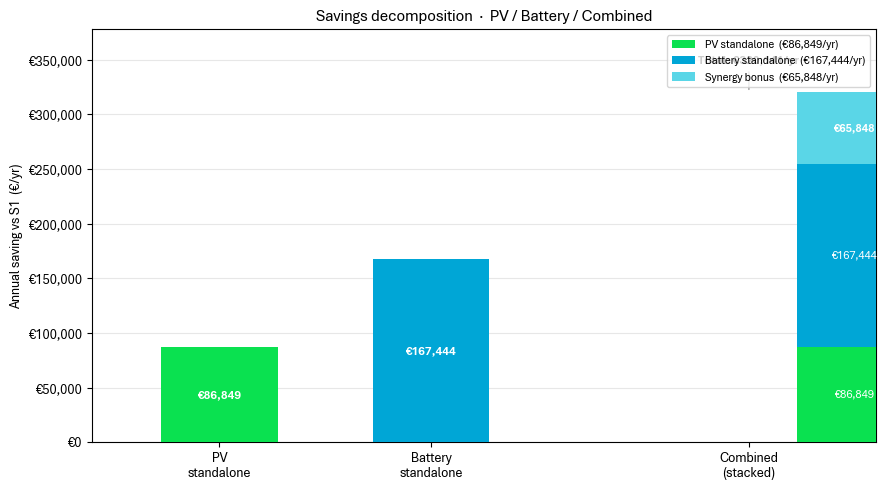


  CAPEX & PAYBACK SUMMARY  (simple payback, no discounting)
  Metric                                           PV       Battery        System
  Gross CAPEX (€)                           3,393,000     1,815,263     5,208,263
  -------------------------------------- ------------  ------------  ------------
    Standalone analysis                 
  Standalone saving vs S1 (€/yr)               86,849       167,444       320,141
    of which: synergy (€/yr)                        —             —        65,848
  Fixed O&M (€/yr)                             22,620        29,160        51,780
  Net saving standalone (€/yr)                 64,229       138,284       202,513
  Simple payback standalone (yr)                 52.8          13.1          25.7
  -------------------------------------- ------------  ------------  ------------
    Shapley analysis (equal synergy split)
  Synergy allocated (€/yr)                     32,924        32,924        65,848
  Shapley saving (€/yr)            

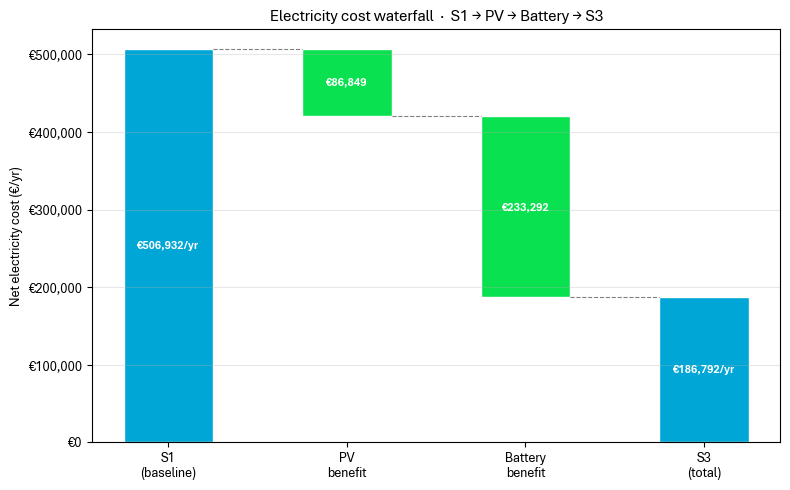


  MGA ECONOMIC ANALYSIS
  Total system net CAPEX : €5,208,263
  Total system O&M       : €51,780/yr
  Reference payback (S3) : 25.7 yr  (S3 dispatch, simple)

  a. Does imbalance P&L offset the extra electricity cost vs S3?
     (P&L is incremental vs S3 import schedule; positive = MGA earns more)

  Scenario          Extra elec. cost   Imb. P&L (incr.)  Net extra cost   P&L covers
--------------------------------------------------------------------------------------------
  S3 DA+bat                        0                  0               0          ref
  MGA-SS  5%                   9,340             26,507         -17,167         284%
  MGA-SS 10%                  18,679             28,786         -10,107         154%
  MGA-GS  5%                   9,340             62,986         -53,646         674%
  MGA-GS 10%                  18,679             66,973         -48,294         359%

  b. System payback given MGA dispatch
     Saving vs S1 = S1 electricity cost − (MGA electrici

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# PART IV  —  ECONOMICS ANALYSIS  (15-min dispatch, fixed capacities)
#
# Requires Cells 0–3 to have run first.
# All electricity costs use 15-min dispatch (Cell 3) with the battery and
# PV sizes fixed by the Cell 2 investment LP.
# ════════════════════════════════════════════════════════════════════════════

# ── PV CAPEX assumptions (not defined in Cell 0 for elec-only) ───────────
PV_CAPEX_EUR_KWP = 1_800    # €/kWp installed (turnkey incl. mounting & inverter)
PV_OM_EUR_KW_YR  =    12.0  # €/kWp/yr fixed O&M
PV_LIFETIME_YR   =    25    # years

# ── 1 & 2. Component CAPEX ───────────────────────────────────────────────
_PV_KWP_STC   = PV_MODULES * MODULE_WP / 1000  # nameplate STC capacity
pv_capex_eur  = _PV_KWP_STC * PV_CAPEX_EUR_KWP
pv_om_yr      = _PV_KWP_STC * PV_OM_EUR_KW_YR

bat_capex_eur = gross_capex(bat_e_kwh, bat_p_kw)   # full gross CAPEX (benchmark + expansion)
bat_net_capex = net_capex(bat_e_kwh, bat_p_kw)     # after subsidy (= gross if subsidy=0)
bat_om_yr     = bat_fix_eur                         # annual_om(bat_p_kw), €/yr

# ── Scenario electricity costs from Cell 2 dispatch ─────────────────────
# s1_net_cost : no PV, no battery  (true baseline)
# s2_net_cost : PV only, no battery
# s3_net_cost : PV + battery, DA-optimal dispatch

pv_saving_yr       = s1_net_cost - s2_net_cost   # PV standalone saving vs no-system
bat_marginal_yr    = s2_net_cost - s3_net_cost   # battery marginal saving given PV
combined_saving_yr = s1_net_cost - s3_net_cost   # total combined saving

# ── 7. True marginal PV value — re-dispatch with battery only (PV = 0) ──
print("Re-dispatching: fixed battery size, PV=0 ...")
_n_batonly = _build_elec_dispatch_network(include_battery=True, include_pv=False)
_st_bo, _ = _n_batonly.optimize(solver_name="highs", log_to_console=False)
if _st_bo not in ("ok", "warning"):
    print(f"  WARNING: bat-only solve failed ({_st_bo}); setting cost_batonly = NaN")
    cost_batonly = float("nan")
else:
    cost_batonly = _scenario_net_cost(_extract_dispatch(_n_batonly))
print(f"  Battery-only dispatch cost : \u20ac{cost_batonly:,.0f}/yr")
print(f"  S1 (no-system) cost        : \u20ac{s1_net_cost:,.0f}/yr")

import math
_bo_ok = not math.isnan(cost_batonly)
bat_standalone_yr    = (s1_net_cost - cost_batonly) if _bo_ok else float("nan")
pv_marginal_given_bat = (cost_batonly - s3_net_cost) if _bo_ok else float("nan")
synergy_yr = (combined_saving_yr - pv_saving_yr - bat_standalone_yr) if _bo_ok else float("nan")

_na = lambda x: f"{x:,.0f}" if not math.isnan(x) else "n/a"
_pb = lambda x: f"{x:.1f}" if (not math.isnan(x) and x < 999) else ("\u221e" if not math.isnan(x) else "n/a")

# ── Print 1: Baseline comparison ────────────────────────────────────────
W = 74
print()
print("=" * W)
print("  SCENARIO BASELINE COMPARISON  (15-min dispatch, fixed capacities)")
print("=" * W)
print(f"  {'Scenario':<36} {'Elec cost (\u20ac/yr)':>16}  {'vs S1 (\u20ac/yr)':>12}")
print("-" * W)
print(f"  {'S1 — No PV, no battery':<36} {s1_net_cost:>16,.0f}  {'—':>12}")
print(f"  {'S2 — PV only':<36} {s2_net_cost:>16,.0f}  {pv_saving_yr:>12,.0f}")
print(f"  {'Battery only (fixed size, no PV)':<36} {_na(cost_batonly):>16}  {_na(bat_standalone_yr):>12}")
print(f"  {'S3 — PV + battery (DA-optimal)':<36} {s3_net_cost:>16,.0f}  {combined_saving_yr:>12,.0f}")
print("=" * W)

# ── Print 2: Synergy ────────────────────────────────────────────────────
print()
print("=" * W)
print("  SYNERGY ANALYSIS  — PV and battery combined vs individual")
print("=" * W)
print(f"  {'PV standalone saving (S1 \u2192 S2)':<42} {pv_saving_yr:>12,.0f} \u20ac/yr")
print(f"  {'Battery standalone saving (S1 \u2192 bat-only)':<42} {_na(bat_standalone_yr):>12} \u20ac/yr")
_sum_standalone = (pv_saving_yr + bat_standalone_yr) if _bo_ok else float("nan")
print(f"  {'Sum of standalone savings':<42} {_na(_sum_standalone):>12} \u20ac/yr")
print(f"  {'Combined saving (S1 \u2192 S3)':<42} {combined_saving_yr:>12,.0f} \u20ac/yr")
print(f"  {'Synergy (combined \u2212 sum of parts)':<42} {_na(synergy_yr):>12} \u20ac/yr")
print("-" * W)
print(f"  {'PV marginal value given battery (bat-only \u2192 S3)':<42} {_na(pv_marginal_given_bat):>12} \u20ac/yr")
print(f"  {'PV standalone saving (for comparison)':<42} {pv_saving_yr:>12,.0f} \u20ac/yr")
print("=" * W)

# ── Synergy breakdown bar chart ──────────────────────────────────────────
if _bo_ok and not (math.isnan(synergy_yr) or math.isnan(bat_standalone_yr)):
    fig_syn, ax_syn = plt.subplots(figsize=(9, 5))

    _x      = [0, 1, 2.5]
    _labels = ["PV\nstandalone", "Battery\nstandalone", "Combined\n(stacked)"]

    # Standalone bars
    ax_syn.bar(0, pv_saving_yr,     color="#0AE150", width=0.55, zorder=3)
    ax_syn.bar(1, bat_standalone_yr, color="#00A6D6", width=0.55, zorder=3)

    # Combined: stacked PV + Battery + Synergy
    _bot_bat = pv_saving_yr
    _bot_syn = pv_saving_yr + bat_standalone_yr
    ax_syn.bar(3, pv_saving_yr,     color="#0AE150", width=0.55, zorder=3,
               label=f"PV standalone  (€{pv_saving_yr:,.0f}/yr)")
    ax_syn.bar(3, bat_standalone_yr, bottom=_bot_bat, color="#00A6D6", width=0.55, zorder=3,
               label=f"Battery standalone  (€{bat_standalone_yr:,.0f}/yr)")
    ax_syn.bar(3, synergy_yr,        bottom=_bot_syn, color="#5AD6E7", width=0.55, zorder=3,
               label=f"Synergy bonus  (€{synergy_yr:,.0f}/yr)")

    # Value labels
    for xp, val in [(0, pv_saving_yr), (1, bat_standalone_yr)]:
        ax_syn.text(xp, val / 2, f"€{val:,.0f}", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold", zorder=4)
    ax_syn.text(3, pv_saving_yr / 2, f"€{pv_saving_yr:,.0f}",
                ha="center", va="center", fontsize=8.5, color="white", zorder=4)
    ax_syn.text(3, _bot_bat + bat_standalone_yr / 2, f"€{bat_standalone_yr:,.0f}",
                ha="center", va="center", fontsize=8.5, color="white", zorder=4)
    ax_syn.text(3, _bot_syn + synergy_yr / 2, f"€{synergy_yr:,.0f}",
                ha="center", va="center", fontsize=8.5, color="white", fontweight="bold", zorder=4)

    # Total annotation on combined bar
    ax_syn.annotate(f"Total: €{combined_saving_yr:,.0f}/yr",
                    xy=(2.5, combined_saving_yr), xytext=(2.5, combined_saving_yr * 1.08),
                    ha="center", fontsize=9, fontweight="bold",
                    arrowprops=dict(arrowstyle="-", color="grey", lw=0.8))

    ax_syn.set_xticks([0, 1, 2.5])
    ax_syn.set_xticklabels(_labels)
    ax_syn.set_ylabel("Annual saving vs S1  (€/yr)")
    ax_syn.set_title("Savings decomposition  ·  PV / Battery / Combined")
    ax_syn.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
    ax_syn.legend(loc="upper right", fontsize=8.5)
    ax_syn.grid(axis="y", alpha=0.3, zorder=0)
    ax_syn.set_xlim(-0.6, 3.1)
    ax_syn.set_ylim(0, combined_saving_yr * 1.18)
    plt.tight_layout()
    plt.savefig("nl_synergy_bar.png", dpi=150)
    plt.show()
# ── Print 3: CAPEX & Payback ────────────────────────────────────────────
# Standalone (symmetric — no synergy attribution)
pv_net_yr   = pv_saving_yr   - pv_om_yr
bat_net_yr  = (bat_standalone_yr - bat_om_yr) if _bo_ok else float("nan")
sys_net_yr  = ((pv_saving_yr + bat_standalone_yr - pv_om_yr - bat_om_yr)
               if _bo_ok else combined_saving_yr - pv_om_yr - bat_om_yr)

pv_payback  = pv_capex_eur  / pv_net_yr  if pv_net_yr  > 0 else float("inf")
bat_payback = bat_net_capex / bat_net_yr if bat_net_yr > 0 else float("inf")
sys_payback = (pv_capex_eur + bat_net_capex) / sys_net_yr if sys_net_yr > 0 else float("inf")

# Shapley (equal synergy split) - each component gets standalone + half the interaction gain
_syn_half      = synergy_yr / 2
pv_syn_yr      = pv_saving_yr       + _syn_half
bat_syn_yr     = (bat_standalone_yr + _syn_half) if _bo_ok else float("nan")
sys_syn_yr     = combined_saving_yr  # unchanged; PV + bat Shapley always sums to combined

pv_syn_net_yr  = pv_syn_yr  - pv_om_yr
bat_syn_net_yr = (bat_syn_yr - bat_om_yr) if _bo_ok else float("nan")
sys_syn_net_yr = sys_syn_yr - pv_om_yr - bat_om_yr

pv_syn_payback  = pv_capex_eur  / pv_syn_net_yr  if pv_syn_net_yr  > 0 else float("inf")
bat_syn_payback = (bat_net_capex / bat_syn_net_yr
                   if _bo_ok and bat_syn_net_yr > 0 else float("inf"))
sys_syn_payback = ((pv_capex_eur + bat_net_capex) / sys_syn_net_yr
                   if sys_syn_net_yr > 0 else float("inf"))

W3 = 82
_sep = f"  {'-'*38} {'-'*12}  {'-'*12}  {'-'*12}"
print()
print("=" * W3)
print("  CAPEX & PAYBACK SUMMARY  (simple payback, no discounting)")
print(f"  {'Metric':<38} {'PV':>12}  {'Battery':>12}  {'System':>12}")
print("=" * W3)
print(f"  {'Gross CAPEX (\u20ac)':<38} {pv_capex_eur:>12,.0f}  {bat_capex_eur:>12,.0f}  {pv_capex_eur+bat_capex_eur:>12,.0f}")
if BATTERY_SUBSIDY_FRAC > 0:
    print(f"  {'Net CAPEX after subsidy (\u20ac)':<38} {pv_capex_eur:>12,.0f}  {bat_net_capex:>12,.0f}  {pv_capex_eur+bat_net_capex:>12,.0f}")
print(_sep)
print(f"  {'  Standalone analysis':<38}")
print(f"  {'Standalone saving vs S1 (\u20ac/yr)':<38} {pv_saving_yr:>12,.0f}  {_na(bat_standalone_yr):>12}  {combined_saving_yr:>12,.0f}")
print(f"  {'  of which: synergy (\u20ac/yr)':<38} {'\u2014':>12}  {'\u2014':>12}  {synergy_yr:>12,.0f}")
print(f"  {'Fixed O&M (\u20ac/yr)':<38} {pv_om_yr:>12,.0f}  {bat_om_yr:>12,.0f}  {pv_om_yr+bat_om_yr:>12,.0f}")
print(f"  {'Net saving standalone (\u20ac/yr)':<38} {pv_net_yr:>12,.0f}  {_na(bat_net_yr):>12}  {sys_net_yr:>12,.0f}")
print(f"  {'Simple payback standalone (yr)':<38} {_pb(pv_payback):>12}  {_pb(bat_payback):>12}  {_pb(sys_payback):>12}")
print(_sep)
print(f"  {'  Shapley analysis (equal synergy split)':<38}")
print(f"  {'Synergy allocated (\u20ac/yr)':<38} {_syn_half:>12,.0f}  {_syn_half:>12,.0f}  {synergy_yr:>12,.0f}")
print(f"  {'Shapley saving (\u20ac/yr)':<38} {pv_syn_yr:>12,.0f}  {_na(bat_syn_yr):>12}  {sys_syn_yr:>12,.0f}")
print(f"  {'Net saving Shapley (\u20ac/yr)':<38} {pv_syn_net_yr:>12,.0f}  {_na(bat_syn_net_yr):>12}  {sys_syn_net_yr:>12,.0f}")
print(f"  {'Shapley payback (yr)':<38} {_pb(pv_syn_payback):>12}  {_pb(bat_syn_payback):>12}  {_pb(sys_syn_payback):>12}")
print(_sep)
print(f"  {'Design life (yr)':<38} {PV_LIFETIME_YR:>12.0f}  {BATTERY_LIFE_YR:>12.0f}")
print("=" * W3)
# ── 5. Waterfall chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
_wlabels  = ["S1\n(baseline)", "PV\nbenefit", "Battery\nbenefit", "S3\n(total)"]
_wheights = [s1_net_cost, pv_saving_yr, bat_marginal_yr, s3_net_cost]
_wbottoms = [0, s2_net_cost, s3_net_cost, 0]
_wcolors  = ["#00A6D6", "#0AE150", "#0AE150", "#00A6D6"]

ax.bar(_wlabels, _wheights, bottom=_wbottoms,
       color=_wcolors, edgecolor="white", width=0.5)

# Connector dashed lines (right edge of bar i → left edge of bar i+1)
_conn_y = [s1_net_cost, s2_net_cost, s3_net_cost]
for i, y in enumerate(_conn_y):
    ax.plot([i + 0.25, i + 0.75], [y, y], "k--", lw=0.8, alpha=0.5)

# Labels inside bars
for i, (h, b) in enumerate(zip(_wheights, _wbottoms)):
    mid = b + h / 2
    if i in (1, 2):
        txt = f"\u20ac{h:,.0f}"
    else:
        txt = f"\u20ac{b+h:,.0f}/yr"
    ax.text(i, mid, txt, ha="center", va="center",
            fontsize=8.5, color="white", fontweight="bold")

ax.set_ylabel("Net electricity cost (\u20ac/yr)")
ax.set_title("Electricity cost waterfall  \u00b7  S1 \u2192 PV \u2192 Battery \u2192 S3")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"\u20ac{x:,.0f}"))
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── MGA Economic Analysis ────────────────────────────────────────────────
# _stats[k]: {cost, ss, imb_pnl, cost_over_pct, al_w, al_b, dev_mwh}
# imb_pnl = incremental imbalance P&L vs S3 declared schedule

total_capex_net = pv_capex_eur + bat_net_capex
total_om_yr     = pv_om_yr + bat_om_yr

WA = 92
print()
print("=" * WA)
print("  MGA ECONOMIC ANALYSIS")
print(f"  Total system net CAPEX : \u20ac{total_capex_net:,.0f}")
print(f"  Total system O&M       : \u20ac{total_om_yr:,.0f}/yr")
print(f"  Reference payback (S3) : {_pb(sys_payback)} yr  (S3 dispatch, simple)")
print("=" * WA)

print()
print("  a. Does imbalance P&L offset the extra electricity cost vs S3?")
print(f"     (P&L is incremental vs S3 import schedule; positive = MGA earns more)")
print()
print("=" * WA)
print(f"  {'Scenario':<16} {'Extra elec. cost':>17} {'Imb. P&L (incr.)':>18} {'Net extra cost':>15} {'P&L covers':>12}")
print("-" * WA)
for k, st in _stats.items():
    extra = st["cost"] - s3_net_cost
    pnl   = st["imb_pnl"]
    net   = extra - pnl
    if abs(extra) < 1:
        cov = "ref"
    elif extra > 0:
        cov = f"{pnl/extra*100:.0f}%"
    else:
        cov = "n/a"
    print(f"  {k:<16} {extra:>17,.0f} {pnl:>18,.0f} {net:>15,.0f} {cov:>12}")
print("=" * WA)

print()
print("  b. System payback given MGA dispatch")
print(f"     Saving vs S1 = S1 electricity cost − (MGA electricity cost − incremental P&L)")
print()
print("=" * WA)
print(f"  {'Scenario':<16} {'Sys saving vs S1':>17} {'After O&M':>12} {'Payback (yr)':>14} {'\u0394 vs S3 (yr)':>12}")
print("-" * WA)
for k, st in _stats.items():
    mga_net_opex     = st["cost"] - st["imb_pnl"]  # effective opex after P&L
    mga_saving_vs_s1 = s1_net_cost - mga_net_opex
    mga_after_om     = mga_saving_vs_s1 - total_om_yr
    pb = total_capex_net / mga_after_om if mga_after_om > 0 else float("inf")
    delta = pb - sys_payback if (sys_payback < 999 and pb < 999) else float("nan")
    pb_str    = _pb(pb)
    delta_str = f"{delta:+.1f}" if not math.isnan(delta) else "\u2014"
    print(f"  {k:<16} {mga_saving_vs_s1:>17,.0f} {mga_after_om:>12,.0f} {pb_str:>14} {delta_str:>12}")
print("=" * WA)
print()

In [7]:
# ─── Electrical-Only PV & BESS Economics ────────────────────────────────────
# All savings/paybacks drawn from the economics cell above.
# Battery standalone: direct LP re-solve (battery only, fixed size) — exact.
# Synergy = S(PV,Bat) − S(PV) − S(Battery); equal Shapley split (50/50).
# Paybacks use bat_net_capex (after subsidy); gross CAPEX shown for reference.
# ─────────────────────────────────────────────────────────────────────────────
import math as _math

_W, _CW = 74, 14
_sys_g = pv_capex_eur + bat_capex_eur   # gross system CAPEX
_sys_n = pv_capex_eur + bat_net_capex   # net system CAPEX (for payback)

def _pf(v, w=_CW):
    if v is None:                               return ' ' * w
    if isinstance(v, float) and _math.isnan(v): return 'N/A'.rjust(w)
    if v == float('inf'):                       return '\u221e'.rjust(w)
    return f'{v:>{w},.0f}'
def _yf(v, w=_CW):
    if isinstance(v, float) and _math.isnan(v): return 'N/A'.rjust(w)
    if v == float('inf'):                        return '\u221e'.rjust(w)
    return f'{v:>{w-3}.1f} yr'
def _pr(label, a, b, c, ff=_pf):
    print(f"  {label:<40} {ff(a)} {ff(b)} {ff(c)}")
def _pb(capex, sav):
    if isinstance(sav, float) and _math.isnan(sav): return float('nan')
    return capex / sav if sav > 1 else float('inf')

print()
print('\u2550' * _W)
print(f"  ELECTRICAL-ONLY ECONOMICS \u2014 PV & BESS")
print('\u2550' * _W)
print(f"  {'Metric':<40} {'PV':>{_CW}} {'Battery':>{_CW}} {'PV+BESS':>{_CW}}")
print('\u2500' * _W)
_pr("Gross CAPEX (\u20ac)",              pv_capex_eur,  bat_capex_eur, _sys_g)
if bat_net_capex != bat_capex_eur:
    _pr("Net CAPEX after subsidy (\u20ac)", pv_capex_eur, bat_net_capex, _sys_n)
print('\u2500' * _W)
print(f"  Standalone analysis  (each technology valued independently vs S1)")
print('\u2500' * _W)
_pr("Standalone saving vs S1 (\u20ac/yr)", pv_saving_yr, bat_standalone_yr, combined_saving_yr)
print(f"  {'  of which: synergy (\u20ac/yr)':<40} {'\u2014':>{_CW}} {'\u2014':>{_CW}} {_pf(synergy_yr)}")
_pr("Fixed O&M (\u20ac/yr)",             pv_om_yr,      bat_om_yr,     pv_om_yr + bat_om_yr)
_pr("Net saving standalone (\u20ac/yr)", pv_net_yr,     bat_net_yr,    sys_net_yr)
_pr("Simple payback standalone",
    _pb(pv_capex_eur,  pv_net_yr),
    _pb(bat_net_capex, bat_net_yr),
    _pb(_sys_n,        sys_net_yr), ff=_yf)
print('\u2500' * _W)
print(f"  Synergy analysis (equal split \u2014 each technology receives \u00bd synergy)")
print('\u2500' * _W)
_pr("Synergy allocated (\u20ac/yr)",     _syn_half,     _syn_half,     synergy_yr)
_pv_incl  = pv_saving_yr + _syn_half
_bat_incl = bat_standalone_yr + _syn_half if _bo_ok else float('nan')
_pr("Saving incl. synergy (\u20ac/yr)",  _pv_incl, _bat_incl, combined_saving_yr)
_pr("Net saving incl. synergy & O&M",    pv_syn_net_yr, bat_syn_net_yr, sys_syn_net_yr)
_pr("Synergy payback",
    pv_syn_payback, bat_syn_payback, sys_syn_payback, ff=_yf)
print('\u2500' * _W)
print(f"  {'Design life':<40} {f'{PV_LIFETIME_YR:.0f} yr':>{_CW}} {f'{BATTERY_LIFE_YR:.0f} yr':>{_CW}} {'\u2014':>{_CW}}")
print('\u2550' * _W)
if _bo_ok:
    print(f"  Synergy = S(PV,Bat) \u2212 S(PV) \u2212 S(Battery)")
    print(f"          = \u20ac{combined_saving_yr:,.0f}/yr \u2212 \u20ac{pv_saving_yr:,.0f}/yr \u2212 \u20ac{bat_standalone_yr:,.0f}/yr = \u20ac{synergy_yr:,.0f}/yr")
print(f"  Battery standalone: direct LP re-solve (battery only, no PV, fixed size)")
print('\u2550' * _W)



══════════════════════════════════════════════════════════════════════════
  ELECTRICAL-ONLY ECONOMICS — PV & BESS
══════════════════════════════════════════════════════════════════════════
  Metric                                               PV        Battery        PV+BESS
──────────────────────────────────────────────────────────────────────────
  Gross CAPEX (€)                               3,393,000      1,815,263      5,208,263
──────────────────────────────────────────────────────────────────────────
  Standalone analysis  (each technology valued independently vs S1)
──────────────────────────────────────────────────────────────────────────
  Standalone saving vs S1 (€/yr)                   86,849        167,444        320,141
    of which: synergy (€/yr)                            —              —         65,848
  Fixed O&M (€/yr)                                 22,620         29,160         51,780
  Net saving standalone (€/yr)                     64,229        138,284    

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — Grid Import Capacity  [NL_elec_only]
# -10% (1234.8 kW)  -5% (1303.4 kW)  Base (1372.0 kW — pre-computed)
# +5% (1440.6 kW)  +10% (1509.2 kW)
# Base row uses existing Cell 1 results — no re-solve.
# Non-base scenarios re-optimise Scenario B (PyPSA / HiGHS).
# Delta cost = net electricity cost vs 1372 kW baseline (positive = costlier).
# Requires prior cells executed for grid_stress (alignment) and ss_opt (SS).
# ═══════════════════════════════════════════════════════════════════════════════

import time as _time

_SOLVER_THREADS = 4        # adjust to available CPU cores
_GRID_BASE_KW   = 1372.0
_GRID_SCENS = [
    ("-10%  (1234.8 kW)", round(_GRID_BASE_KW * 0.90, 1)),
    (" -5%  (1303.4 kW)", round(_GRID_BASE_KW * 0.95, 1)),
    (" +5%  (1440.6 kW)", round(_GRID_BASE_KW * 1.05, 1)),
    ("+10%  (1509.2 kW)", round(_GRID_BASE_KW * 1.10, 1)),
]

# ── save originals ─────────────────────────────────────────────────────────────
_gsv = dict(
    GRID_IMPORT_MAX_KW=GRID_IMPORT_MAX_KW, _P_IMPORT_ELEC=_P_IMPORT_ELEC,
    n_elec=n_elec, bat_e_kwh=bat_e_kwh, bat_p_kw=bat_p_kw,
)
_grid_base_net_cost = net_elec_cost   # 1372 kW from Cell 1

# ── base row from existing results (no re-solve) ───────────────────────────────
try:
    _base_al = round(wal3 * 100, 1)
except NameError:
    _base_al = float("nan")

_grid_rows = [{
    "Scenario":               "Base  (1372.0 kW)",
    "Grid cap (kW)":          _GRID_BASE_KW,
    "BESS energy (kWh)":      round(bat_e_kwh, 0),
    "BESS power (kW)":        round(bat_p_kw, 0),
    "Net elec cost (EUR/yr)": round(net_elec_cost, 0),
    "Delta cost (EUR/yr)":    0,
    "Self-suff (%)":          round(ss_opt, 1),
    "Grid align (%)":         _base_al,
}]

for _label, _cap in _GRID_SCENS:
    _t0 = _time.time()
    print(f"\n{'─'*62}\n  Scenario: {_label}\n{'─'*62}")

    # 1. Update grid cap globals
    GRID_IMPORT_MAX_KW = _cap
    _P_IMPORT_ELEC     = GRID_IMPORT_MAX_KW

    # 2. Build and optimise
    _n = build_elec_only_network(solve=False)
    _st, _cd = _n.optimize(
        solver_name="highs", log_to_console=False,
        extra_functionality=_add_all_constraints,
        solver_options={"threads": _SOLVER_THREADS},
    )
    if _st != "ok":
        print(f"  WARNING: Solver {_st!r} / {_cd!r} — skipping")
        continue

    # 3. Capacities
    _z     = pd.Series(0.0, index=_n.snapshots)
    _bat_e = float(_n.stores.at["battery_store", "e_nom_opt"])
    _bat_p = float(_n.links.at["bat_charge", "p_nom_opt"])

    # 4. Dispatch flows
    _pv    = _n.generators_t.p["pv"]           if "pv"           in _n.generators_t.p.columns else _z
    _ei    = _n.generators_t.p["grid_import"]  if "grid_import"  in _n.generators_t.p.columns else _z
    _ee    = -(_n.generators_t.p["grid_export"] if "grid_export" in _n.generators_t.p.columns else _z)
    _bat_c = _n.links_t.p0["bat_charge"]       if "bat_charge"   in _n.links_t.p0.columns else _z
    _bat_d = -_n.links_t.p1["bat_discharge"]   if "bat_discharge" in _n.links_t.p1.columns else _z
    _soc   = _n.stores_t.e["battery_store"]    if "battery_store" in _n.stores_t.e.columns else _z

    # 5. Economic
    _e_cost   = float((_ei * _import_price_H * DT_H).sum())
    _e_rev    = float((_ee * _da_price_H     * DT_H).sum())
    _net_cost = _e_cost - _e_rev
    _delta    = _net_cost - _grid_base_net_cost   # positive = costlier than 1372 kW

    # 6. Self-sufficiency
    _ss = _pv_bat_ss(_pv, _ei, _load_kw_H, _bat_c, _bat_d, _soc)

    # 7. Grid alignment (hourly ei → 15-min; baseline = raw load = S1)
    try:
        _ei_15m = _ei.reindex(load_kw.index, method="ffill")
        _al_w, _ = _calc_alignment_weighted(_ei_15m, load_kw)
        _al_pct = round(_al_w, 1)
    except NameError:
        _al_pct = float("nan")
        print("  Alignment skipped: grid_stress not defined (run dispatch cell first)")
    except Exception as _exc:
        _al_pct = float("nan")
        print(f"  Alignment error: {_exc}")

    _grid_rows.append({
        "Scenario":               _label.strip(),
        "Grid cap (kW)":          _cap,
        "BESS energy (kWh)":      round(_bat_e, 0),
        "BESS power (kW)":        round(_bat_p, 0),
        "Net elec cost (EUR/yr)": round(_net_cost, 0),
        "Delta cost (EUR/yr)":    round(_delta, 0),
        "Self-suff (%)":          round(_ss, 1),
        "Grid align (%)":         _al_pct,
    })
    print(f"  Done {_time.time()-_t0:.0f}s | "
          f"BESS {_bat_e:,.0f} kWh | delta {_delta:+,.0f} EUR | "
          f"SS {_ss:.1f}% | GA {_al_pct}%")

# ── restore originals ──────────────────────────────────────────────────────────
GRID_IMPORT_MAX_KW = _gsv["GRID_IMPORT_MAX_KW"]
_P_IMPORT_ELEC     = _gsv["_P_IMPORT_ELEC"]
n_elec    = _gsv["n_elec"]
bat_e_kwh = _gsv["bat_e_kwh"]
bat_p_kw  = _gsv["bat_p_kw"]

# ── sort and display ───────────────────────────────────────────────────────────
_df_grid = (pd.DataFrame(_grid_rows)
              .set_index("Scenario")
              .sort_values("Grid cap (kW)"))
print("\n" + "=" * 72)
print("  SENSITIVITY — Grid Import Capacity  (delta = vs 1372 kW baseline)")
print("=" * 72)
print(_df_grid.T.to_string())

NameError: name 'net_elec_cost' is not defined

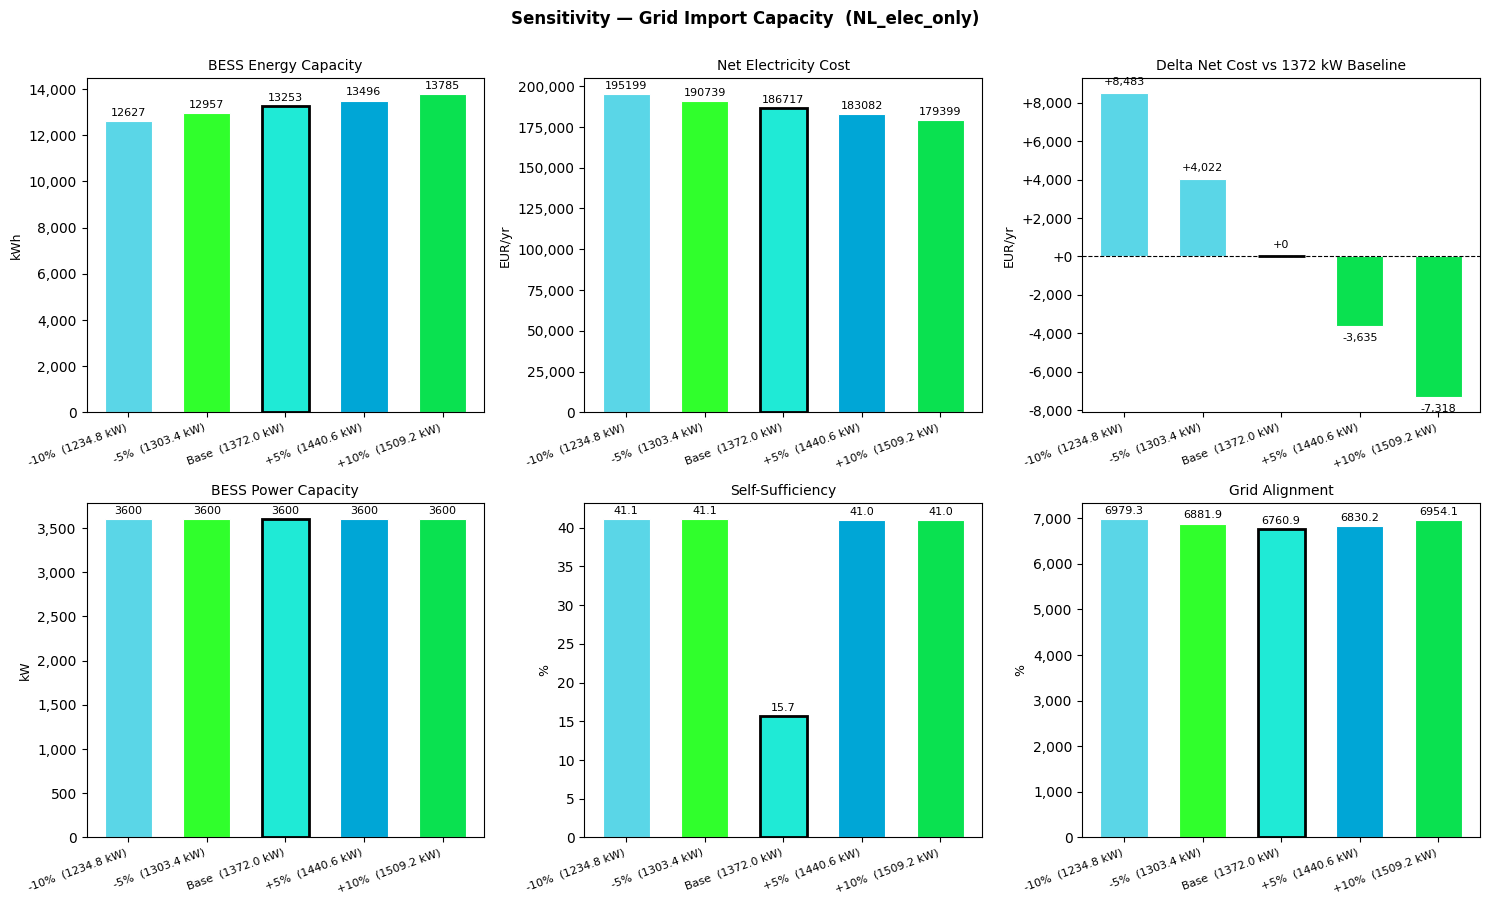

Saved: grid_cap_sensitivity_elec.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY CHARTS — Grid Import Capacity  [NL_elec_only]
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.ticker as _mt2

_gl     = _df_grid.index.tolist()
_gx     = np.arange(len(_gl))
_gcaps  = _df_grid["Grid cap (kW)"].values
_gcols  = ["#5AD6E7", "#30FF2C", "#1FEAD6", "#00A6D6", "#0AE150"]
_gbase  = list(_df_grid["Grid cap (kW)"]).index(1372.0)   # index of base row

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Sensitivity — Grid Import Capacity  (NL_elec_only)",
             fontsize=12, fontweight="bold", y=0.999)

def _gbar(ax, vals, ylabel, title, fmt="{:.0f}"):
    bars = ax.bar(_gx, vals, color=_gcols, edgecolor="white", lw=0.8, width=0.6)
    ax.set_xticks(_gx)
    ax.set_xticklabels(_gl, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9); ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_formatter(_mt2.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    bars[_gbase].set_edgecolor("black"); bars[_gbase].set_linewidth(2.0)
    _yr = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bar, val in zip(bars, vals):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + _yr * 0.01,
                    fmt.format(val), ha="center", va="bottom", fontsize=8)

# Row 1
_gbar(axes[0, 0], _df_grid["BESS energy (kWh)"].values,      "kWh",     "BESS Energy Capacity")
_gbar(axes[0, 1], _df_grid["Net elec cost (EUR/yr)"].values, "EUR/yr",  "Net Electricity Cost")

_dv = _df_grid["Delta cost (EUR/yr)"].values
_dc = ["#5AD6E7" if v > 0 else ("#0AE150" if v < 0 else "#1FEAD6") for v in _dv]
_db = axes[0, 2].bar(_gx, _dv, color=_dc, edgecolor="white", lw=0.8, width=0.6)
axes[0, 2].axhline(0, color="black", lw=0.8, ls="--")
axes[0, 2].set_xticks(_gx)
axes[0, 2].set_xticklabels(_gl, rotation=20, ha="right", fontsize=8)
axes[0, 2].set_ylabel("EUR/yr", fontsize=9)
axes[0, 2].set_title("Delta Net Cost vs 1372 kW Baseline", fontsize=10)
axes[0, 2].yaxis.set_major_formatter(_mt2.FuncFormatter(lambda v, _: f"{v:+,.0f}"))
_db[_gbase].set_edgecolor("black"); _db[_gbase].set_linewidth(2.0)
_dyr = axes[0, 2].get_ylim()[1] - axes[0, 2].get_ylim()[0]
for bar, val in zip(_db, _dv):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2,
                     val + (_dyr * 0.02 if val >= 0 else -_dyr * 0.02),
                     f"{val:+,.0f}", ha="center",
                     va="bottom" if val >= 0 else "top", fontsize=8)

# Row 2
_gbar(axes[1, 0], _df_grid["BESS power (kW)"].values, "kW", "BESS Power Capacity")

_gbar(axes[1, 1], _df_grid["Self-suff (%)"].values,   "%",  "Self-Sufficiency", fmt="{:.1f}")
_gbar(axes[1, 2], _df_grid["Grid align (%)"].values,  "%",  "Grid Alignment",   fmt="{:.1f}")

plt.tight_layout(rect=[0, 0, 1, 0.998])
_gfname = "grid_cap_sensitivity_elec.png"
plt.savefig(_gfname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_gfname}")

In [ ]:
# ─── PV CAPEX Sensitivity Analysis ─────────────────────────────────────
_pv_prices_wp = [1.80, 1.60, 1.40, 1.20, 1.00]  # €/Wp
_pv_tm_net  = pv_marginal_given_bat - pv_om_yr  # PV true marginal net O&M (bat-only→S3)
_bat_tm_net = (s2_net_cost - s3_net_cost) - bat_om_yr  # Bat true marginal net O&M (PV-only→S3)
_vfmt = lambda x: f'{x:,.0f}' if x == x else 'n/a'  # NaN-safe formatter
_pfmt = lambda x: f'{x:.1f} yr' if 0 < x < 999 else ('n/a' if x != x else 'n/a')
W4 = 86
print('\n' + '='*W4)
print(f'  PV CAPEX SENSITIVITY  ({_PV_KWP_STC:,.0f} kWp STC nameplate)')
print('='*W4)
print(f"  {'Metric':<42}" + ''.join(f"  {'\u20ac'+str(p)+'/Wp':>8}" for p in _pv_prices_wp))
print('  ' + '-'*80)
_sv = []
for _p in _pv_prices_wp:
    _pce  = _PV_KWP_STC * _p * 1000
    _sce  = _pce + bat_net_capex
    _sv.append((_pce, _sce,
                _pce / _pv_tm_net   if _pv_tm_net  > 0 else float('inf'),   # PV tm payback
                bat_net_capex / _bat_tm_net if _bat_tm_net > 0 else float('inf'),  # Bat tm payback
                _pce / pv_syn_net_yr  if pv_syn_net_yr  > 0 else float('inf'),  # PV Shapley
                bat_net_capex / bat_syn_net_yr if bat_syn_net_yr > 0 else float('inf'),  # Bat Shapley
                _sce / sys_syn_net_yr if sys_syn_net_yr > 0 else float('inf')))  # Sys Shapley
print(f"  {'PV CAPEX (\u20ac)':<42}" + ''.join(f'  {s[0]:>8,.0f}' for s in _sv))
print(f"  {'System CAPEX  PV + battery net (\u20ac)':<42}" + ''.join(f'  {s[1]:>8,.0f}' for s in _sv))
print('  ' + '-'*80)
print(f"  {'PV true marginal net O&M (\u20ac/yr)  [fixed]':<42}" + ''.join(f'  {_vfmt(_pv_tm_net):>8}' for _ in _sv))
print(f"  {'Bat true marginal net O&M (\u20ac/yr)  [fixed]':<42}" + ''.join(f'  {_vfmt(_bat_tm_net):>8}' for _ in _sv))
print('  ' + '-'*80)
print(f"  {'PV true marginal payback':<42}" + ''.join(f'  {_pfmt(s[2]):>8}' for s in _sv))
print(f"  {'Battery true marginal payback  [fixed]':<42}" + ''.join(f'  {_pfmt(s[3]):>8}' for s in _sv))
print('  ' + '-'*80)
print(f"  {'PV Shapley payback':<42}" + ''.join(f'  {_pfmt(s[4]):>8}' for s in _sv))
print(f"  {'Battery Shapley payback  [fixed]':<42}" + ''.join(f'  {_pfmt(s[5]):>8}' for s in _sv))
print(f"  {'System Shapley payback':<42}" + ''.join(f'  {_pfmt(s[6]):>8}' for s in _sv))
print('='*W4)
print(f'  True marginal = full-system re-solve removing one component (upper bound — all synergy to last entrant)')
print(f'  Shapley = standalone + half synergy  |  PV syn net: \u20ac{pv_syn_net_yr:,.0f}/yr  Bat syn net: \u20ac{bat_syn_net_yr:,.0f}/yr')
